**Introducción al uso de Machine Learning para la clasificación CN vs AD**

La diferenciación entre `Cognitive Normal` (`CN`) y `Alzheimer's Disease` (`AD`) representa uno de los retos más relevantes en el análisis de neuroimagen y biomarcadores estructurales. Detectar de forma temprana la progresión desde `MCI` hacia `AD` puede facilitar intervenciones clínicas más precoces y mejorar la estratificación de pacientes. En este estudio se emplean técnicas de `machine learning` supervisado para abordar el problema de clasificación binaria `CN vs AD` a partir de características derivadas de resonancia magnética estructural procesadas con `FreeSurfer` y otras representaciones volumétricas. El objetivo principal es evaluar la capacidad discriminativa de distintos conjuntos de características y metodologías de selección de variables.

**Formulación del problema**

Se plantea un problema de clasificación binaria supervisada donde:

* Clase positiva: pacientes con Alzheimer (`AD`)
* Clase negativa: pacientes con `CN`

El modelo aprende una función: $f(\mathbf{x}) \rightarrow y$ donde:
* $\mathbf{x}$ = vector de características
* $y \in \{\text{CN}, \text{AD}\}$

**Pipeline de Machine Learning**

Para cada dataset se aplicó un `pipeline` estructurado compuesto por:

1. **Estandarización**
Las características se escalaron para garantizar que todas las variables contribuyeran de forma comparable al modelo.

2. **Selección / reducción de características**
Se evaluaron tres enfoques complementarios:

* `PCA` (Principal Component Analysis)
   * Reduce dimensionalidad mediante combinaciones lineales ortogonales.
   * Útil para eliminar colinealidad.
* `Elastic Net`
   * Método embebido con regularización `L1` + `L2`.
   * Realiza selección automática de variables.
* `RFE` (Recursive Feature Elimination)
   * Eliminación iterativa basada en la importancia del modelo.
   * Permite identificar subconjuntos discriminativos.

3. **Clasificación supervisada**
Sobre las características transformadas se entrenaron dos clasificadores principales:

* `Logistic Regression` (`LR`)
   * Modelo lineal interpretable y rápido
   * Buen baseline para problemas de clasificación binaria (como `CN vs AD`)
* `Support Vector Machine` (`SVM`)
   * Eficaz en espacios de alta dimensión
   * Robusto ante fronteras no lineales
* `Random Forest` (`RF`)
   * Modelo basado en ensamblado de árboles
   * Capta relaciones no lineales

4. **Evaluación**
El rendimiento de los modelos se evaluó mediante métricas estándar de clasificación, incluyendo:

* Accuracy
* F1-score
* Matriz de confusión
* Validación cruzada estratificada

#
# Configuración del PATH

In [1]:
import os
import pandas as pd

RUTA_BASE = r"D:\progreso actual\Codigos\machine learning"

pd_read_csv_original = pd.read_csv

def read_csv_inteligente(nombre_archivo, **kwargs):

    if os.path.exists(nombre_archivo):
        return pd_read_csv_original(nombre_archivo, **kwargs)
    
    for root, dirs, files in os.walk(RUTA_BASE):
        if nombre_archivo in files:
            ruta_encontrada = os.path.join(root, nombre_archivo)
            return pd_read_csv_original(ruta_encontrada, **kwargs)

    raise FileNotFoundError(f"No se encuentra '{nombre_archivo}' en ninguna subcarpeta de {RUTA_BASE}")

pd.read_csv = read_csv_inteligente

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Diccionario global para guardar resultados, indexado por clave única
if os.path.exists("resultados_modelos_CN_vs_AD.csv"):
    RESULTADOS_MODELOS = pd.read_csv("resultados_modelos_CN_vs_AD.csv").to_dict(orient="records")
else:
    RESULTADOS_MODELOS = []

# Funciones de detección automática
def detectar_selector(pipeline):
    for _, step in pipeline.named_steps.items():
        if isinstance(step, RFE):
            return "RFE"
        if isinstance(step, PCA):
            return "PCA"
        if isinstance(step, SelectFromModel):
            est = step.estimator
            if hasattr(est, "penalty") and est.penalty == "elasticnet":
                return "ElasticNet"
            return "SelectFromModel"
    return "None"

def detectar_clasificador(pipeline):
    for _, step in pipeline.named_steps.items():
        if isinstance(step, LogisticRegression):
            return "LogisticRegression"
        if isinstance(step, SVC):
            return "SVM"
        if isinstance(step, RandomForestClassifier):
            return "RandomForest"
    return "Desconocido"

def extraer_dataset_clave(df_or_filename):
    """Devuelve la parte del nombre del dataset hasta ad/cn"""
    name = str(df_or_filename)
    for clave in ["ad", "cn"]:
        idx = name.lower().find(clave)
        if idx != -1:
            return name[:idx]
    return name

def registrar_modelo(grid, dataset, y_test, y_pred, y_prob, feature_names):
    modelo = grid.best_estimator_
    selector = detectar_selector(modelo)
    clasificador = detectar_clasificador(modelo)
    dataset_name = extraer_dataset_clave(dataset)
    clave_modelo = f"{dataset_name}_{selector}_{clasificador}"

    # Métricas test
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    # Métricas validación cruzada
    best_idx = grid.best_index_
    f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
    roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
    balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
    precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
    recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
    specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

    num_selected = len(feature_names)

    fila = {
        "dataset": dataset_name,
        "selector": selector,
        "clasificador": clasificador,
        # Test
        "f1_test": f1,
        "roc_auc_test": roc_auc,
        "balanced_acc_test": balanced_acc,
        "precision_test": precision,
        "recall_test": recall,
        "specificity_test": specificity,
        # Validación
        "f1_val": f1_cv,
        "roc_auc_val": roc_auc_cv,
        "balanced_acc_val": balanced_acc_cv,
        "precision_val": precision_cv,
        "recall_val": recall_cv,
        "specificity_val": specificity_cv,
        "num_selected_features": num_selected,
        "clave_modelo": clave_modelo
    }

    indices_existentes = [i for i, r in enumerate(RESULTADOS_MODELOS) if r.get("clave_modelo") == clave_modelo]
    if indices_existentes:
        RESULTADOS_MODELOS[indices_existentes[0]] = fila
    else:
        RESULTADOS_MODELOS.append(fila)

    df_temp = pd.DataFrame(RESULTADOS_MODELOS)
    df_temp.drop(columns=["clave_modelo"], inplace=True, errors="ignore")
    df_temp.to_csv("resultados_modelos_CN_vs_AD.csv", index=False)

# Convertir a DataFrame
df_resultados = pd.DataFrame(RESULTADOS_MODELOS).drop(columns=["clave_modelo"], errors="ignore")

# Guardar CSV final
df_resultados.to_csv("resultados_modelos_CN_vs_AD.csv", index=False)

# Estilizado
df_resultados_styled = df_resultados.style \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

display(df_resultados_styled)

,dataset,selector,clasificador,f1_test,roc_auc_test,balanced_acc_test,precision_test,recall_test,specificity_test,f1_val,roc_auc_val,balanced_acc_val,precision_val,recall_val,specificity_val,num_selected_features
0,csf_gm_wm_harvard_oxford,ElasticNet,LogisticRegression,0.863636,0.952381,0.878307,0.826087,0.904762,0.851852,0.808020,0.868254,0.825444,0.819282,0.803268,0.847619,18
1,csf_gm_wm_harvard_oxford,ElasticNet,SVM,0.863636,0.947090,0.878307,0.826087,0.904762,0.851852,0.779478,0.870495,0.802241,0.804118,0.756863,0.847619,18
2,csf_gm_wm_harvard_oxford,ElasticNet,RandomForest,0.837209,0.906526,0.854497,0.818182,0.857143,0.851852,0.827051,0.876128,0.842110,0.823956,0.836601,0.847619,20
3,csf_gm_wm_harvard_oxford,RFE,LogisticRegression,0.863636,0.922399,0.878307,0.826087,0.904762,0.851852,0.796317,0.868285,0.815593,0.795301,0.802614,0.828571,18
4,csf_gm_wm_harvard_oxford,RFE,SVM,0.790698,0.883598,0.812169,0.772727,0.809524,0.814815,0.788030,0.872767,0.814613,0.854258,0.733987,0.895238,12
5,csf_gm_wm_harvard_oxford,RFE,RandomForest,0.818182,0.908289,0.835979,0.782609,0.857143,0.814815,0.807833,0.876595,0.825584,0.804967,0.813072,0.838095,17
6,csf_gm_wm_harvard_oxford,PCA,LogisticRegression,0.883721,0.932981,0.896825,0.863636,0.904762,0.888889,0.843540,0.902739,0.853548,0.839625,0.859477,0.847619,23
7,csf_gm_wm_harvard_oxford,PCA,SVM,0.863636,0.943563,0.878307,0.826087,0.904762,0.851852,0.844309,0.904575,0.853875,0.839799,0.860131,0.847619,21
8,csf_gm_wm_harvard_oxford,PCA,RandomForest,0.791667,0.922399,0.804233,0.703704,0.904762,0.703704,0.814729,0.875163,0.833520,0.842332,0.790850,0.876190,12
9,grosores_corticales,ElasticNet,LogisticRegression,0.800000,0.890653,0.825397,0.842105,0.761905,0.888889,0.866240,0.910520,0.880205,0.902801,0.836601,0.923810,3


#
# ELASTIC NET - csf_gm_wm_harvard_oxford_atlas
---

# LOGISTIC REGRESSION

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parámetros encontrados:
{'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 18}

===== RESUMEN DE MÉTRICAS =====


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,Value
0,F1-score (test),0.863636
1,F1-score (validación),0.808020
2,ROC-AUC (test),0.952381
3,ROC-AUC (validación),0.868254
4,Balanced Accuracy (test),0.878307
5,Balanced Accuracy (validación),0.825444
6,Precision (test),0.826087
7,Precision (validación),0.819282
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.803268


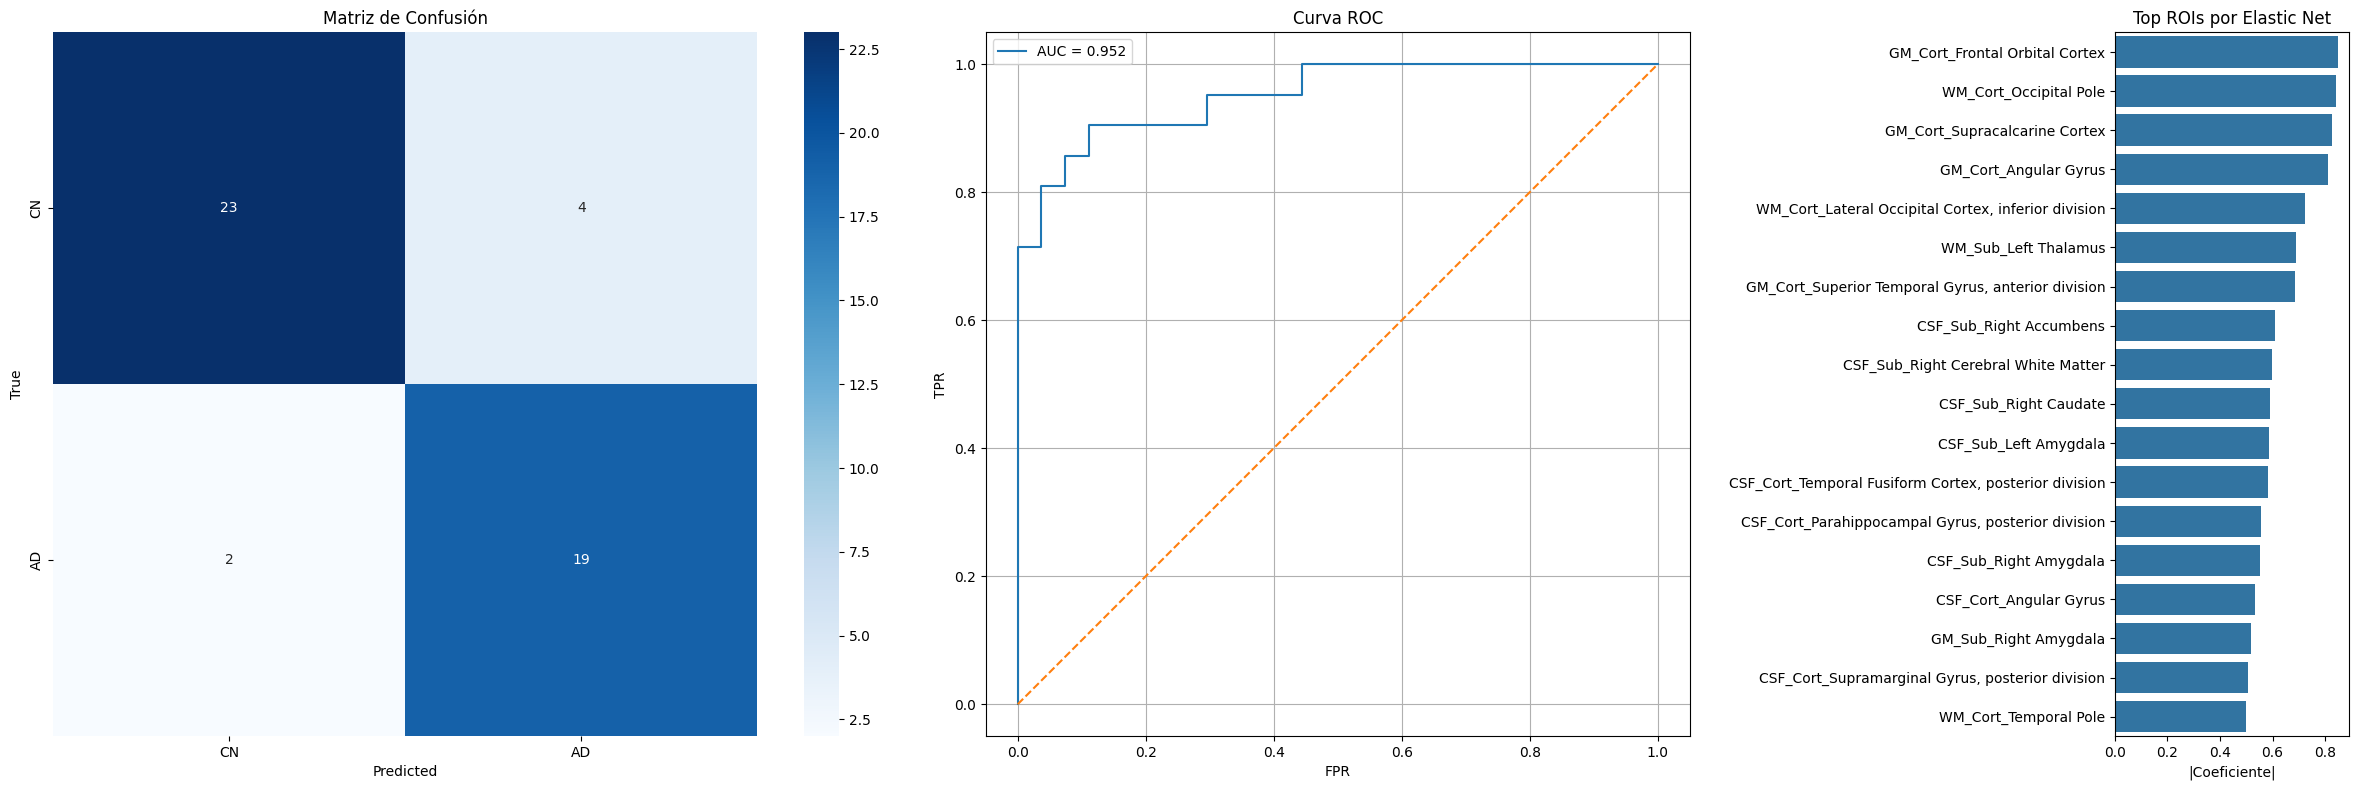


Las 18 ROIs seleccionadas son:
['GM_Cort_Superior Temporal Gyrus, anterior division', 'GM_Cort_Angular Gyrus', 'GM_Cort_Frontal Orbital Cortex', 'GM_Cort_Supracalcarine Cortex', 'GM_Sub_Right Amygdala', 'WM_Cort_Temporal Pole', 'WM_Cort_Lateral Occipital Cortex, inferior division', 'WM_Cort_Occipital Pole', 'WM_Sub_Left Thalamus', 'CSF_Cort_Supramarginal Gyrus, posterior division', 'CSF_Cort_Angular Gyrus', 'CSF_Cort_Parahippocampal Gyrus, posterior division', 'CSF_Cort_Temporal Fusiform Cortex, posterior division', 'CSF_Sub_Left Amygdala', 'CSF_Sub_Right Cerebral White Matter', 'CSF_Sub_Right Caudate', 'CSF_Sub_Right Amygdala', 'CSF_Sub_Right Accumbens']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,GM_Cort_Frontal Orbital Cortex,0.848550
1,WM_Cort_Occipital Pole,0.840512
2,GM_Cort_Supracalcarine Cortex,0.827893
3,GM_Cort_Angular Gyrus,-0.810983
4,"WM_Cort_Lateral Occipital Cortex, inferior div...",0.724298
5,WM_Sub_Left Thalamus,-0.689977
6,"GM_Cort_Superior Temporal Gyrus, anterior divi...",-0.684316
7,CSF_Sub_Right Accumbens,0.610398
8,CSF_Sub_Right Cerebral White Matter,-0.599111
9,CSF_Sub_Right Caudate,0.591931


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Logistic Rgression final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('logreg', LogisticRegression(max_iter=10000, random_state=34, class_weight='balanced'))
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__l1_ratio': [0],
    'logreg__solver': ['saga']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.3]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.08,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 18, 'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.863636
1,F1-score (validación),0.779478
2,ROC-AUC (test),0.947090
3,ROC-AUC (validación),0.870495
4,Balanced Accuracy (test),0.878307
5,Balanced Accuracy (validación),0.802241
6,Precision (test),0.826087
7,Precision (validación),0.804118
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.756863


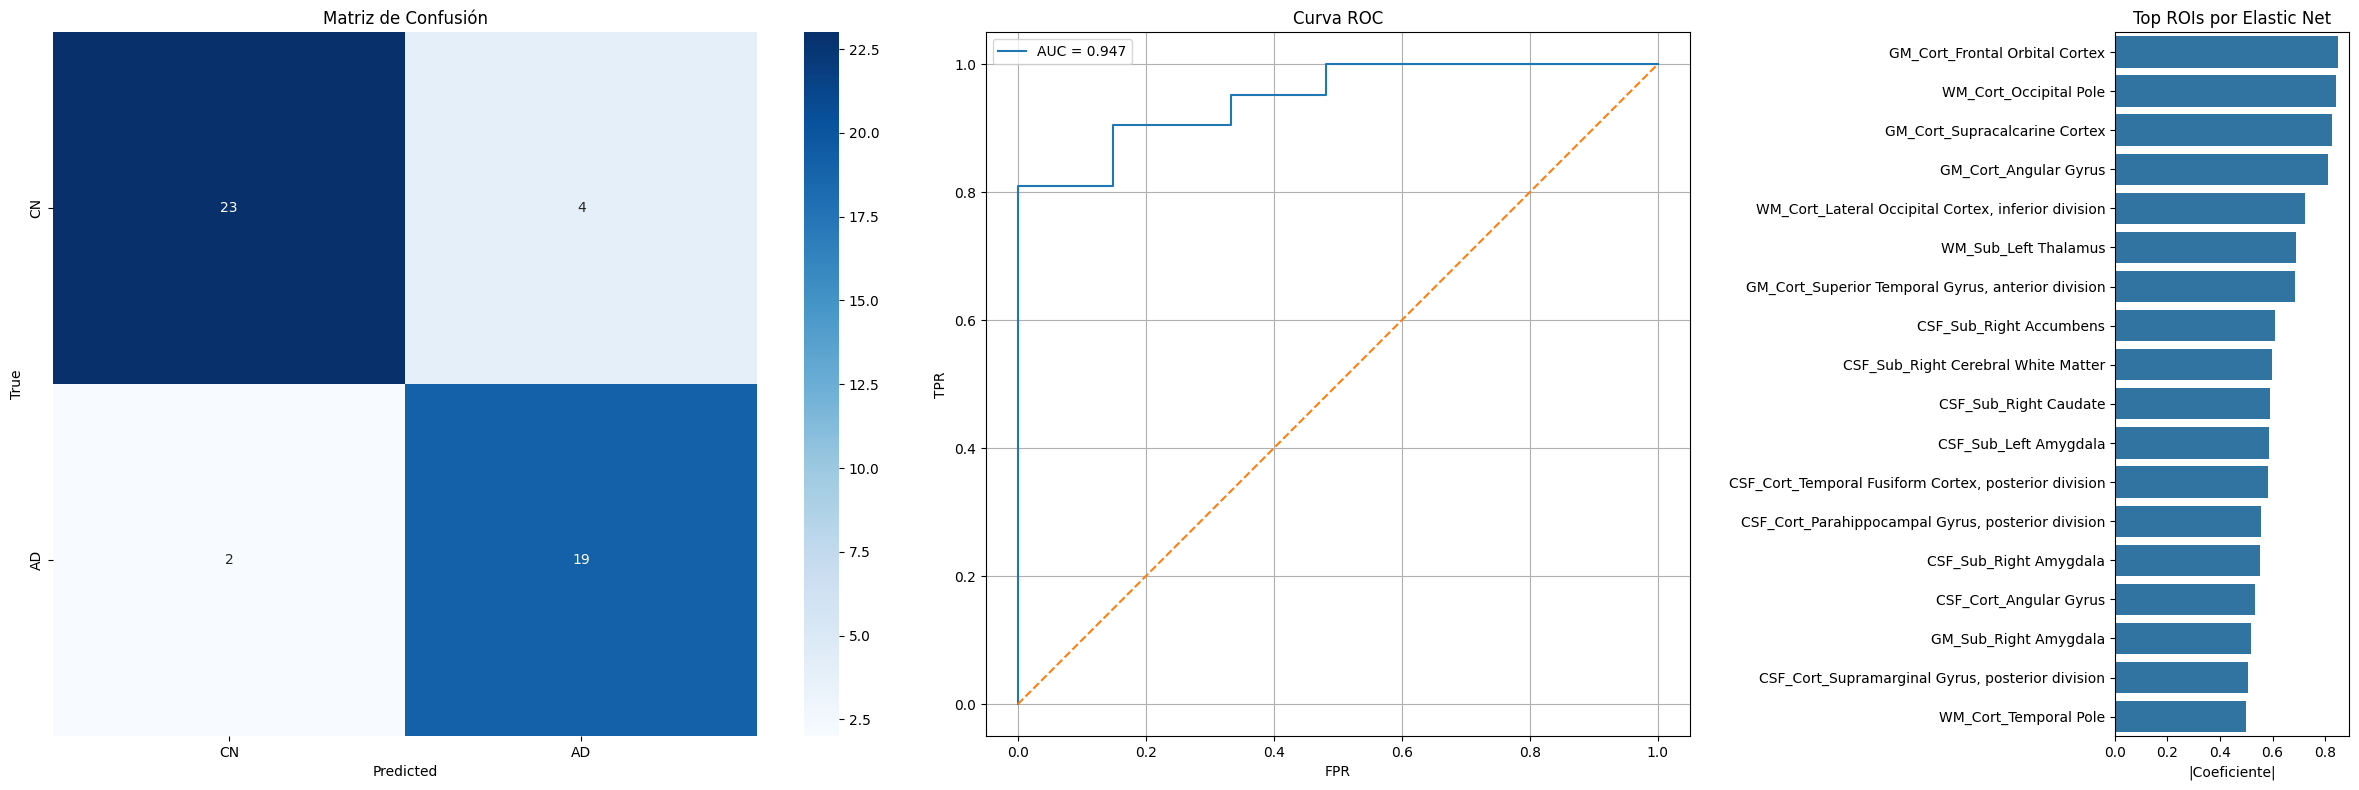


Las 18 ROIs seleccionadas son:
['GM_Cort_Superior Temporal Gyrus, anterior division', 'GM_Cort_Angular Gyrus', 'GM_Cort_Frontal Orbital Cortex', 'GM_Cort_Supracalcarine Cortex', 'GM_Sub_Right Amygdala', 'WM_Cort_Temporal Pole', 'WM_Cort_Lateral Occipital Cortex, inferior division', 'WM_Cort_Occipital Pole', 'WM_Sub_Left Thalamus', 'CSF_Cort_Supramarginal Gyrus, posterior division', 'CSF_Cort_Angular Gyrus', 'CSF_Cort_Parahippocampal Gyrus, posterior division', 'CSF_Cort_Temporal Fusiform Cortex, posterior division', 'CSF_Sub_Left Amygdala', 'CSF_Sub_Right Cerebral White Matter', 'CSF_Sub_Right Caudate', 'CSF_Sub_Right Amygdala', 'CSF_Sub_Right Accumbens']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,GM_Cort_Frontal Orbital Cortex,0.848550
1,WM_Cort_Occipital Pole,0.840512
2,GM_Cort_Supracalcarine Cortex,0.827893
3,GM_Cort_Angular Gyrus,-0.810983
4,"WM_Cort_Lateral Occipital Cortex, inferior div...",0.724298
5,WM_Sub_Left Thalamus,-0.689977
6,"GM_Cort_Superior Temporal Gyrus, anterior divi...",-0.684316
7,CSF_Sub_Right Accumbens,0.610398
8,CSF_Sub_Right Cerebral White Matter,-0.599111
9,CSF_Sub_Right Caudate,0.591931


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight= 'balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> SVC final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('svm',  SVC(probability=True, random_state=34, class_weight= 'balanced')) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.3]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.08,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100, 'selector__estimator__l1_ratio': 0.5, 'selector__max_features': 20}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.837209
1,F1-score (validación),0.827051
2,ROC-AUC (test),0.906526
3,ROC-AUC (validación),0.876128
4,Balanced Accuracy (test),0.854497
5,Balanced Accuracy (validación),0.842110
6,Precision (test),0.818182
7,Precision (validación),0.823956
8,Recall (Sensitivity) (test),0.857143
9,Recall (Sensitivity) (validación),0.836601


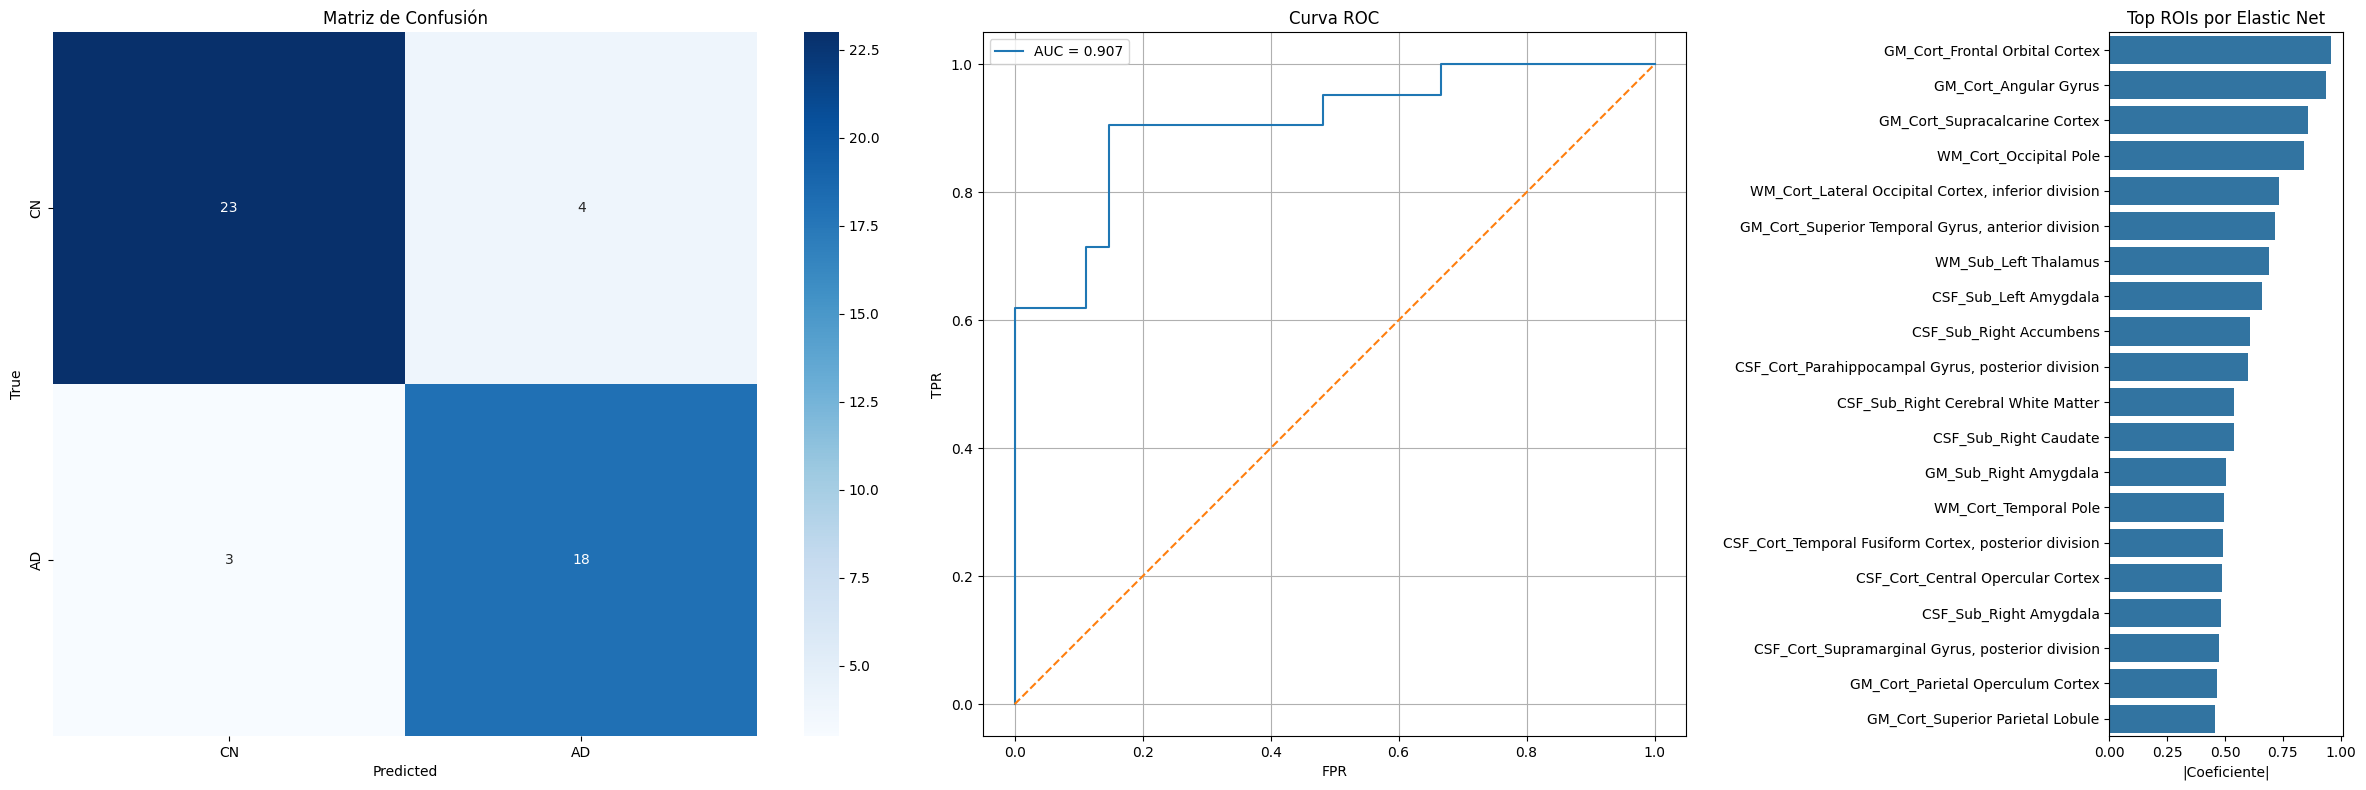


Las 20 ROIs seleccionadas son:
['GM_Cort_Superior Temporal Gyrus, anterior division', 'GM_Cort_Superior Parietal Lobule', 'GM_Cort_Angular Gyrus', 'GM_Cort_Frontal Orbital Cortex', 'GM_Cort_Parietal Operculum Cortex', 'GM_Cort_Supracalcarine Cortex', 'GM_Sub_Right Amygdala', 'WM_Cort_Temporal Pole', 'WM_Cort_Lateral Occipital Cortex, inferior division', 'WM_Cort_Occipital Pole', 'WM_Sub_Left Thalamus', 'CSF_Cort_Supramarginal Gyrus, posterior division', 'CSF_Cort_Parahippocampal Gyrus, posterior division', 'CSF_Cort_Temporal Fusiform Cortex, posterior division', 'CSF_Cort_Central Opercular Cortex', 'CSF_Sub_Left Amygdala', 'CSF_Sub_Right Cerebral White Matter', 'CSF_Sub_Right Caudate', 'CSF_Sub_Right Amygdala', 'CSF_Sub_Right Accumbens']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,GM_Cort_Frontal Orbital Cortex,0.959897
1,GM_Cort_Angular Gyrus,-0.937772
2,GM_Cort_Supracalcarine Cortex,0.860078
3,WM_Cort_Occipital Pole,0.842844
4,"WM_Cort_Lateral Occipital Cortex, inferior div...",0.731841
5,"GM_Cort_Superior Temporal Gyrus, anterior divi...",-0.714509
6,WM_Sub_Left Thalamus,-0.691145
7,CSF_Sub_Left Amygdala,0.659990
8,CSF_Sub_Right Accumbens,0.606865
9,"CSF_Cort_Parahippocampal Gyrus, posterior divi...",0.598771


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")


# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.3]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.08,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# RFE
---

# LOGISTIC REGRESSION

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores parámetros encontrados:
{'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 18}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.863636
1,F1-score (validación),0.796317
2,ROC-AUC (test),0.922399
3,ROC-AUC (validación),0.868285
4,Balanced Accuracy (test),0.878307
5,Balanced Accuracy (validación),0.815593
6,Precision (test),0.826087
7,Precision (validación),0.795301
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.802614


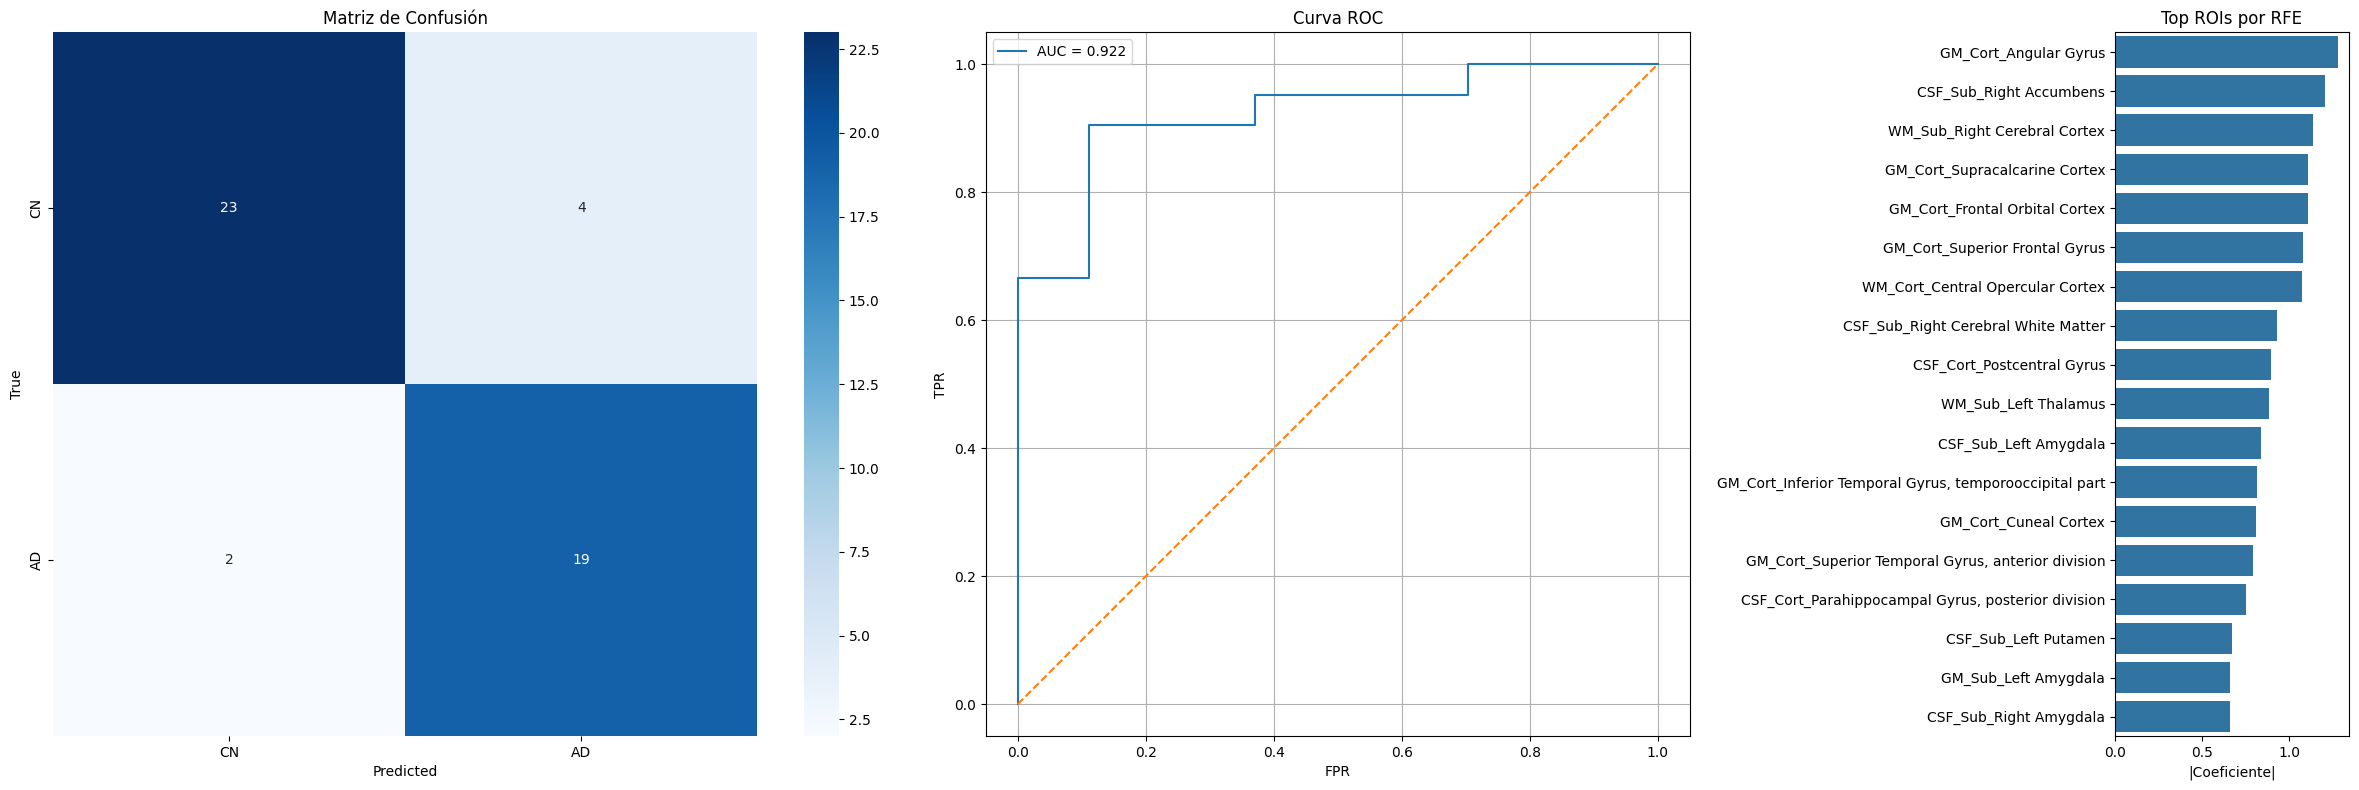


Las 18 ROIs seleccionadas por RFE son:
['GM_Cort_Superior Frontal Gyrus', 'GM_Cort_Superior Temporal Gyrus, anterior division', 'GM_Cort_Inferior Temporal Gyrus, temporooccipital part', 'GM_Cort_Angular Gyrus', 'GM_Cort_Cuneal Cortex', 'GM_Cort_Frontal Orbital Cortex', 'GM_Cort_Supracalcarine Cortex', 'GM_Sub_Left Amygdala', 'WM_Cort_Central Opercular Cortex', 'WM_Sub_Left Thalamus', 'WM_Sub_Right Cerebral Cortex', 'CSF_Cort_Postcentral Gyrus', 'CSF_Cort_Parahippocampal Gyrus, posterior division', 'CSF_Sub_Left Putamen', 'CSF_Sub_Left Amygdala', 'CSF_Sub_Right Cerebral White Matter', 'CSF_Sub_Right Amygdala', 'CSF_Sub_Right Accumbens']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,GM_Cort_Angular Gyrus,-1.277088
1,CSF_Sub_Right Accumbens,1.200917
2,WM_Sub_Right Cerebral Cortex,1.134426
3,GM_Cort_Supracalcarine Cortex,1.107963
4,GM_Cort_Frontal Orbital Cortex,1.106711
5,GM_Cort_Superior Frontal Gyrus,1.078404
6,WM_Cort_Central Opercular Cortex,-1.070376
7,CSF_Sub_Right Cerebral White Matter,-0.929514
8,CSF_Cort_Postcentral Gyrus,0.892314
9,WM_Sub_Left Thalamus,-0.884211


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística y balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('logreg', LogisticRegression(max_iter = 10000, random_state=34, class_weight='balanced'))  # Logistic Regression con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0],          # L2
        'logreg__C': [0.01,0.1,1,10]    # Regularización
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.3]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.08,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Mejores parámetros encontrados:
{'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 12, 'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.790698
1,F1-score (validación),0.788030
2,ROC-AUC (test),0.883598
3,ROC-AUC (validación),0.872767
4,Balanced Accuracy (test),0.812169
5,Balanced Accuracy (validación),0.814613
6,Precision (test),0.772727
7,Precision (validación),0.854258
8,Recall (Sensitivity) (test),0.809524
9,Recall (Sensitivity) (validación),0.733987


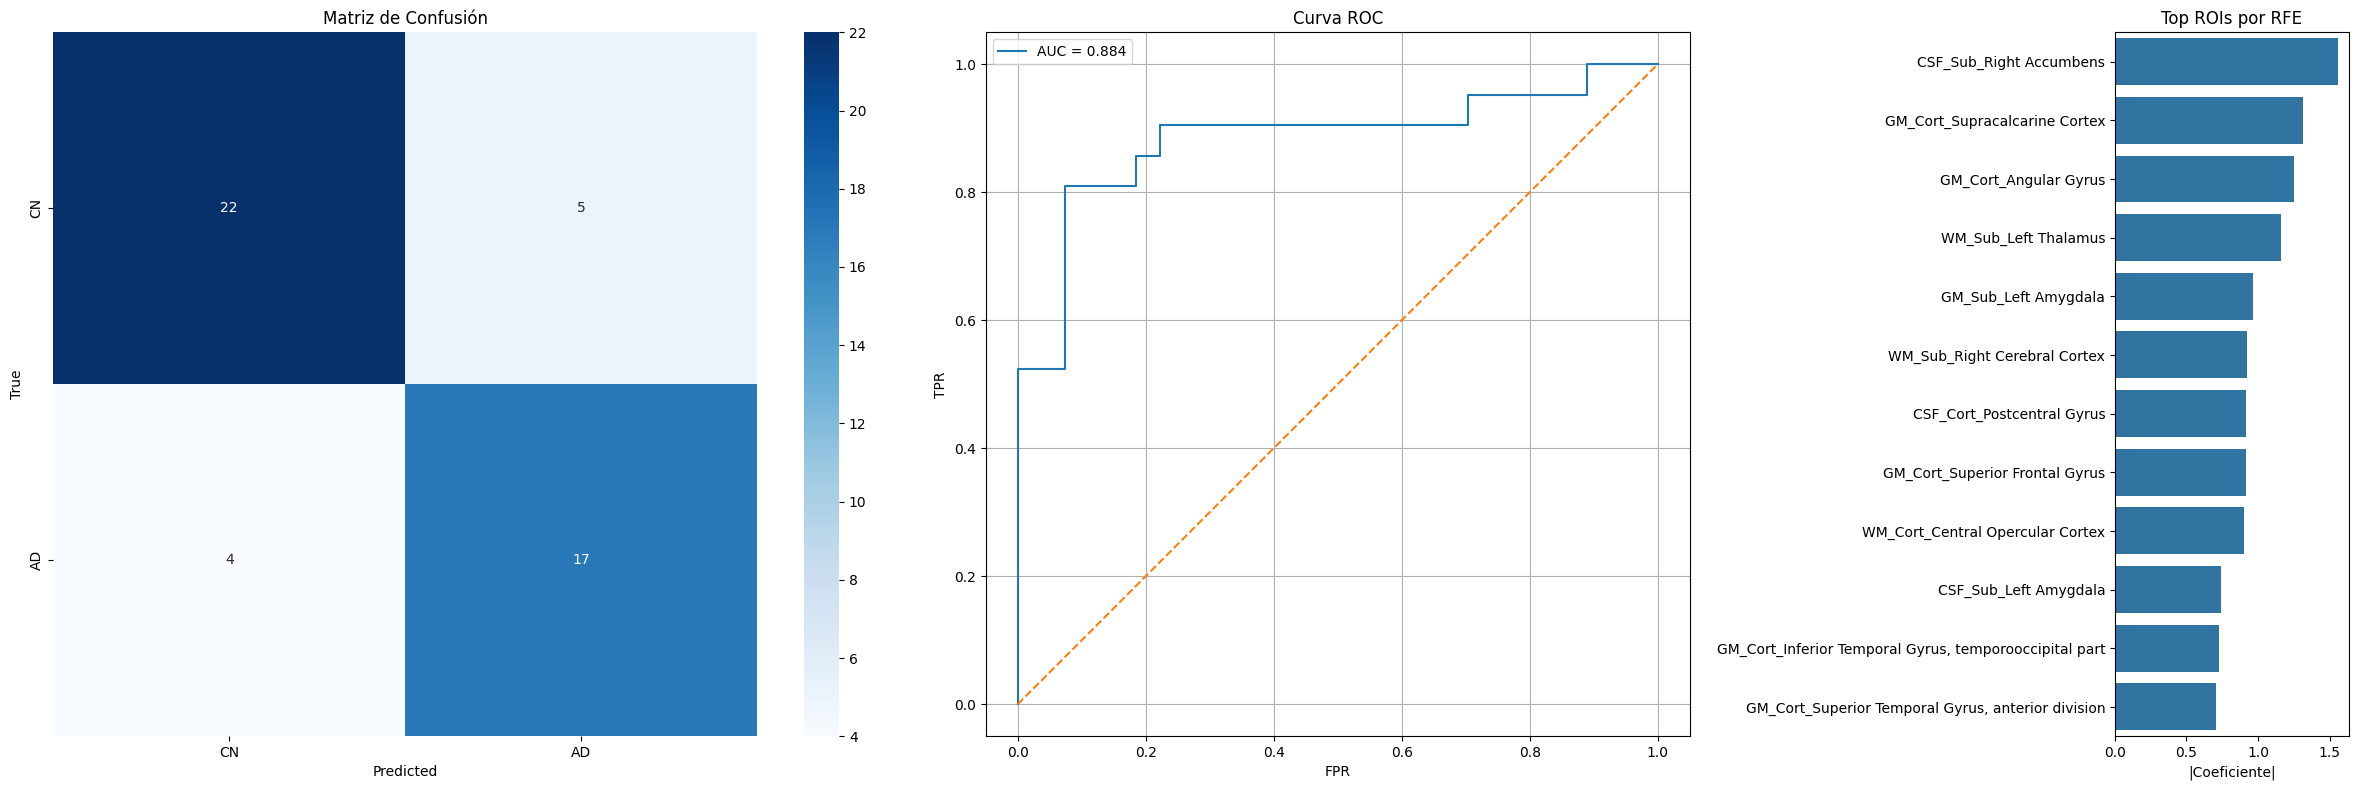


Las 12 ROIs seleccionadas por RFE son:
['GM_Cort_Superior Frontal Gyrus', 'GM_Cort_Superior Temporal Gyrus, anterior division', 'GM_Cort_Inferior Temporal Gyrus, temporooccipital part', 'GM_Cort_Angular Gyrus', 'GM_Cort_Supracalcarine Cortex', 'GM_Sub_Left Amygdala', 'WM_Cort_Central Opercular Cortex', 'WM_Sub_Left Thalamus', 'WM_Sub_Right Cerebral Cortex', 'CSF_Cort_Postcentral Gyrus', 'CSF_Sub_Left Amygdala', 'CSF_Sub_Right Accumbens']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,CSF_Sub_Right Accumbens,1.557156
1,GM_Cort_Supracalcarine Cortex,1.315039
2,GM_Cort_Angular Gyrus,-1.247835
3,WM_Sub_Left Thalamus,-1.157614
4,GM_Sub_Left Amygdala,-0.966862
5,WM_Sub_Right Cerebral Cortex,0.922315
6,CSF_Cort_Postcentral Gyrus,0.918565
7,GM_Cort_Superior Frontal Gyrus,0.916037
8,WM_Cort_Central Opercular Cortex,-0.903109
9,CSF_Sub_Left Amygdala,0.743374


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('svm',SVC(probability=True, random_state=34, class_weight='balanced'))  # SVM con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + SVM
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'svm__C': [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svm__kernel': ['linear', 'rbf']
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.3]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.08,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Mejores parámetros encontrados:
{'rf__max_depth': 2, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 5, 'rf__n_estimators': 50, 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 17}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.818182
1,F1-score (validación),0.807833
2,ROC-AUC (test),0.908289
3,ROC-AUC (validación),0.876595
4,Balanced Accuracy (test),0.835979
5,Balanced Accuracy (validación),0.825584
6,Precision (test),0.782609
7,Precision (validación),0.804967
8,Recall (Sensitivity) (test),0.857143
9,Recall (Sensitivity) (validación),0.813072


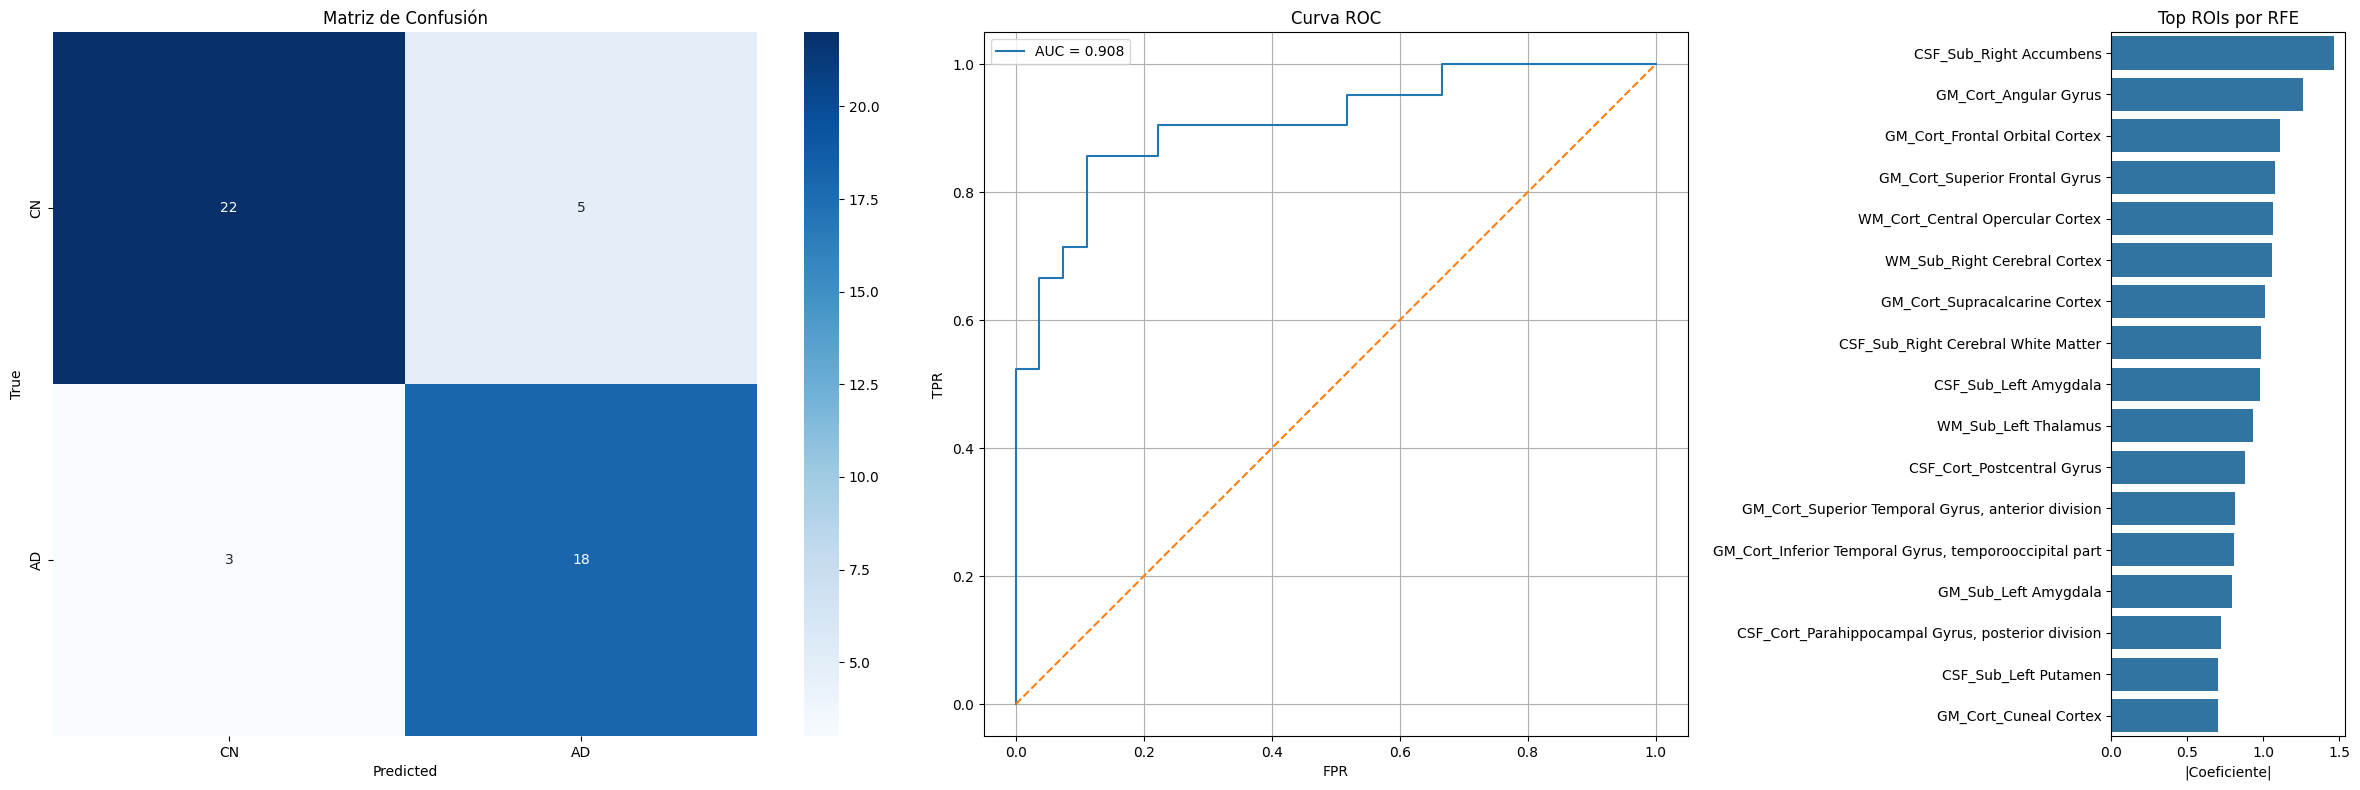


Las 17 ROIs seleccionadas por RFE son:
['GM_Cort_Superior Frontal Gyrus', 'GM_Cort_Superior Temporal Gyrus, anterior division', 'GM_Cort_Inferior Temporal Gyrus, temporooccipital part', 'GM_Cort_Angular Gyrus', 'GM_Cort_Cuneal Cortex', 'GM_Cort_Frontal Orbital Cortex', 'GM_Cort_Supracalcarine Cortex', 'GM_Sub_Left Amygdala', 'WM_Cort_Central Opercular Cortex', 'WM_Sub_Left Thalamus', 'WM_Sub_Right Cerebral Cortex', 'CSF_Cort_Postcentral Gyrus', 'CSF_Cort_Parahippocampal Gyrus, posterior division', 'CSF_Sub_Left Putamen', 'CSF_Sub_Left Amygdala', 'CSF_Sub_Right Cerebral White Matter', 'CSF_Sub_Right Accumbens']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,CSF_Sub_Right Accumbens,1.464476
1,GM_Cort_Angular Gyrus,-1.263549
2,GM_Cort_Frontal Orbital Cortex,1.110002
3,GM_Cort_Superior Frontal Gyrus,1.079076
4,WM_Cort_Central Opercular Cortex,-1.067430
5,WM_Sub_Right Cerebral Cortex,1.055846
6,GM_Cort_Supracalcarine Cortex,1.013446
7,CSF_Sub_Right Cerebral White Matter,-0.984288
8,CSF_Sub_Left Amygdala,0.981035
9,WM_Sub_Left Thalamus,-0.930977


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced'))  # Random Forest con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + Random Forest
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [2, 3, 5],
        'rf__min_samples_split': [5, 10],
        'rf__min_samples_leaf': [2, 4]
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.3]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.08,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# PCA

# LOGISTIC REGRESSION

Fitting 5 folds for each of 608 candidates, totalling 3040 fits
Mejores parámetros encontrados:
{'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'pca__n_components': 23}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.883721
1,F1-score (validación),0.843540
2,ROC-AUC (test),0.932981
3,ROC-AUC (validación),0.902739
4,Balanced Accuracy (test),0.896825
5,Balanced Accuracy (validación),0.853548
6,Precision (test),0.863636
7,Precision (validación),0.839625
8,Recall (Sensitivity) (test),0.904762
9,Recall (Sensitivity) (validación),0.859477


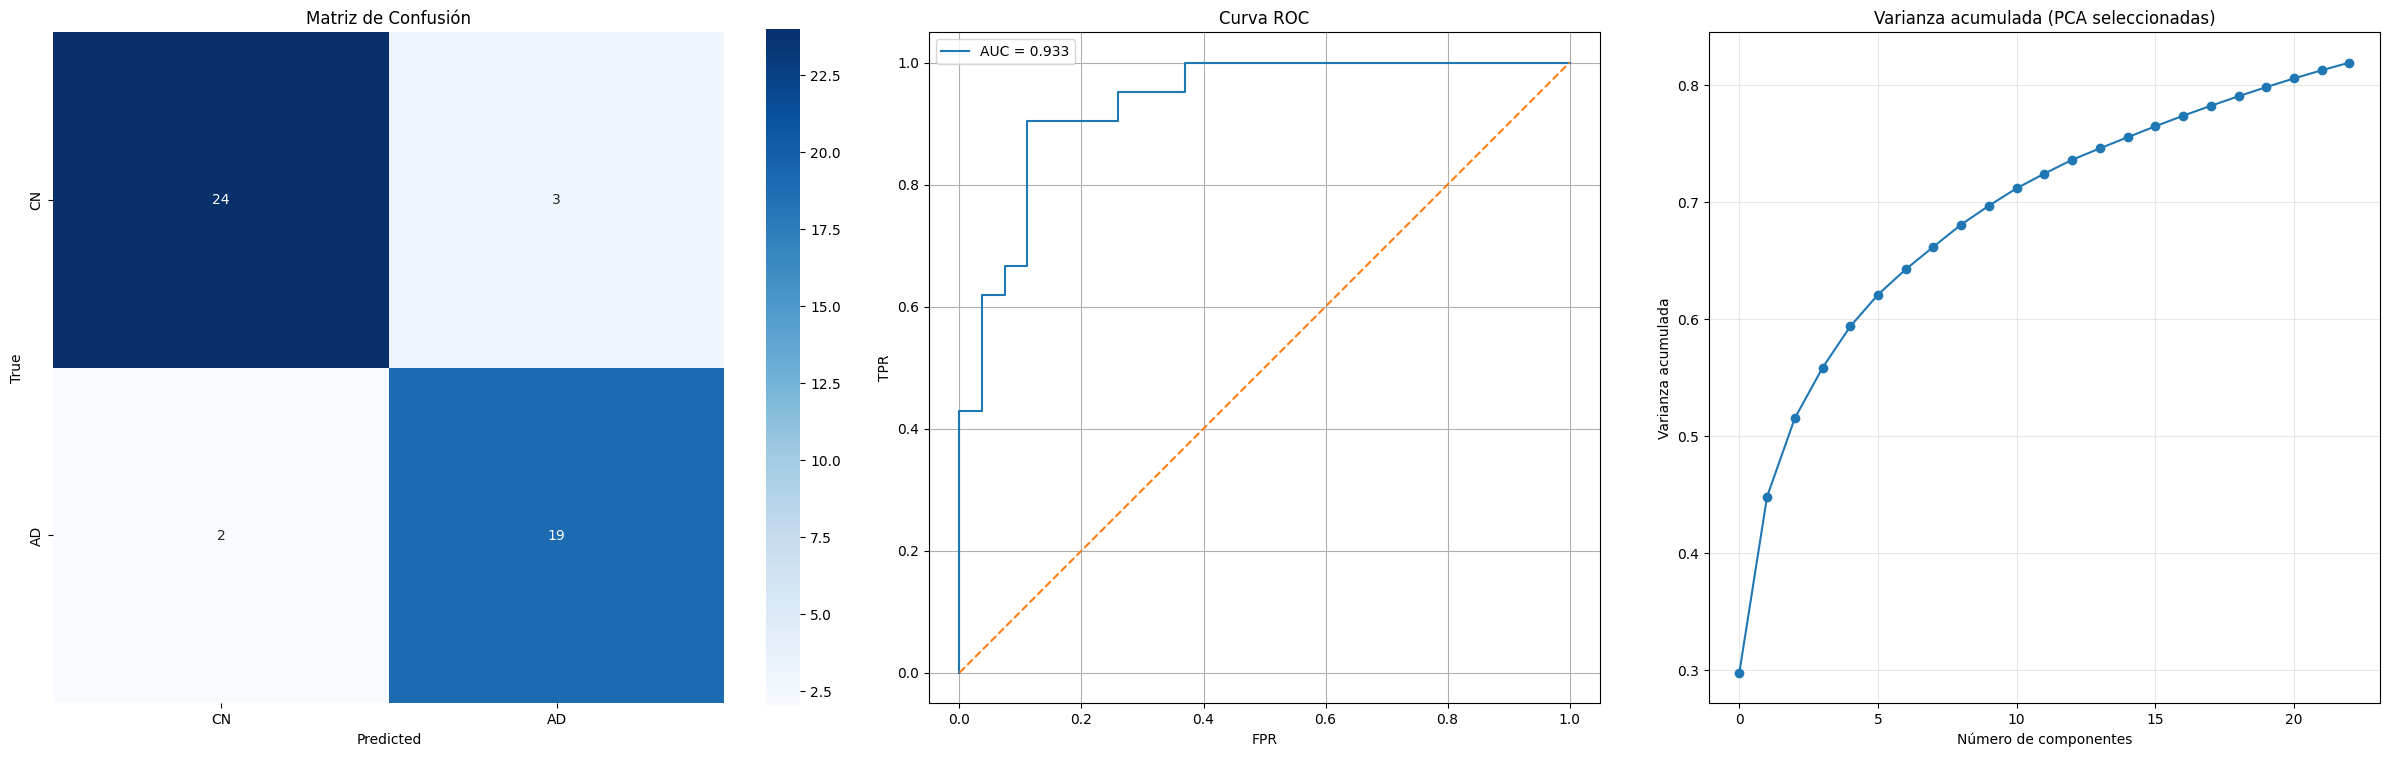


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,29.8083
1,PC2,15.0295
2,PC3,6.6977
3,PC4,4.3078
4,PC5,3.5300
5,PC6,2.7186
6,PC7,2.1555
7,PC8,1.9289
8,PC9,1.8960
9,PC10,1.6084


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('logreg', LogisticRegression(max_iter=10000, class_weight='balanced',  random_state=34)) # Logistic Regression con balanceo de clases desiguales
])

param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'logreg__C': [0.01, 0.1, 1, 10],         # Regularización de la regresión logística
    'logreg__l1_ratio': [0],   
    'logreg__solver': ['saga']  # Solvers permitidos para la configuración
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        n_selected
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# SVM

Fitting 5 folds for each of 6080 candidates, totalling 30400 fits
Mejores parámetros encontrados:
{'pca__n_components': 21, 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8636
1,F1-score (validación),0.8443
2,ROC-AUC (test),0.9436
3,ROC-AUC (validación),0.9046
4,Balanced Accuracy (test),0.8783
5,Balanced Accuracy (validación),0.8539
6,Precision (test),0.8261
7,Precision (validación),0.8398
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8601


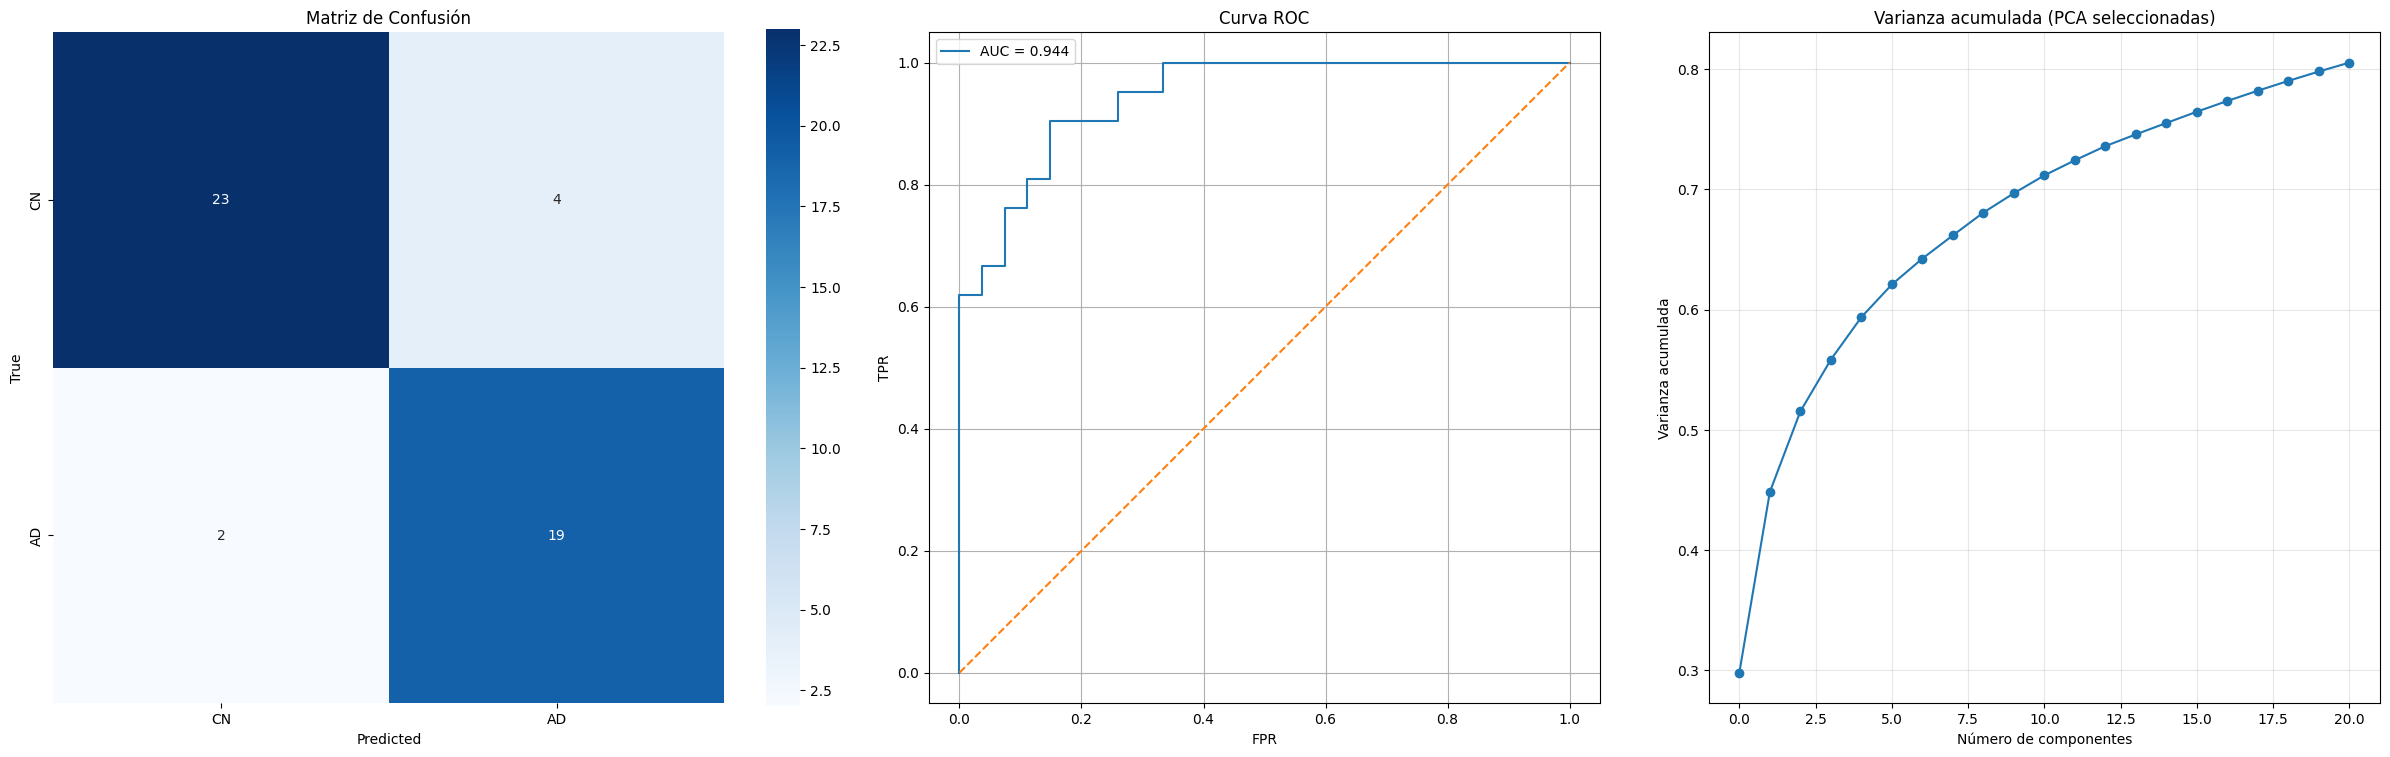


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,29.8083
1,PC2,15.0295
2,PC3,6.6977
3,PC4,4.3078
4,PC5,3.5300
5,PC6,2.7186
6,PC7,2.1555
7,PC8,1.9289
8,PC9,1.8960
9,PC10,1.6084


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('svm', SVC(probability=True, class_weight='balanced', random_state=34)) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        n_selected
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()


# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# Random Forest

Fitting 5 folds for each of 5472 candidates, totalling 27360 fits
Mejores parámetros encontrados:
{'pca__n_components': 12, 'rf__max_depth': 2, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.7917
1,F1-score (validación),0.8147
2,ROC-AUC (test),0.9224
3,ROC-AUC (validación),0.8752
4,Balanced Accuracy (test),0.8042
5,Balanced Accuracy (validación),0.8335
6,Precision (test),0.7037
7,Precision (validación),0.8423
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.7908


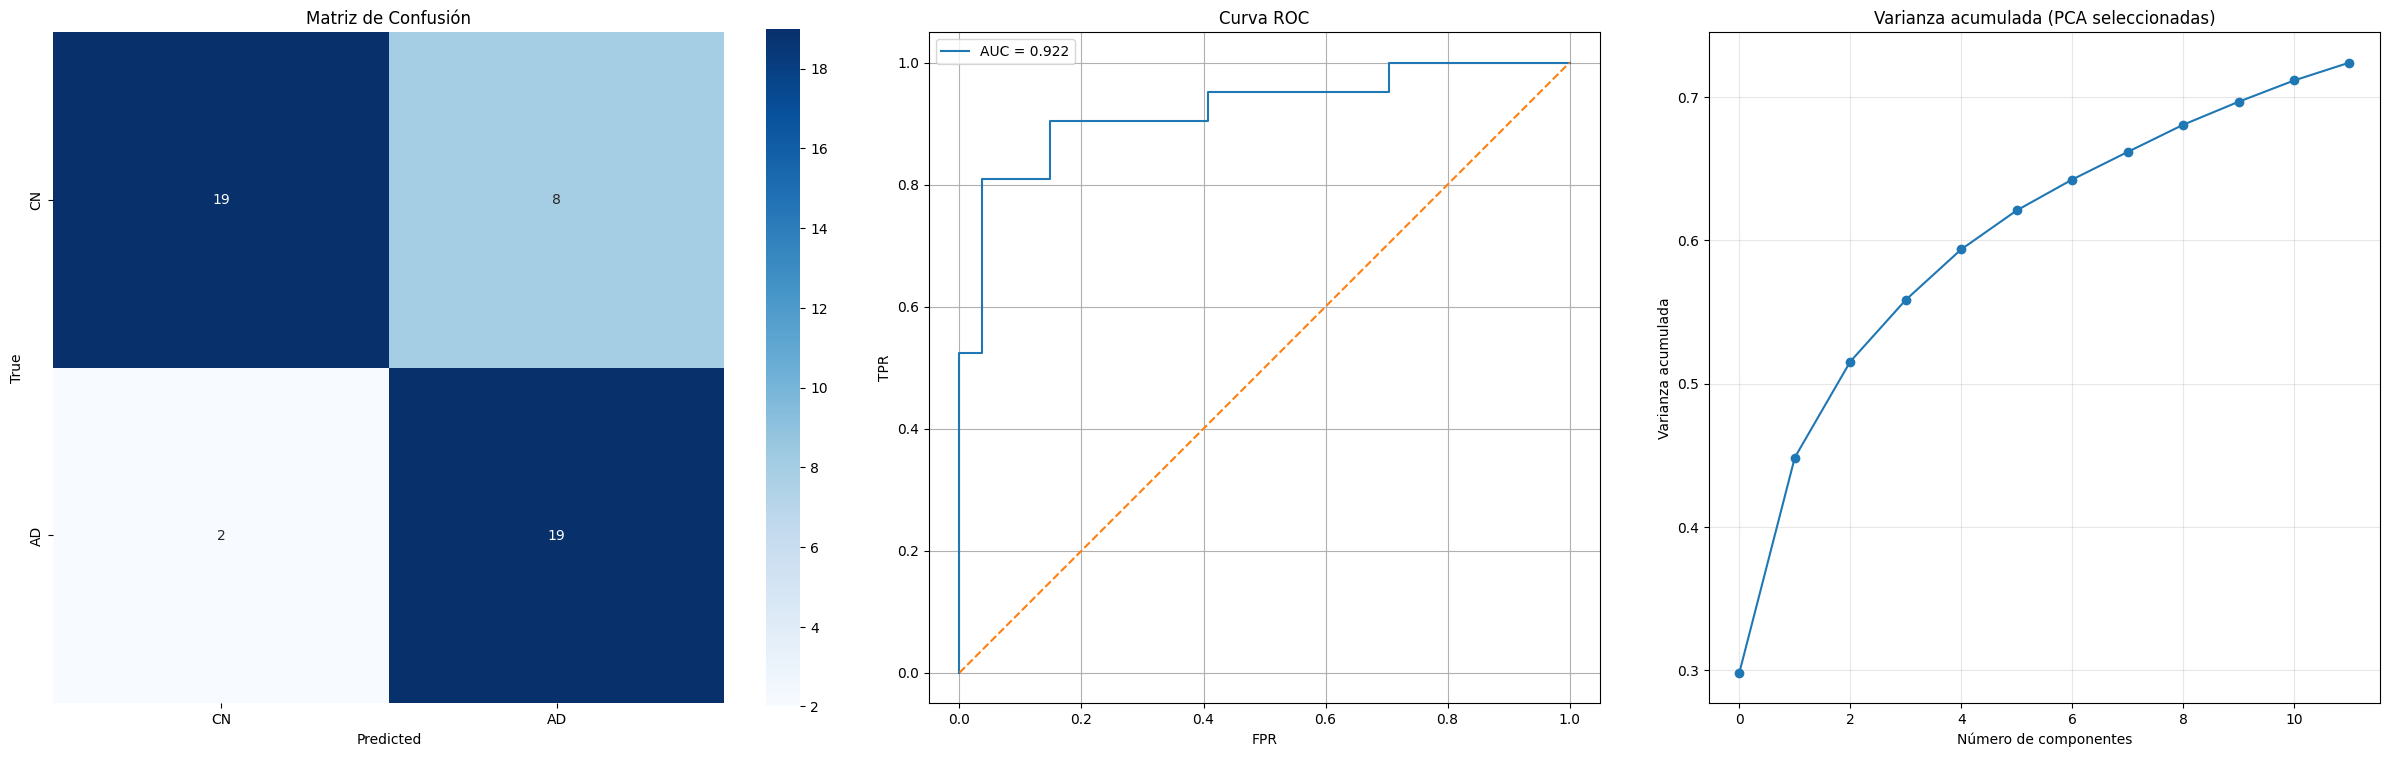


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,29.8083
1,PC2,15.0295
2,PC3,6.6977
3,PC4,4.3078
4,PC5,3.5300
5,PC6,2.7186
6,PC7,2.1555
7,PC8,1.9289
8,PC9,1.8960
9,PC10,1.6084


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("csf_gm_wm_harvard_oxford_ad_m.csv")
df_ad_f = pd.read_csv("csf_gm_wm_harvard_oxford_ad_f.csv")
df_cn_m = pd.read_csv("csf_gm_wm_harvard_oxford_cn_m.csv")
df_cn_f = pd.read_csv("csf_gm_wm_harvard_oxford_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}


# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'csf_gm_wm_harvard_oxford', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# Grosores corticales

# ELASTIC NET

# LOGISTIC REGRESSION

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parámetros encontrados:
{'logreg__C': 1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'selector__estimator__l1_ratio': 0.7, 'selector__max_features': 3}

===== RESUMEN DE MÉTRICAS =====


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,Value
0,F1-score (test),0.8000
1,F1-score (validación),0.8662
2,ROC-AUC (test),0.8907
3,ROC-AUC (validación),0.9105
4,Balanced Accuracy (test),0.8254
5,Balanced Accuracy (validación),0.8802
6,Precision (test),0.8421
7,Precision (validación),0.9028
8,Recall (Sensitivity) (test),0.7619
9,Recall (Sensitivity) (validación),0.8366


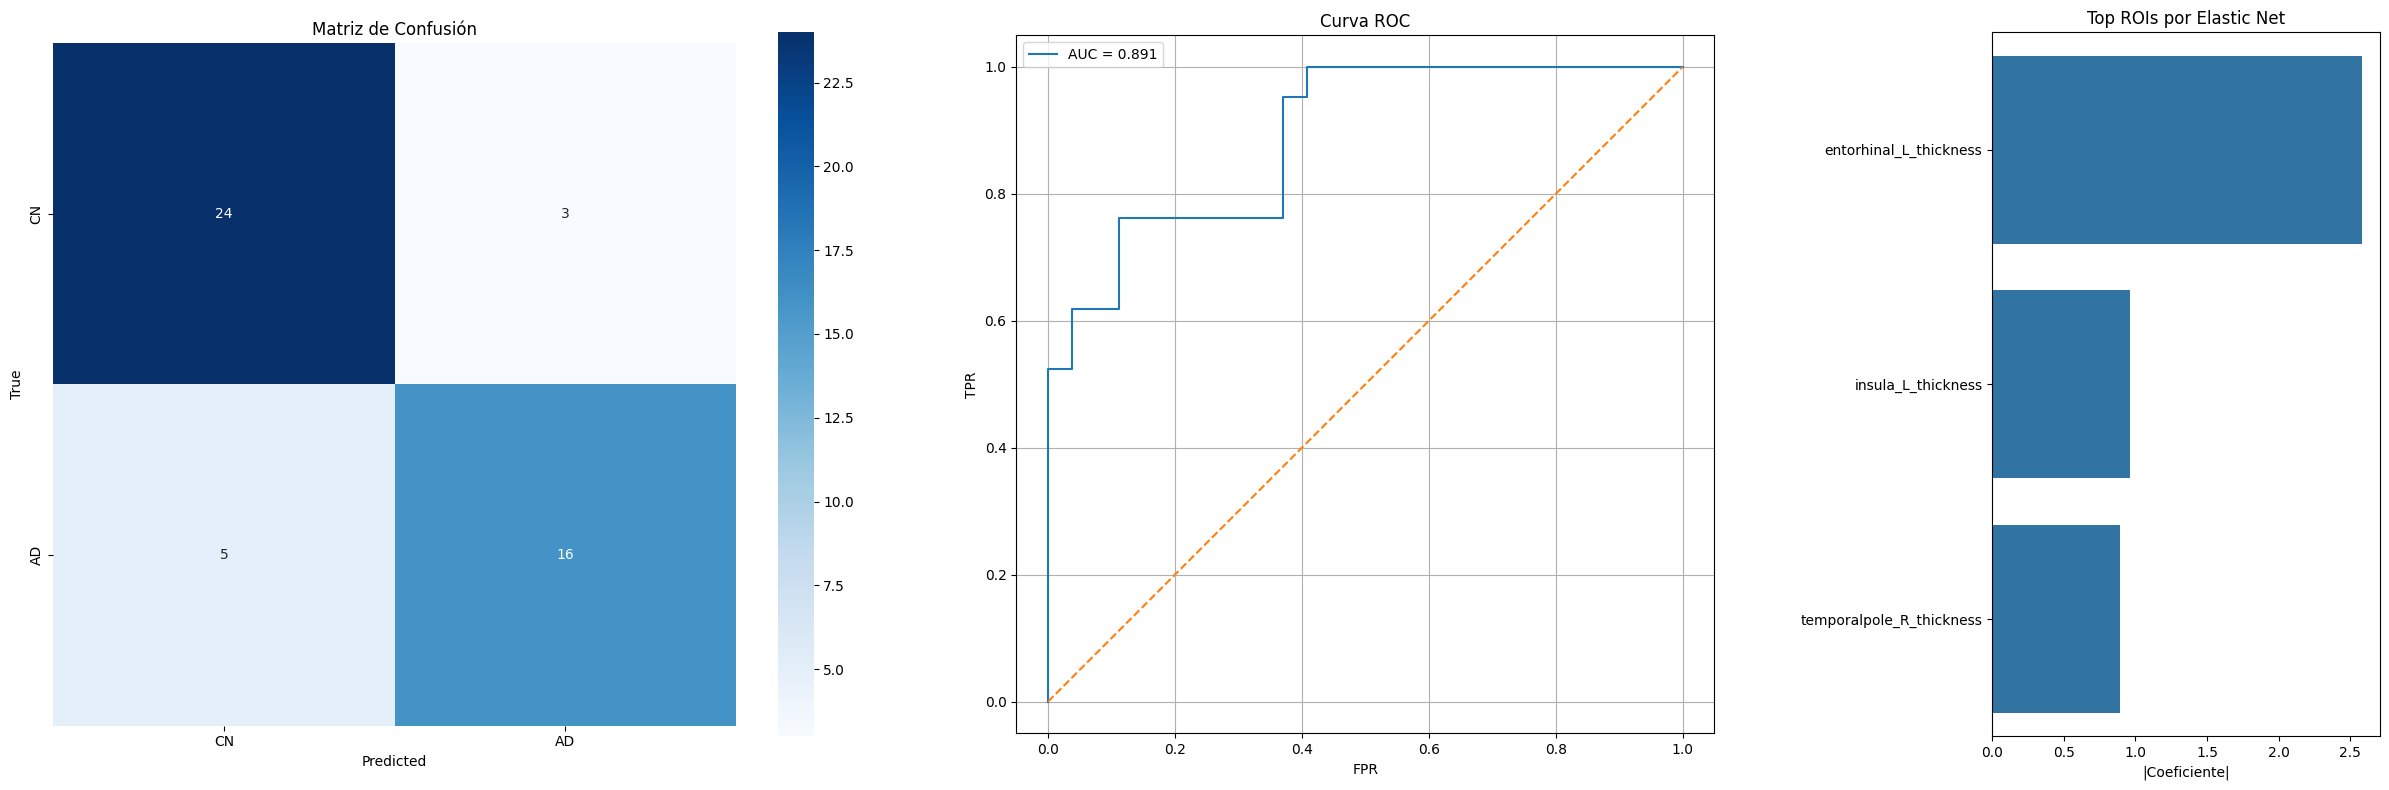


Las 3 ROIs seleccionadas son:
['entorhinal_L_thickness', 'insula_L_thickness', 'temporalpole_R_thickness']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.5785
1,insula_L_thickness,0.9617
2,temporalpole_R_thickness,-0.8919
3,rostralmiddlefrontal_L_thickness,-0.8822
4,insula_R_thickness,-0.7617
5,parsopercularis_L_thickness,0.7599
6,cuneus_L_thickness,0.7374
7,superiortemporal_L_thickness,-0.7009
8,transversetemporal_R_thickness,0.5417
9,paracentral_R_thickness,-0.5233


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"].values

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Logistic Rgression final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('logreg', LogisticRegression(max_iter=10000, random_state=34, class_weight='balanced'))
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__l1_ratio': [0],
    'logreg__solver': ['saga']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.65, 1.35, 0.75]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.035,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'selector__estimator__l1_ratio': 0.7, 'selector__max_features': 3, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.7805
1,F1-score (validación),0.8662
2,ROC-AUC (test),0.8889
3,ROC-AUC (validación),0.9105
4,Balanced Accuracy (test),0.8069
5,Balanced Accuracy (validación),0.8802
6,Precision (test),0.8000
7,Precision (validación),0.9028
8,Recall (Sensitivity) (test),0.7619
9,Recall (Sensitivity) (validación),0.8366


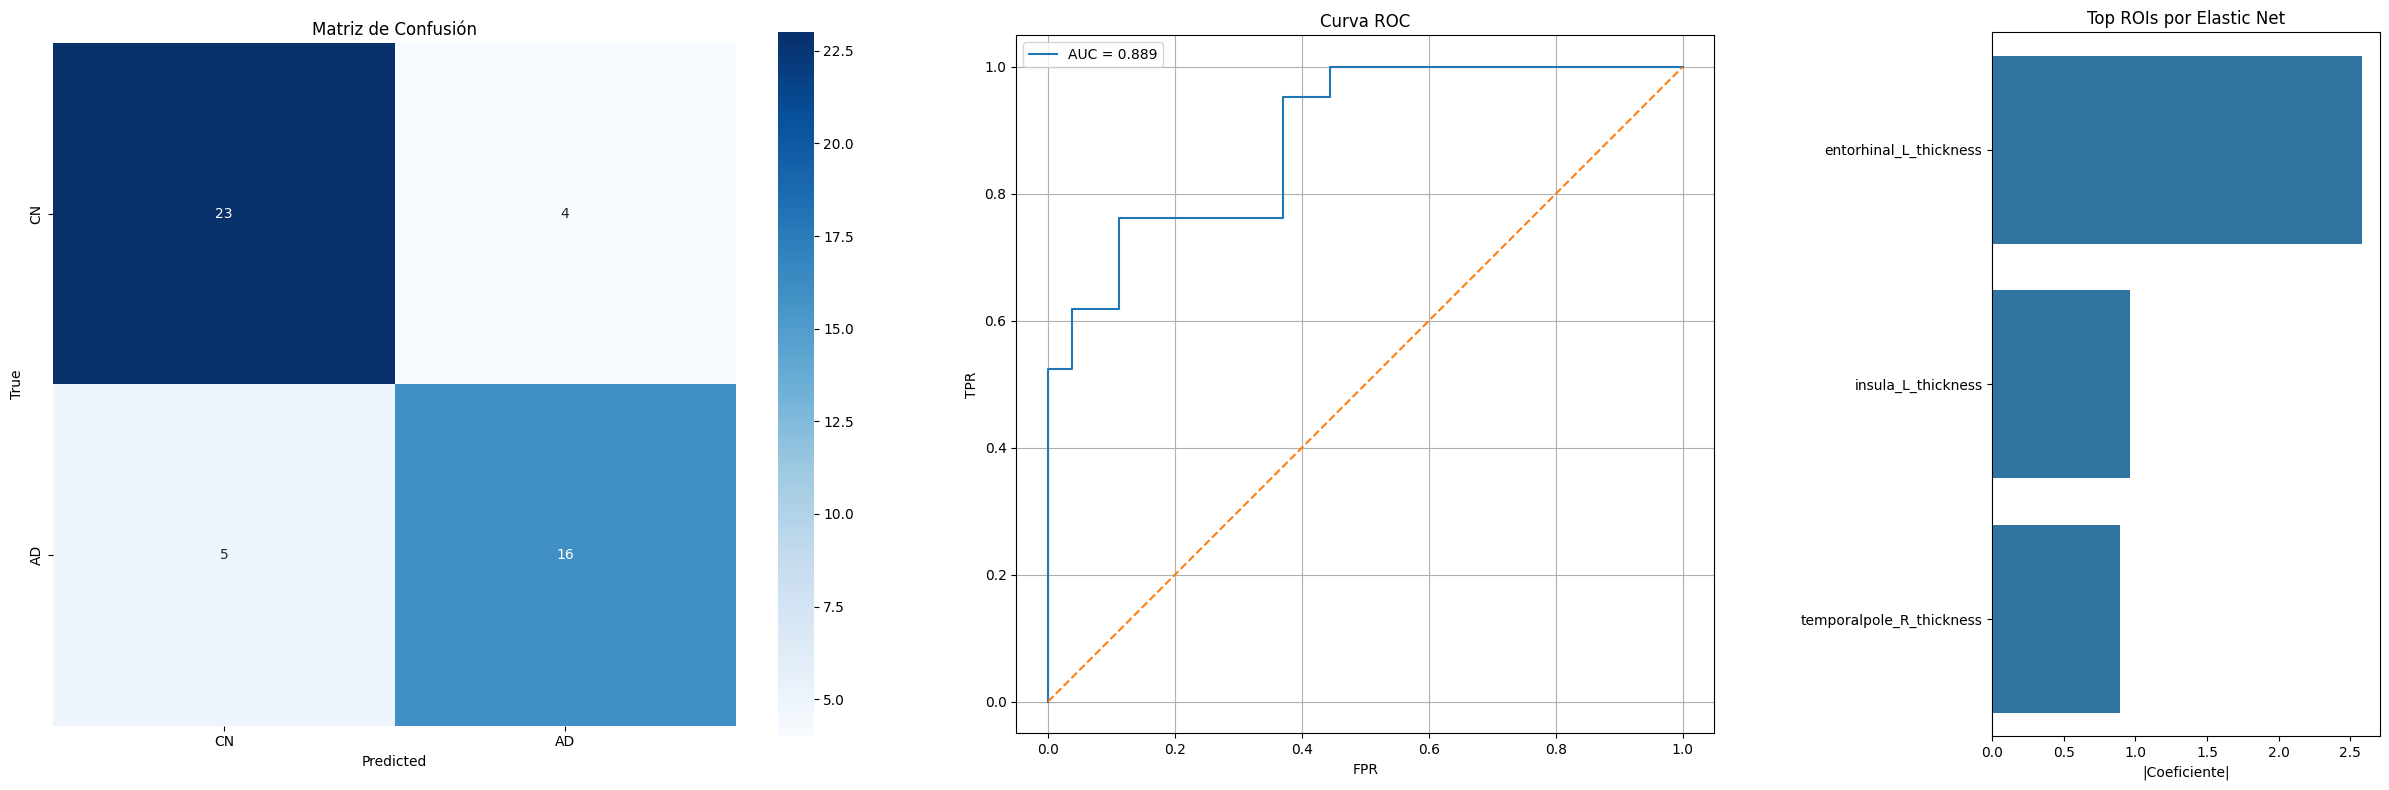


Las 3 ROIs seleccionadas son:
['entorhinal_L_thickness', 'insula_L_thickness', 'temporalpole_R_thickness']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.5785
1,insula_L_thickness,0.9617
2,temporalpole_R_thickness,-0.8919
3,rostralmiddlefrontal_L_thickness,-0.8822
4,insula_R_thickness,-0.7617
5,parsopercularis_L_thickness,0.7599
6,cuneus_L_thickness,0.7374
7,superiortemporal_L_thickness,-0.7009
8,transversetemporal_R_thickness,0.5417
9,paracentral_R_thickness,-0.5233


In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"].values

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight= 'balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> SVC final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('svm',  SVC(probability=True, random_state=34, class_weight= 'balanced')) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.65, 1.35, 0.75]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.035,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 5, 'rf__n_estimators': 50, 'selector__estimator__l1_ratio': 0.7, 'selector__max_features': 16}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.7442
1,F1-score (validación),0.8685
2,ROC-AUC (test),0.8924
3,ROC-AUC (validación),0.8985
4,Balanced Accuracy (test),0.7698
5,Balanced Accuracy (validación),0.8817
6,Precision (test),0.7273
7,Precision (validación),0.8960
8,Recall (Sensitivity) (test),0.7619
9,Recall (Sensitivity) (validación),0.8490


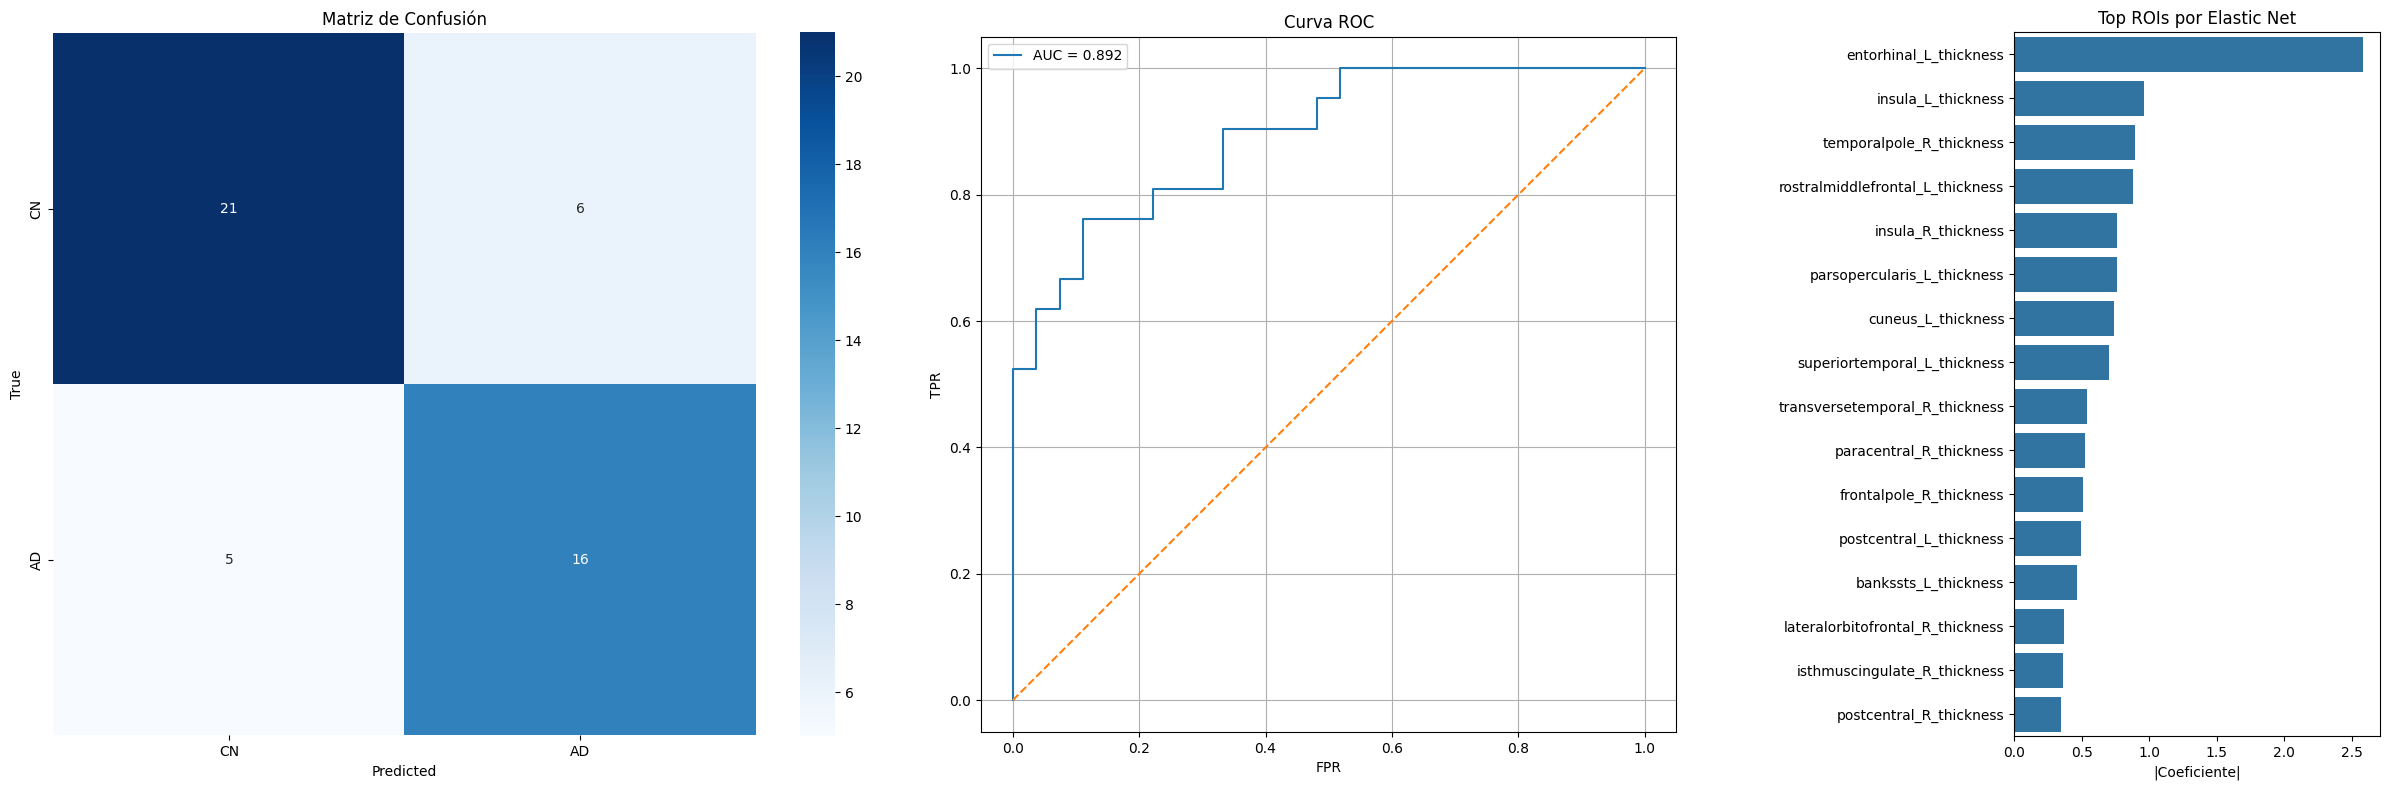


Las 16 ROIs seleccionadas son:
['bankssts_L_thickness', 'cuneus_L_thickness', 'entorhinal_L_thickness', 'parsopercularis_L_thickness', 'postcentral_L_thickness', 'rostralmiddlefrontal_L_thickness', 'superiortemporal_L_thickness', 'insula_L_thickness', 'isthmuscingulate_R_thickness', 'lateralorbitofrontal_R_thickness', 'paracentral_R_thickness', 'postcentral_R_thickness', 'frontalpole_R_thickness', 'temporalpole_R_thickness', 'transversetemporal_R_thickness', 'insula_R_thickness']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.5785
1,insula_L_thickness,0.9617
2,temporalpole_R_thickness,-0.8919
3,rostralmiddlefrontal_L_thickness,-0.8822
4,insula_R_thickness,-0.7617
5,parsopercularis_L_thickness,0.7599
6,cuneus_L_thickness,0.7374
7,superiortemporal_L_thickness,-0.7009
8,transversetemporal_R_thickness,0.5417
9,paracentral_R_thickness,-0.5233


In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")


# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"].values

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 0.95, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.06,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# RFE

# LOGISTIC REGRESSION

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores parámetros encontrados:
{'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 3}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.8000
1,F1-score (validación),0.8629
2,ROC-AUC (test),0.8801
3,ROC-AUC (validación),0.9098
4,Balanced Accuracy (test),0.8254
5,Balanced Accuracy (validación),0.8766
6,Precision (test),0.8421
7,Precision (validación),0.8852
8,Recall (Sensitivity) (test),0.7619
9,Recall (Sensitivity) (validación),0.8484


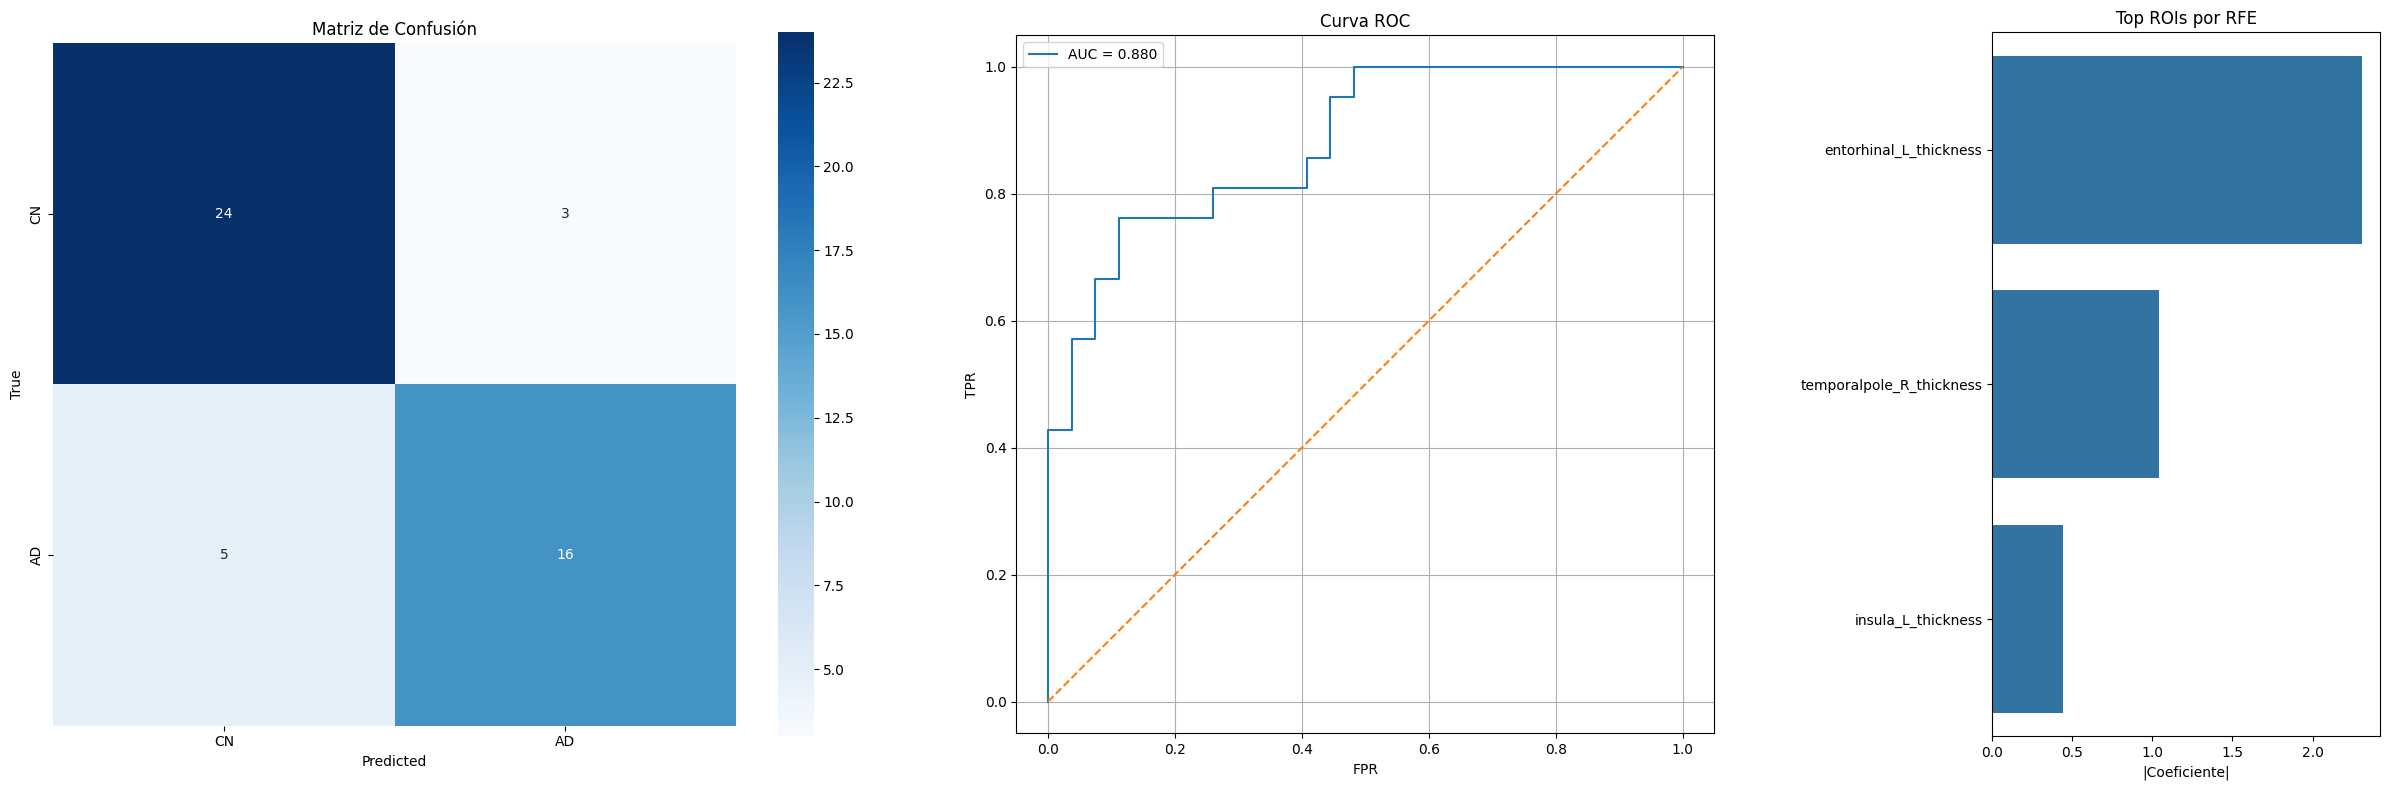


Las 3 ROIs seleccionadas por RFE son:
['entorhinal_L_thickness', 'insula_L_thickness', 'temporalpole_R_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.3059
1,temporalpole_R_thickness,-1.0397
2,insula_L_thickness,0.4421
3,bankssts_L_thickness,0.0000
4,cuneus_L_thickness,0.0000
5,caudalmiddlefrontal_L_thickness,0.0000
6,caudalanteriorcingulate_L_thickness,0.0000
7,inferiorparietal_L_thickness,0.0000
8,isthmuscingulate_L_thickness,0.0000
9,lateraloccipital_L_thickness,0.0000


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística y balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('logreg', LogisticRegression(max_iter= 10000, random_state=34, class_weight='balanced'))  # Logistic Regression con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0],          # L2
        'logreg__C': [0.01,0.1,1,10]    # Regularización
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.65, 1.35, 0.75]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.035,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Mejores parámetros encontrados:
{'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 2, 'svm__C': 0.1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.7805
1,F1-score (validación),0.8629
2,ROC-AUC (test),0.8783
3,ROC-AUC (validación),0.8937
4,Balanced Accuracy (test),0.8069
5,Balanced Accuracy (validación),0.8766
6,Precision (test),0.8000
7,Precision (validación),0.8852
8,Recall (Sensitivity) (test),0.7619
9,Recall (Sensitivity) (validación),0.8484


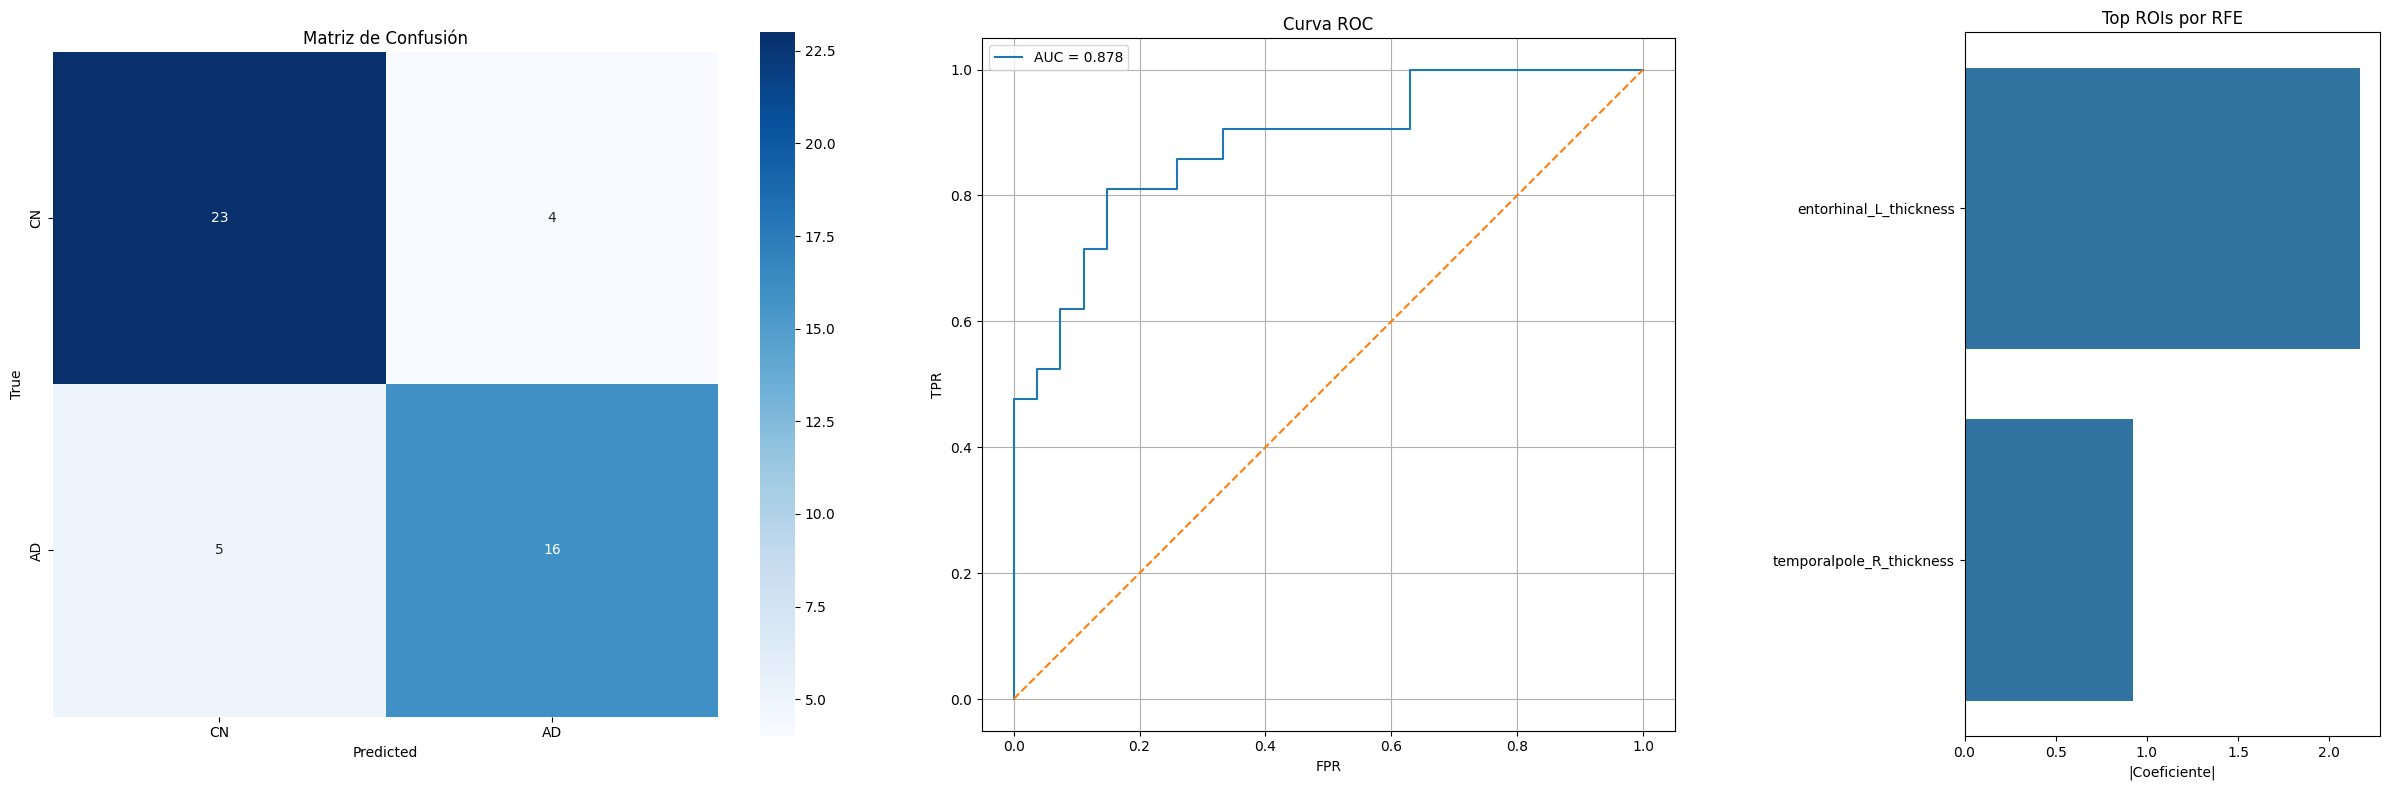


Las 2 ROIs seleccionadas por RFE son:
['entorhinal_L_thickness', 'temporalpole_R_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.1704
1,temporalpole_R_thickness,-0.9263
2,bankssts_L_thickness,0.0000
3,caudalanteriorcingulate_L_thickness,0.0000
4,cuneus_L_thickness,0.0000
5,caudalmiddlefrontal_L_thickness,0.0000
6,inferiorparietal_L_thickness,0.0000
7,fusiform_L_thickness,0.0000
8,isthmuscingulate_L_thickness,0.0000
9,lateraloccipital_L_thickness,0.0000


In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('svm',SVC(probability=True, random_state=34, class_weight='balanced'))  # SVM con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + SVM
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'svm__C': [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svm__kernel': ['linear', 'rbf']
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.6]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 100, 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 10}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.7805
1,F1-score (validación),0.8583
2,ROC-AUC (test),0.9153
3,ROC-AUC (validación),0.9023
4,Balanced Accuracy (test),0.8069
5,Balanced Accuracy (validación),0.8721
6,Precision (test),0.8000
7,Precision (validación),0.8756
8,Recall (Sensitivity) (test),0.7619
9,Recall (Sensitivity) (validación),0.8490


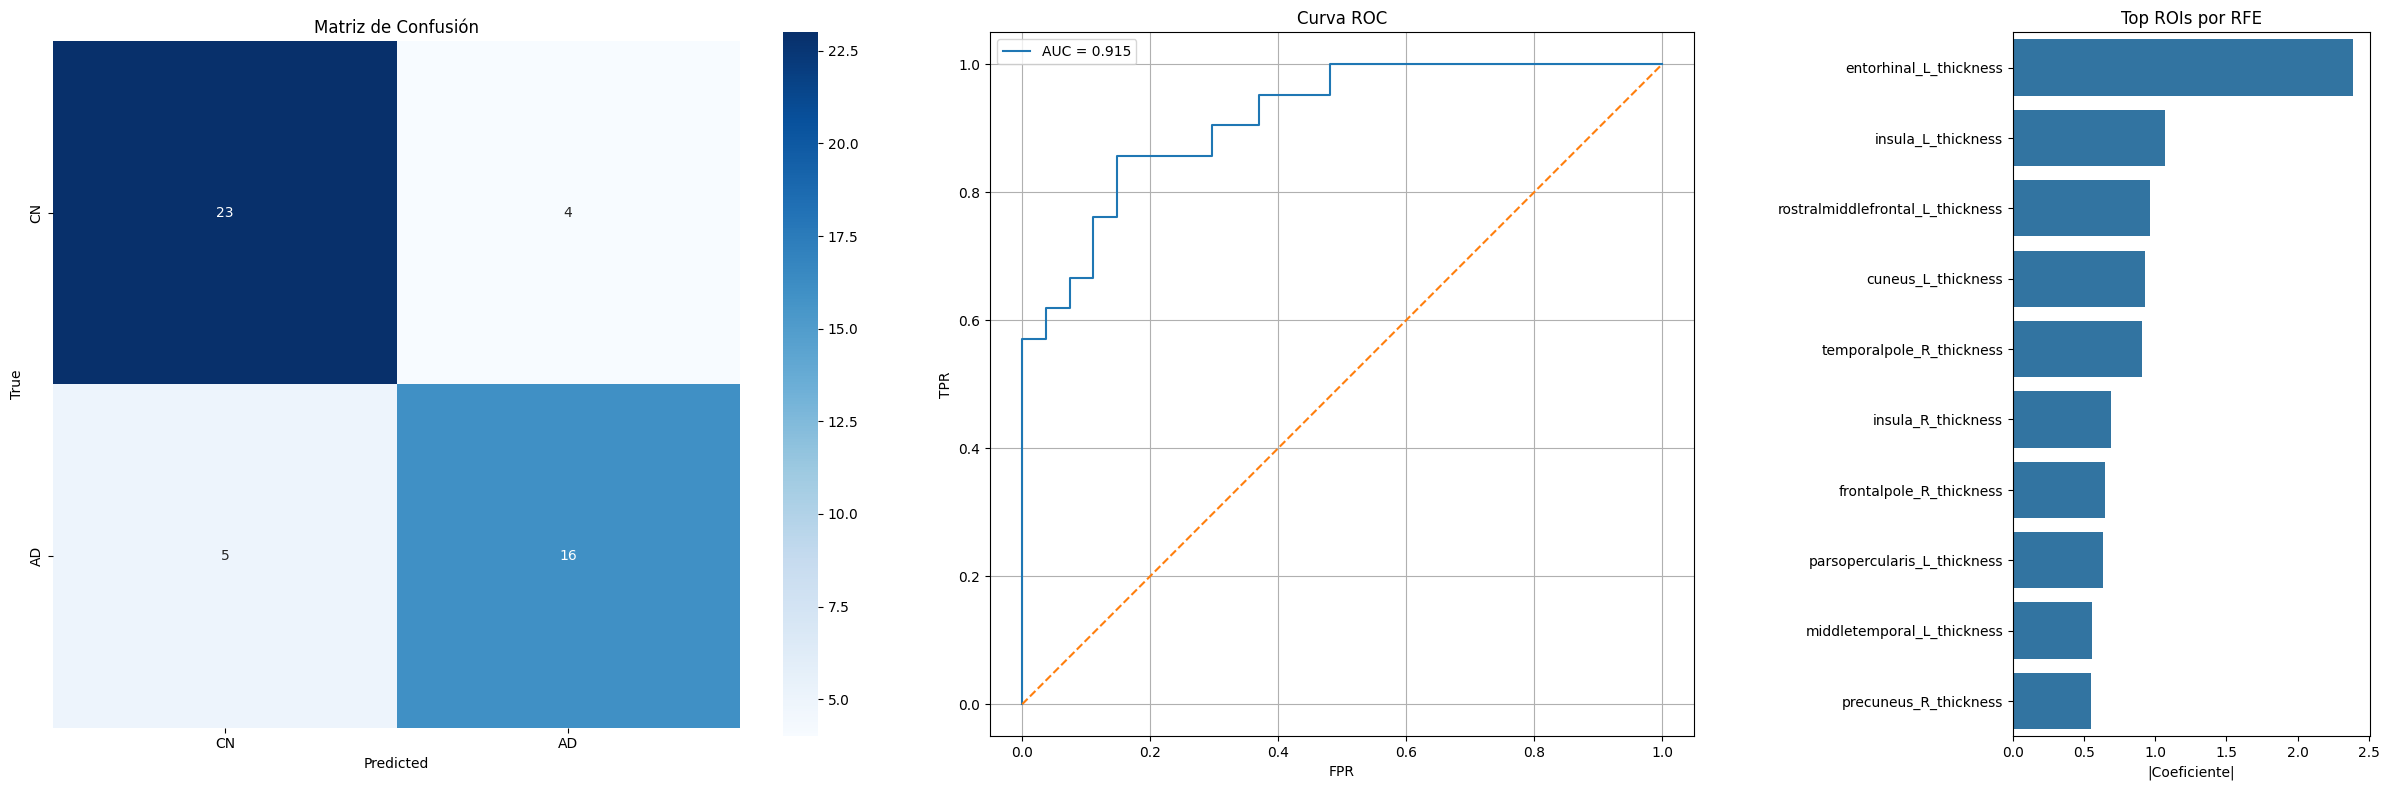


Las 10 ROIs seleccionadas por RFE son:
['cuneus_L_thickness', 'entorhinal_L_thickness', 'middletemporal_L_thickness', 'parsopercularis_L_thickness', 'rostralmiddlefrontal_L_thickness', 'insula_L_thickness', 'precuneus_R_thickness', 'frontalpole_R_thickness', 'temporalpole_R_thickness', 'insula_R_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.3908
1,insula_L_thickness,1.0691
2,rostralmiddlefrontal_L_thickness,-0.9617
3,cuneus_L_thickness,0.9251
4,temporalpole_R_thickness,-0.9097
5,insula_R_thickness,-0.6882
6,frontalpole_R_thickness,0.6472
7,parsopercularis_L_thickness,0.6301
8,middletemporal_L_thickness,-0.5584
9,precuneus_R_thickness,-0.5525


In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced'))  # Random Forest con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + Random Forest
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [2, 3, 5],
        'rf__min_samples_split': [5, 10],
        'rf__min_samples_leaf': [2, 4]
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.2, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.05,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# PCA

# LOGISTIC REGRESSION

Fitting 5 folds for each of 272 candidates, totalling 1360 fits
Mejores parámetros encontrados:
{'logreg__C': 10, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'pca__n_components': 21}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8095
1,F1-score (validación),0.8580
2,ROC-AUC (test),0.9295
3,ROC-AUC (validación),0.8962
4,Balanced Accuracy (test),0.8307
5,Balanced Accuracy (validación),0.8718
6,Precision (test),0.8095
7,Precision (validación),0.8701
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.8484


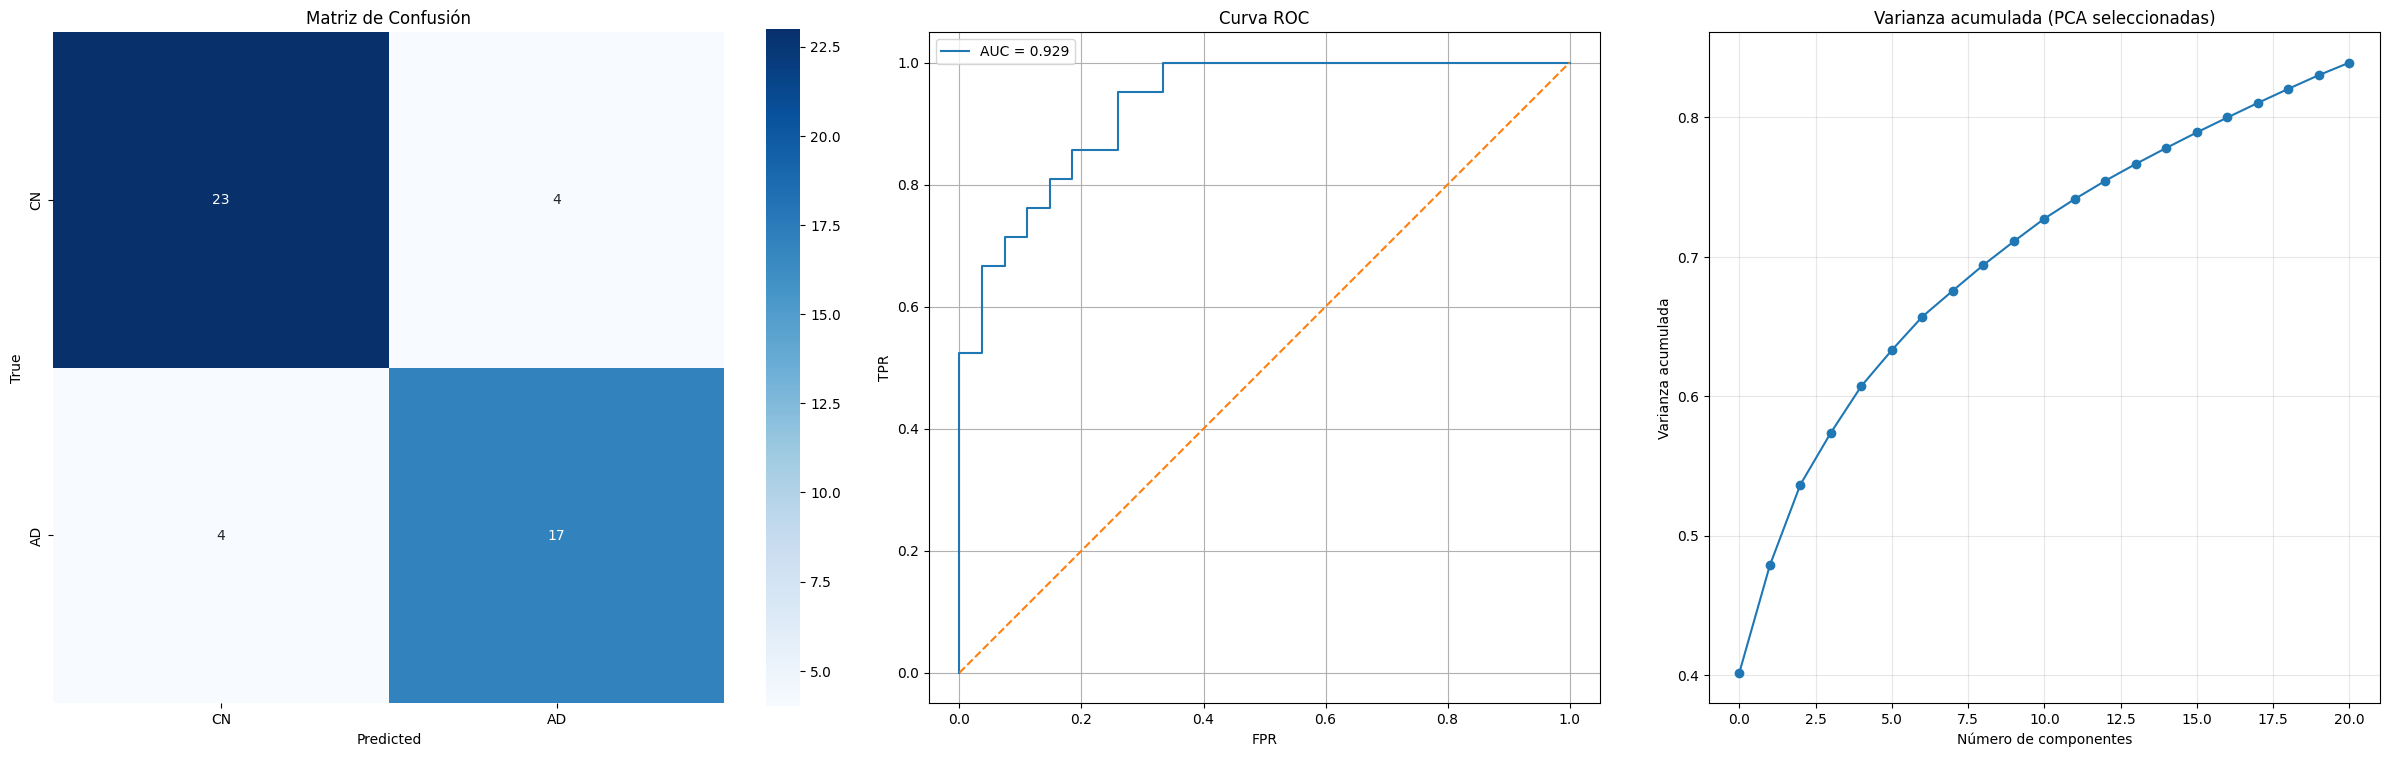


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,40.1590
1,PC2,7.7002
2,PC3,5.7910
3,PC4,3.7259
4,PC5,3.3480
5,PC6,2.5793
6,PC7,2.4004
7,PC8,1.8657
8,PC9,1.8371
9,PC10,1.6959


In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('logreg', LogisticRegression(max_iter=10000, class_weight='balanced',  random_state=34)) # Logistic Regression con balanceo de clases desiguales
])

param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'logreg__C': [0.01, 0.1, 1, 10],         # Regularización de la regresión logística
    'logreg__l1_ratio': [0],   
    'logreg__solver': ['saga']  # Solvers permitidos para la configuración
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# SVM

Fitting 5 folds for each of 2720 candidates, totalling 13600 fits
Mejores parámetros encontrados:
{'pca__n_components': 26, 'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8718
1,F1-score (validación),0.8577
2,ROC-AUC (test),0.9806
3,ROC-AUC (validación),0.9145
4,Balanced Accuracy (test),0.8862
5,Balanced Accuracy (validación),0.8724
6,Precision (test),0.9444
7,Precision (validación),0.9257
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.8020


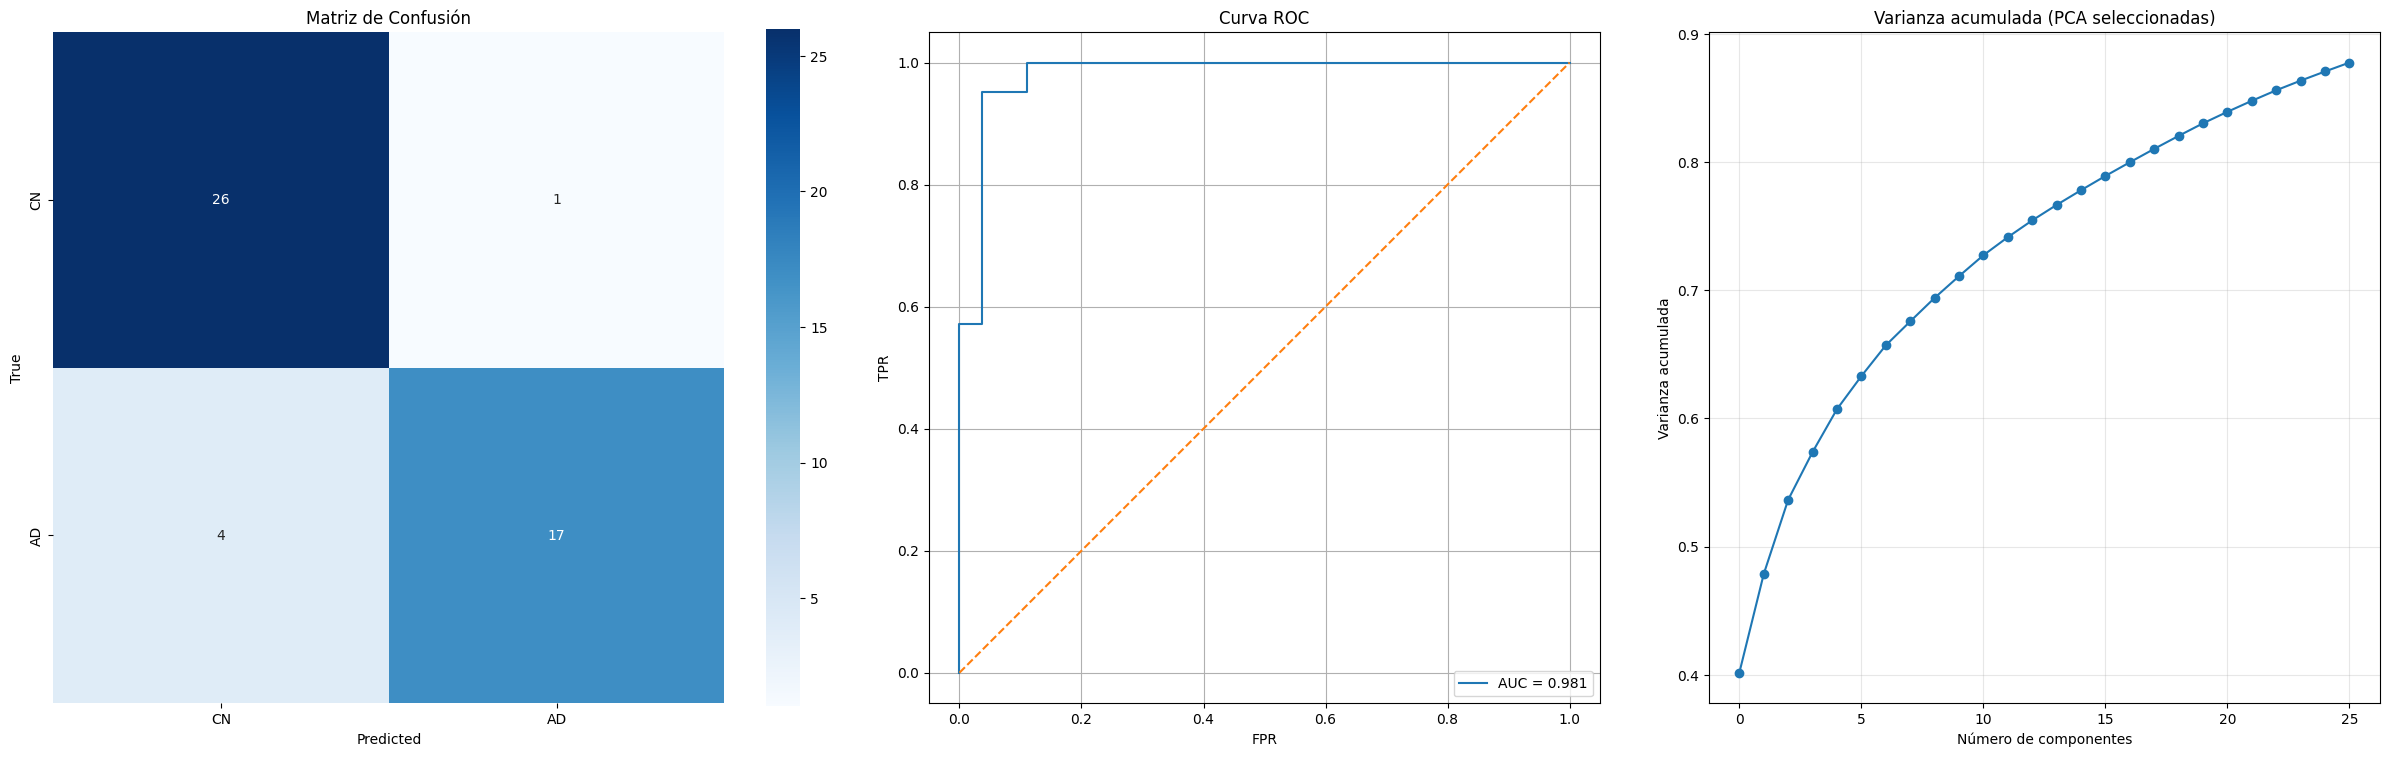


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,40.1590
1,PC2,7.7002
2,PC3,5.7910
3,PC4,3.7259
4,PC5,3.3480
5,PC6,2.5793
6,PC7,2.4004
7,PC8,1.8657
8,PC9,1.8371
9,PC10,1.6959


In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('svm', SVC(probability=True, class_weight='balanced', random_state=34)) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# Random Forest

Fitting 5 folds for each of 2448 candidates, totalling 12240 fits
Mejores parámetros encontrados:
{'pca__n_components': 13, 'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8500
1,F1-score (validación),0.8460
2,ROC-AUC (test),0.9453
3,ROC-AUC (validación),0.9063
4,Balanced Accuracy (test),0.8677
5,Balanced Accuracy (validación),0.8621
6,Precision (test),0.8947
7,Precision (validación),0.9107
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.7908


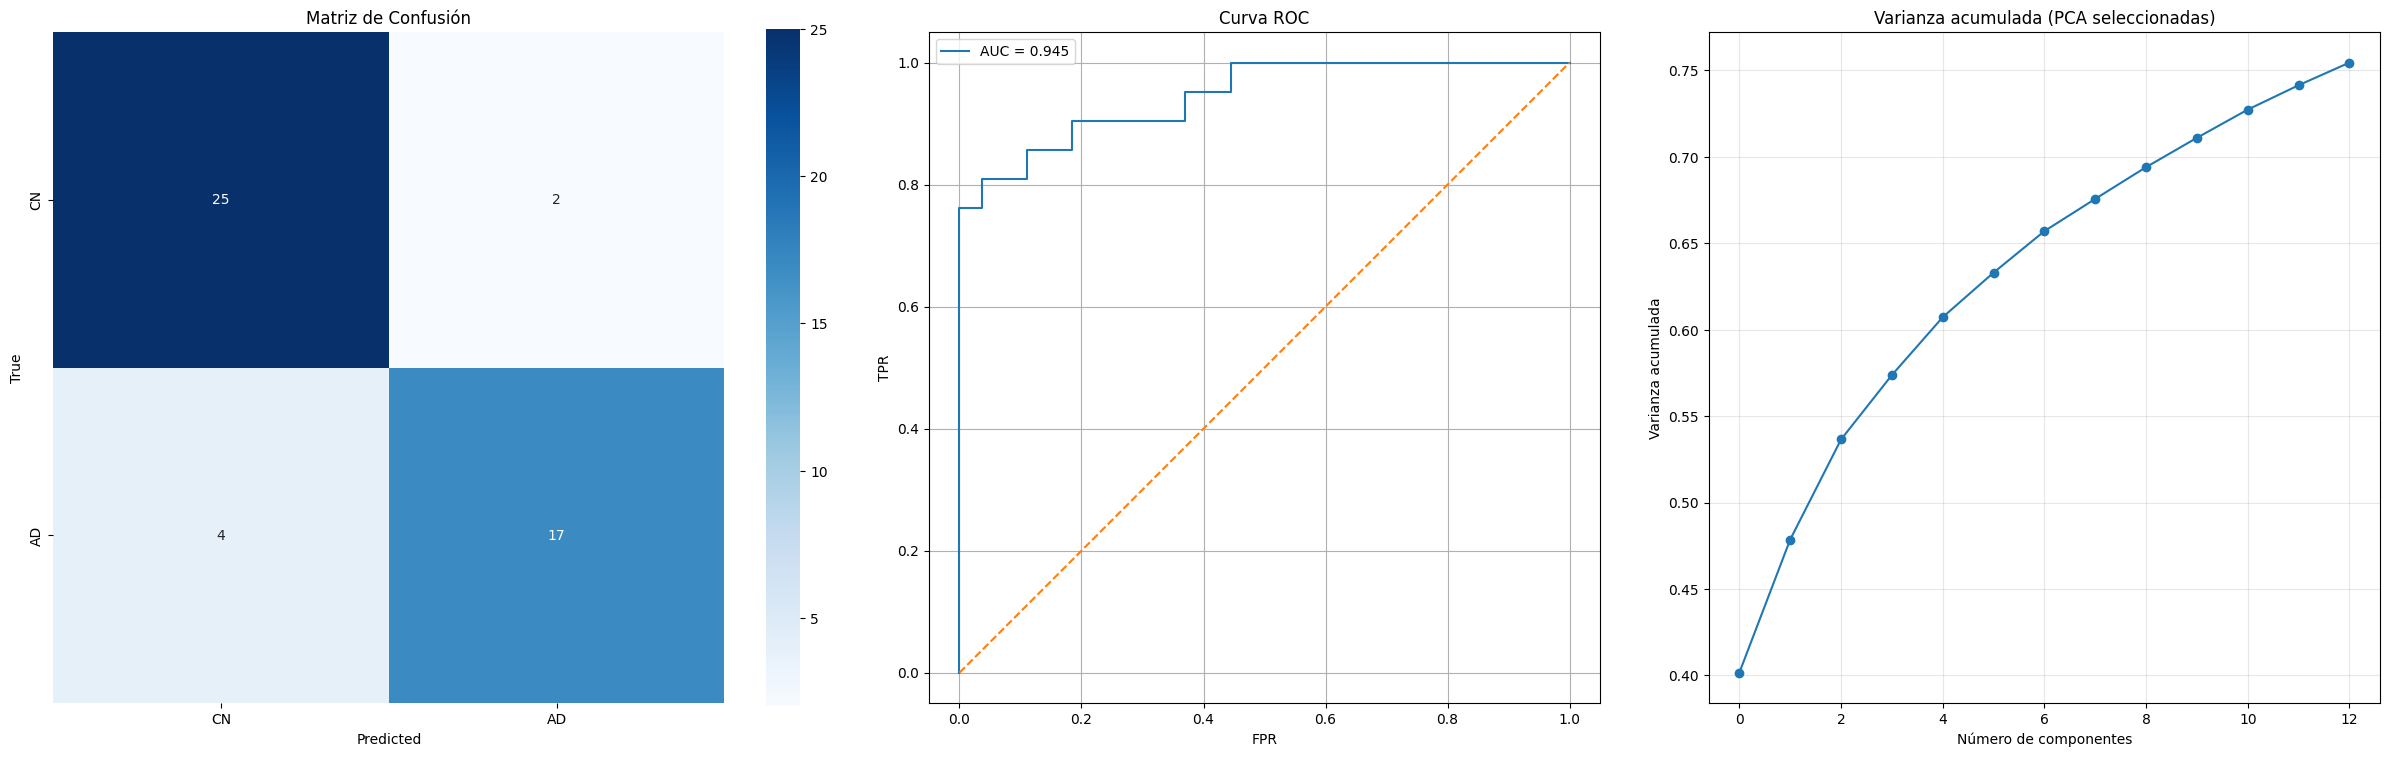


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,40.1590
1,PC2,7.7002
2,PC3,5.7910
3,PC4,3.7259
4,PC5,3.3480
5,PC6,2.5793
6,PC7,2.4004
7,PC8,1.8657
8,PC9,1.8371
9,PC10,1.6959


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}


# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# volúmenes

# ELASTIC NET

# LOGISTIC REGRESSION

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parámetros encontrados:
{'logreg__C': 1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 4}

===== RESUMEN DE MÉTRICAS =====


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,Value
0,F1-score (test),0.7826
1,F1-score (validación),0.8580
2,ROC-AUC (test),0.8907
3,ROC-AUC (validación),0.9108
4,Balanced Accuracy (test),0.7989
5,Balanced Accuracy (validación),0.8715
6,Precision (test),0.7200
7,Precision (validación),0.8713
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8477


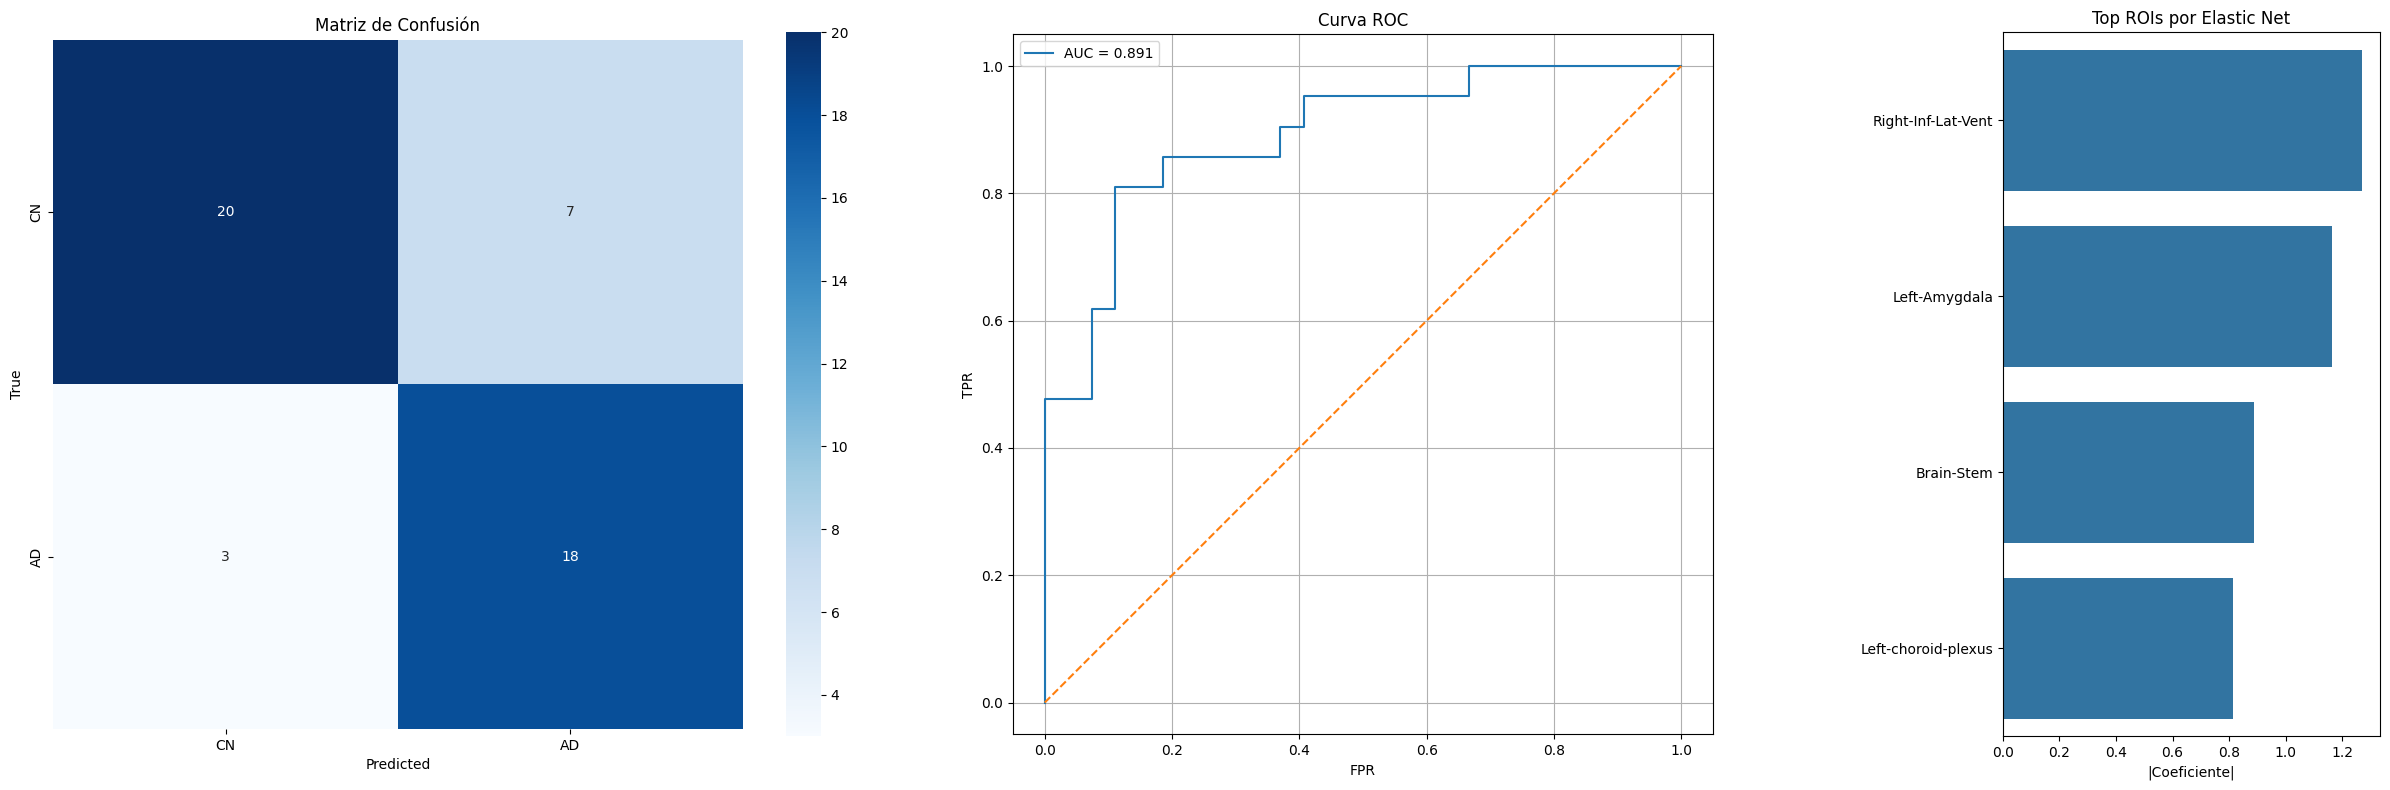


Las 4 ROIs seleccionadas son:
['Brain-Stem', 'Left-Amygdala', 'Left-choroid-plexus', 'Right-Inf-Lat-Vent']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,Right-Inf-Lat-Vent,1.2708
1,Left-Amygdala,-1.1639
2,Brain-Stem,-0.8874
3,Left-choroid-plexus,0.8139
4,Right-Hippocampus,-0.7383
5,Right-Amygdala,-0.6016
6,Right-choroid-plexus,-0.5876
7,Left-Hippocampus,-0.5389
8,Right-Lateral-Ventricle,-0.5241
9,Right-Pallidum,0.4843


In [58]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Logistic Rgression final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('logreg', LogisticRegression(max_iter=10000, random_state=34, class_weight='balanced'))
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__l1_ratio': [0],
    'logreg__solver': ['saga']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.6, 1.3, 0.7]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
Mejores parámetros encontrados:
{'selector__estimator__l1_ratio': 0.7, 'selector__max_features': 8, 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS =====


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,Value
0,F1-score (test),0.7660
1,F1-score (validación),0.8544
2,ROC-AUC (test),0.9206
3,ROC-AUC (validación),0.9059
4,Balanced Accuracy (test),0.7804
5,Balanced Accuracy (validación),0.8682
6,Precision (test),0.6923
7,Precision (validación),0.8541
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8601


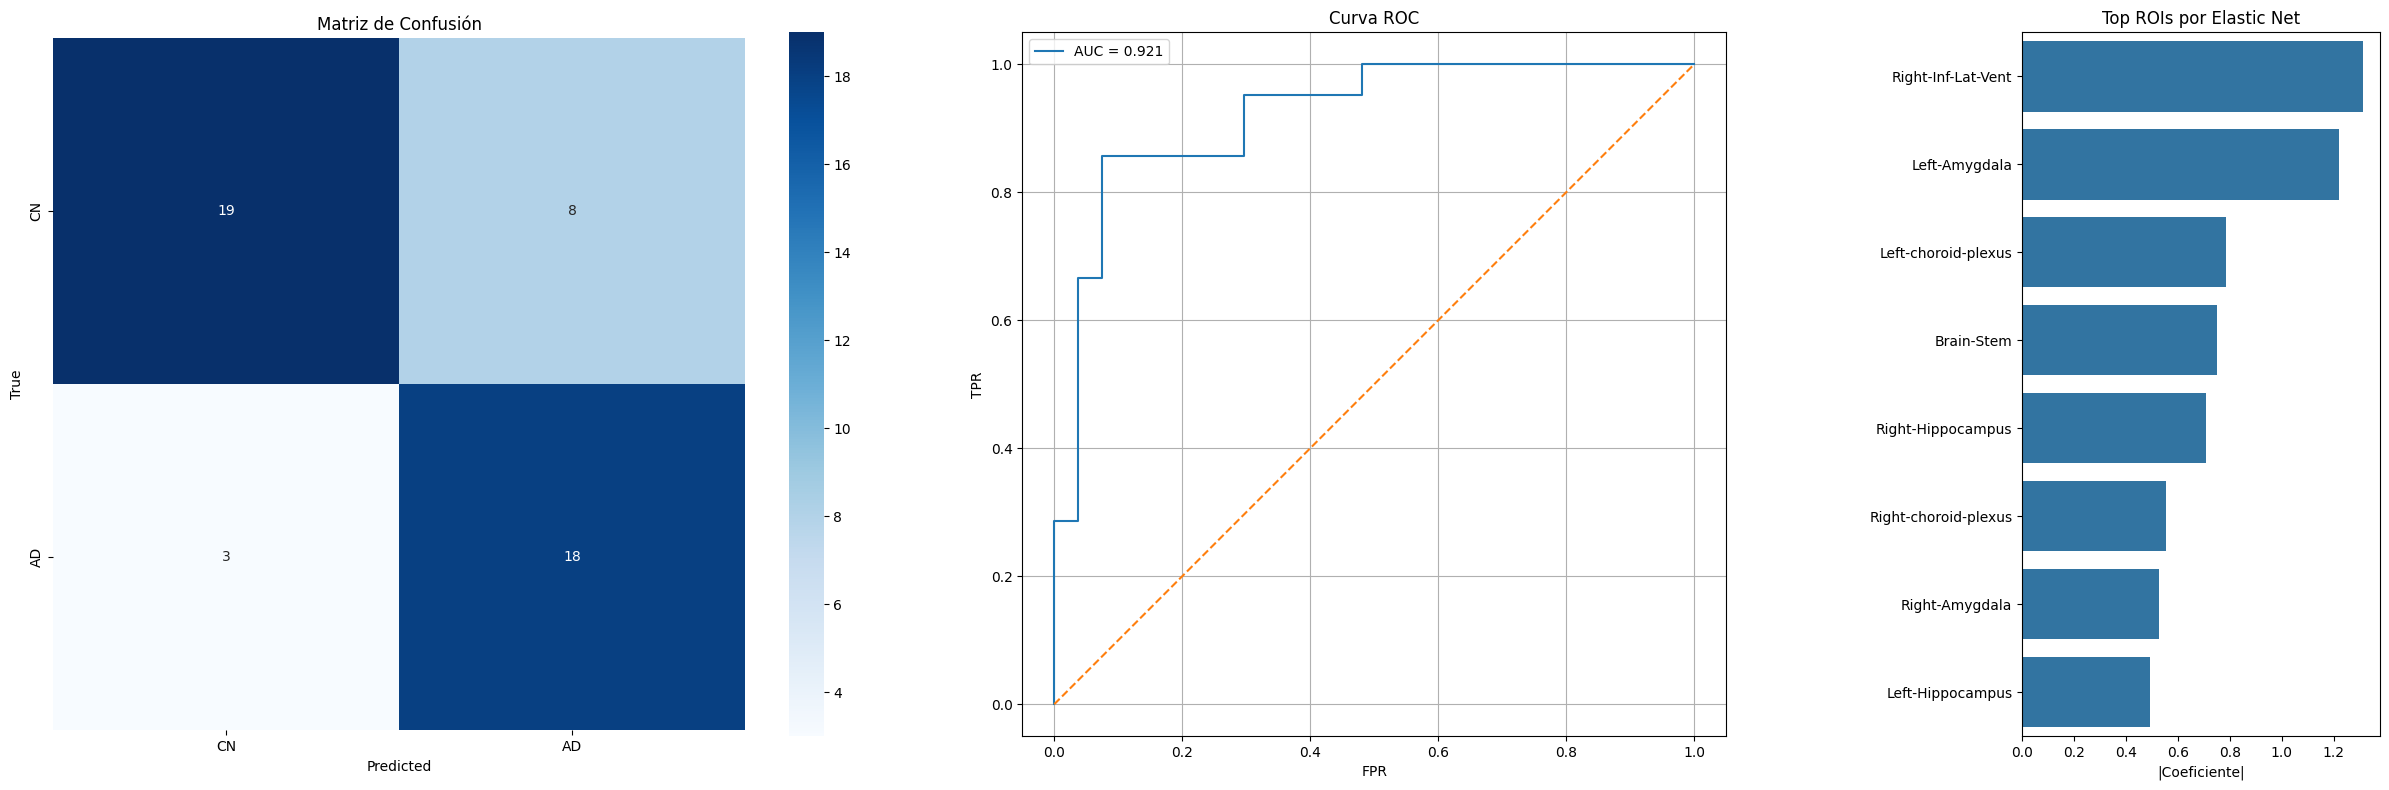


Las 8 ROIs seleccionadas son:
['Brain-Stem', 'Left-Hippocampus', 'Left-Amygdala', 'Left-choroid-plexus', 'Right-Inf-Lat-Vent', 'Right-Hippocampus', 'Right-Amygdala', 'Right-choroid-plexus']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,Right-Inf-Lat-Vent,1.3124
1,Left-Amygdala,-1.2216
2,Left-choroid-plexus,0.7861
3,Brain-Stem,-0.7495
4,Right-Hippocampus,-0.7082
5,Right-choroid-plexus,-0.5558
6,Right-Amygdala,-0.5274
7,Left-Hippocampus,-0.4918
8,Right-Pallidum,0.4331
9,Left-Cerebellum-Cortex,0.4142


In [71]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]
# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight= 'balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> SVC final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('svm',  SVC(probability=True, random_state=34, class_weight= 'balanced')) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.45, 1.2, 0.6]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 5, 'rf__n_estimators': 200, 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 4}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.8182
1,F1-score (validación),0.8768
2,ROC-AUC (test),0.8765
3,ROC-AUC (validación),0.9260
4,Balanced Accuracy (test),0.8360
5,Balanced Accuracy (validación),0.8897
6,Precision (test),0.7826
7,Precision (validación),0.9216
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8366


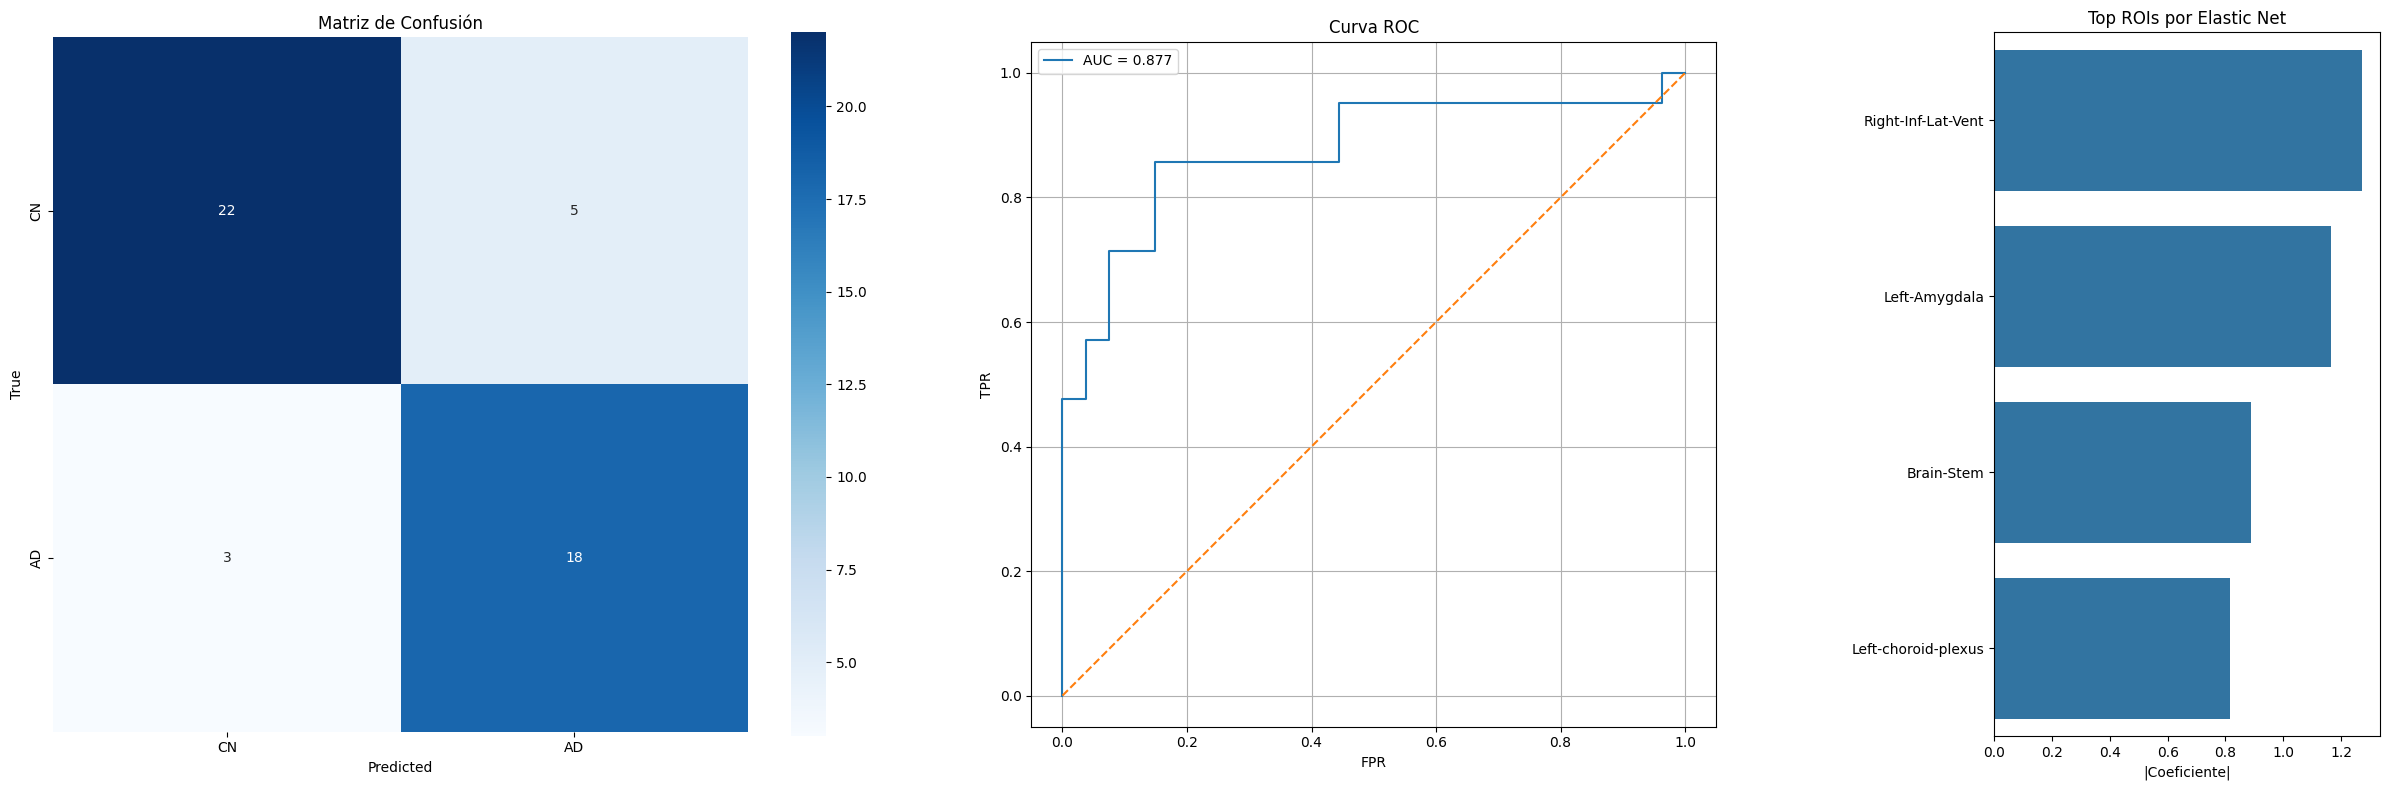


Las 4 ROIs seleccionadas son:
['Brain-Stem', 'Left-Amygdala', 'Left-choroid-plexus', 'Right-Inf-Lat-Vent']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,Right-Inf-Lat-Vent,1.2708
1,Left-Amygdala,-1.1639
2,Brain-Stem,-0.8874
3,Left-choroid-plexus,0.8139
4,Right-Hippocampus,-0.7383
5,Right-Amygdala,-0.6016
6,Right-choroid-plexus,-0.5876
7,Left-Hippocampus,-0.5389
8,Right-Lateral-Ventricle,-0.5241
9,Right-Pallidum,0.4843


In [77]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")


# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.35, 1.065, 0.6]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.035,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# RFE

# LOGISTIC REGRESSION

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores parámetros encontrados:
{'logreg__C': 0.01, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 17}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.8163
1,F1-score (validación),0.8475
2,ROC-AUC (test),0.9224
3,ROC-AUC (validación),0.8993
4,Balanced Accuracy (test),0.8280
5,Balanced Accuracy (validación),0.8594
6,Precision (test),0.7143
7,Precision (validación),0.8340
8,Recall (Sensitivity) (test),0.9524
9,Recall (Sensitivity) (validación),0.8712


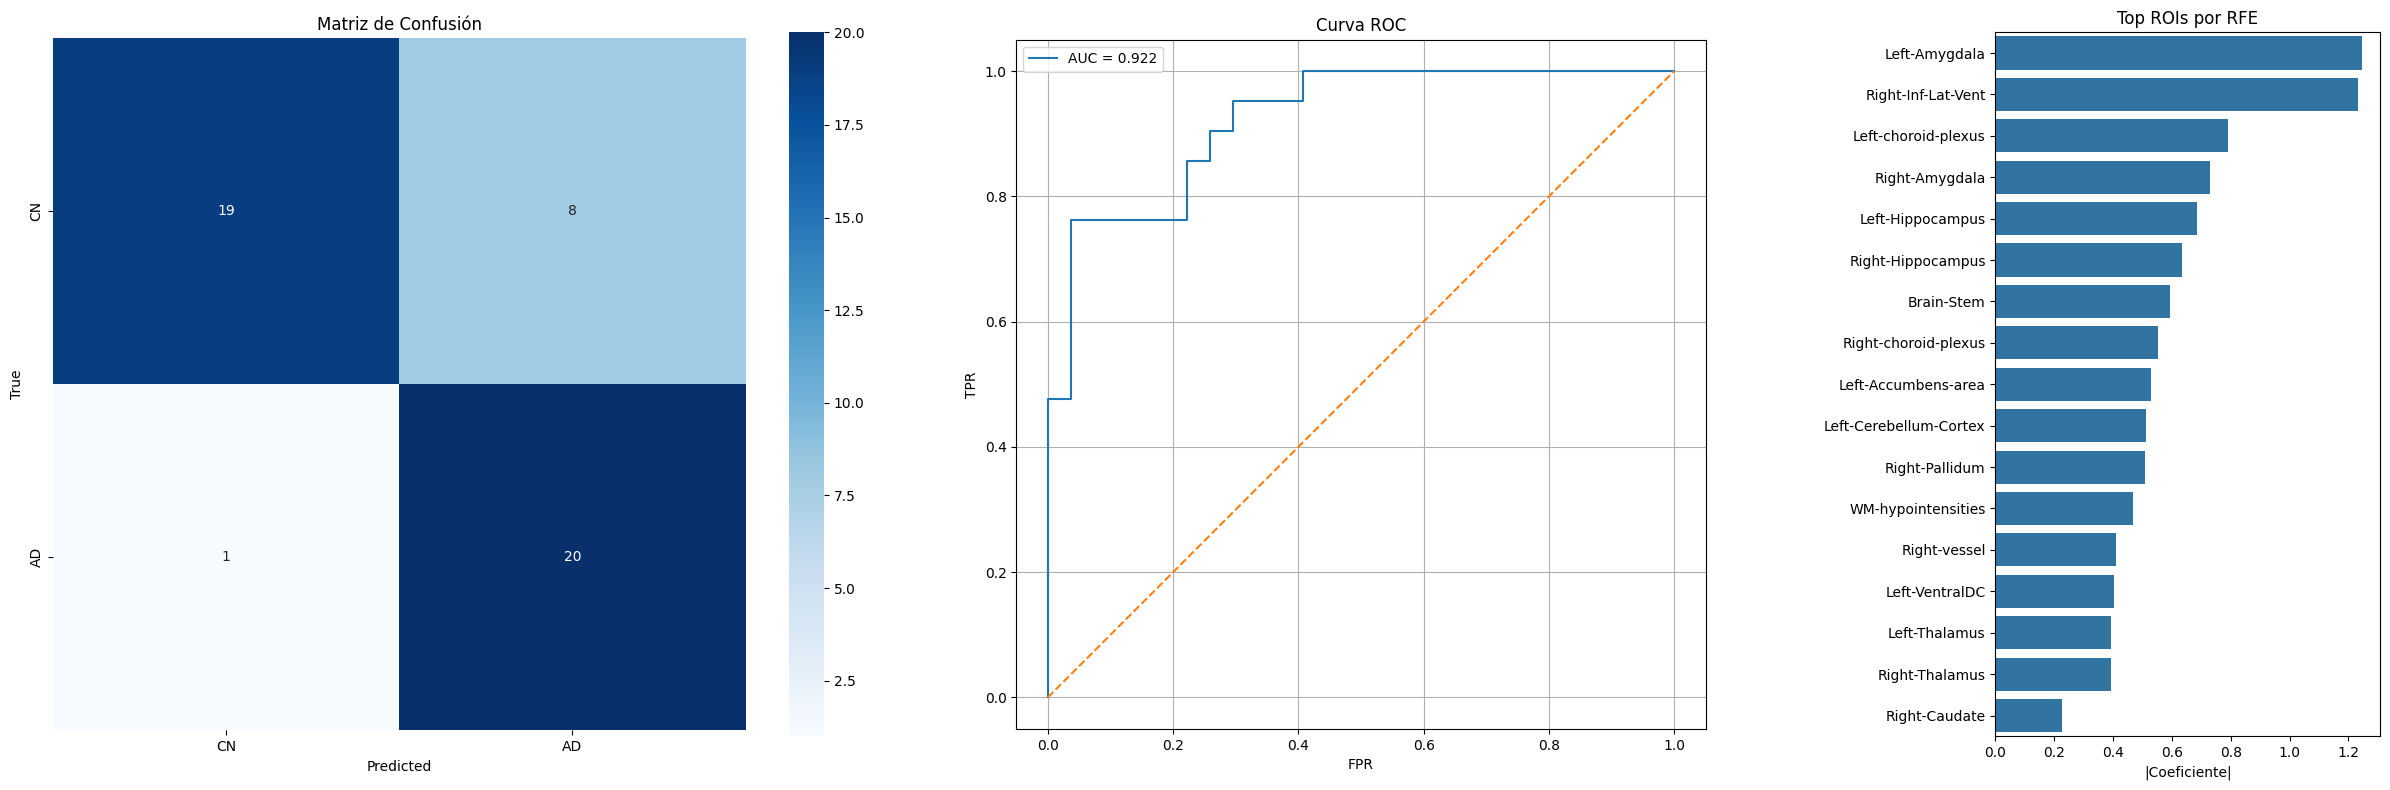


Las 17 ROIs seleccionadas por RFE son:
['Left-Cerebellum-Cortex', 'Left-Thalamus', 'Brain-Stem', 'Left-Hippocampus', 'Left-Amygdala', 'Left-Accumbens-area', 'Left-VentralDC', 'Left-choroid-plexus', 'Right-Inf-Lat-Vent', 'Right-Thalamus', 'Right-Caudate', 'Right-Pallidum', 'Right-Hippocampus', 'Right-Amygdala', 'Right-vessel', 'Right-choroid-plexus', 'WM-hypointensities']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,Left-Amygdala,-1.2453
1,Right-Inf-Lat-Vent,1.2337
2,Left-choroid-plexus,0.7892
3,Right-Amygdala,-0.7294
4,Left-Hippocampus,-0.6867
5,Right-Hippocampus,-0.6341
6,Brain-Stem,-0.5941
7,Right-choroid-plexus,-0.5514
8,Left-Accumbens-area,0.5303
9,Left-Cerebellum-Cortex,0.5112


In [89]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística y balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('logreg', LogisticRegression(max_iter = 10000, random_state=34, class_weight='balanced'))  # Logistic Regression con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0],          # L2
        'logreg__C': [0.01,0.1,1,10]    # Regularización
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.35, 1.075, 0.6]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Mejores parámetros encontrados:
{'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 2, 'svm__C': 10, 'svm__gamma': 1, 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.7826
1,F1-score (validación),0.8536
2,ROC-AUC (test),0.8924
3,ROC-AUC (validación),0.8911
4,Balanced Accuracy (test),0.7989
5,Balanced Accuracy (validación),0.8684
6,Precision (test),0.7200
7,Precision (validación),0.9025
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8131


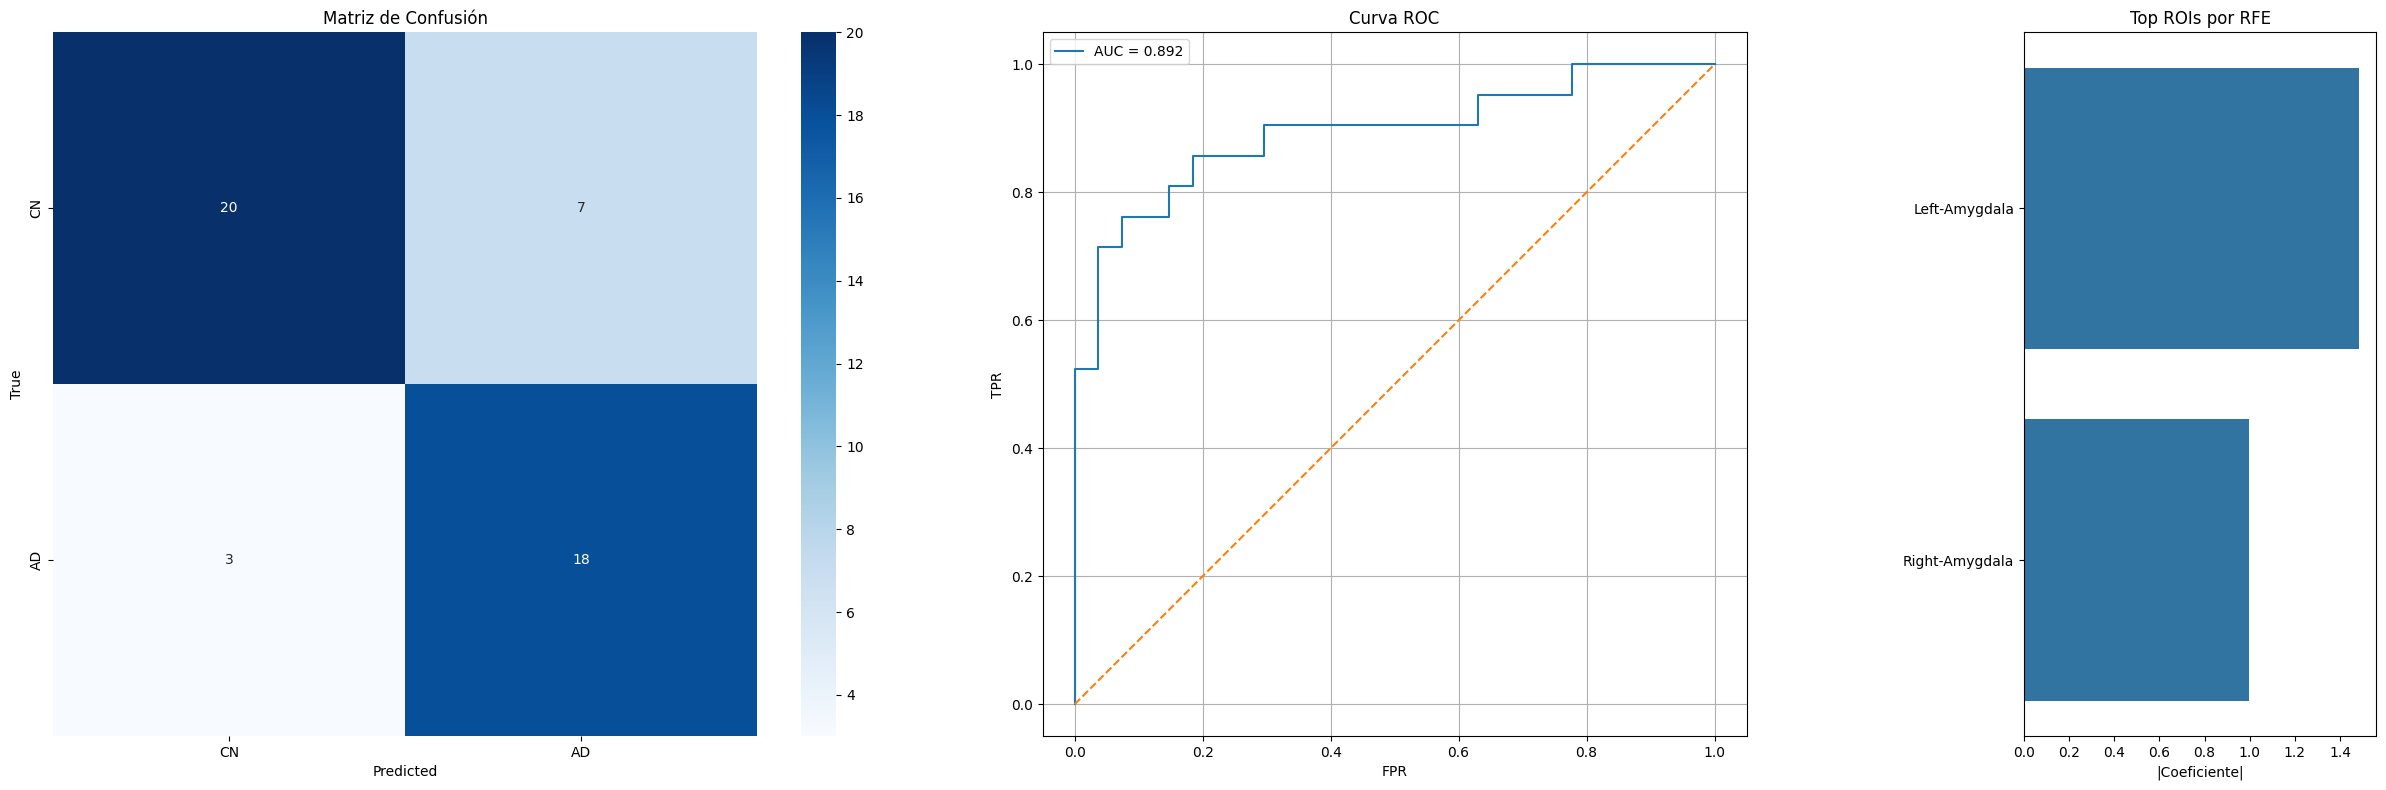


Las 2 ROIs seleccionadas por RFE son:
['Left-Amygdala', 'Right-Amygdala']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,Left-Amygdala,-1.4854
1,Right-Amygdala,-0.9954
2,Left-Lateral-Ventricle,0.0000
3,Left-Cerebellum-Cortex,0.0000
4,Left-Thalamus,0.0000
5,Left-Inf-Lat-Vent,0.0000
6,Left-Cerebellum-White-Matter,0.0000
7,Left-Putamen,0.0000
8,Left-Caudate,0.0000
9,4th-Ventricle,0.0000


In [95]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('svm',SVC(probability=True, random_state=34, class_weight='balanced'))  # SVM con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + SVM
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'svm__C': [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svm__kernel': ['linear', 'rbf']
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.035,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Mejores parámetros encontrados:
{'rf__max_depth': 2, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 50, 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 11}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.7660
1,F1-score (validación),0.8636
2,ROC-AUC (test),0.9189
3,ROC-AUC (validación),0.9081
4,Balanced Accuracy (test),0.7804
5,Balanced Accuracy (validación),0.8769
6,Precision (test),0.6923
7,Precision (validación),0.8797
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8490


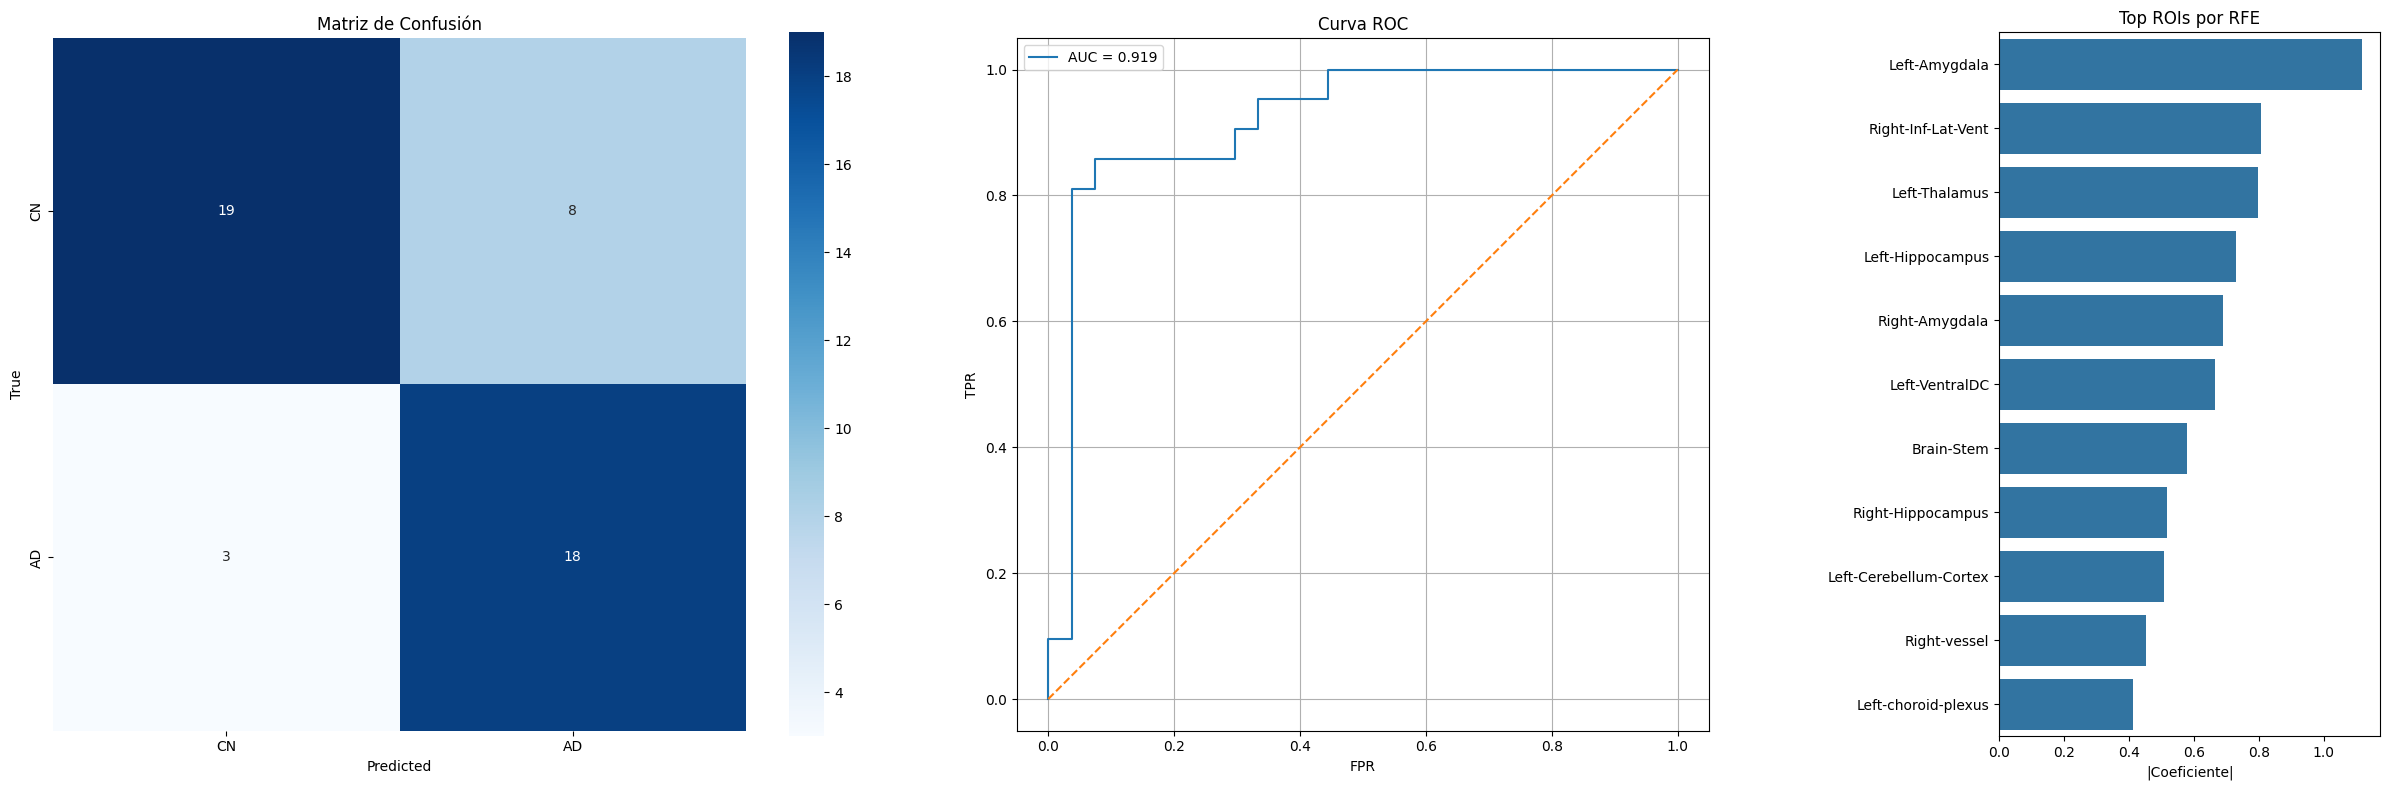


Las 11 ROIs seleccionadas por RFE son:
['Left-Cerebellum-Cortex', 'Left-Thalamus', 'Brain-Stem', 'Left-Hippocampus', 'Left-Amygdala', 'Left-VentralDC', 'Left-choroid-plexus', 'Right-Inf-Lat-Vent', 'Right-Hippocampus', 'Right-Amygdala', 'Right-vessel']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,Left-Amygdala,-1.1179
1,Right-Inf-Lat-Vent,0.8067
2,Left-Thalamus,0.7982
3,Left-Hippocampus,-0.7294
4,Right-Amygdala,-0.6895
5,Left-VentralDC,0.6639
6,Brain-Stem,-0.5775
7,Right-Hippocampus,-0.5165
8,Left-Cerebellum-Cortex,0.5072
9,Right-vessel,0.4517


In [99]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced'))  # Random Forest con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + Random Forest
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [2, 3, 5],
        'rf__min_samples_split': [5, 10],
        'rf__min_samples_leaf': [2, 4]
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.55]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# PCA

# LOGISTIC REGRESSION

Fitting 5 folds for each of 156 candidates, totalling 780 fits
Mejores parámetros encontrados:
{'logreg__C': 0.01, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'pca__n_components': 10}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8085
1,F1-score (validación),0.8367
2,ROC-AUC (test),0.9083
3,ROC-AUC (validación),0.8843
4,Balanced Accuracy (test),0.8228
5,Balanced Accuracy (validación),0.8486
6,Precision (test),0.7308
7,Precision (validación),0.8255
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8497


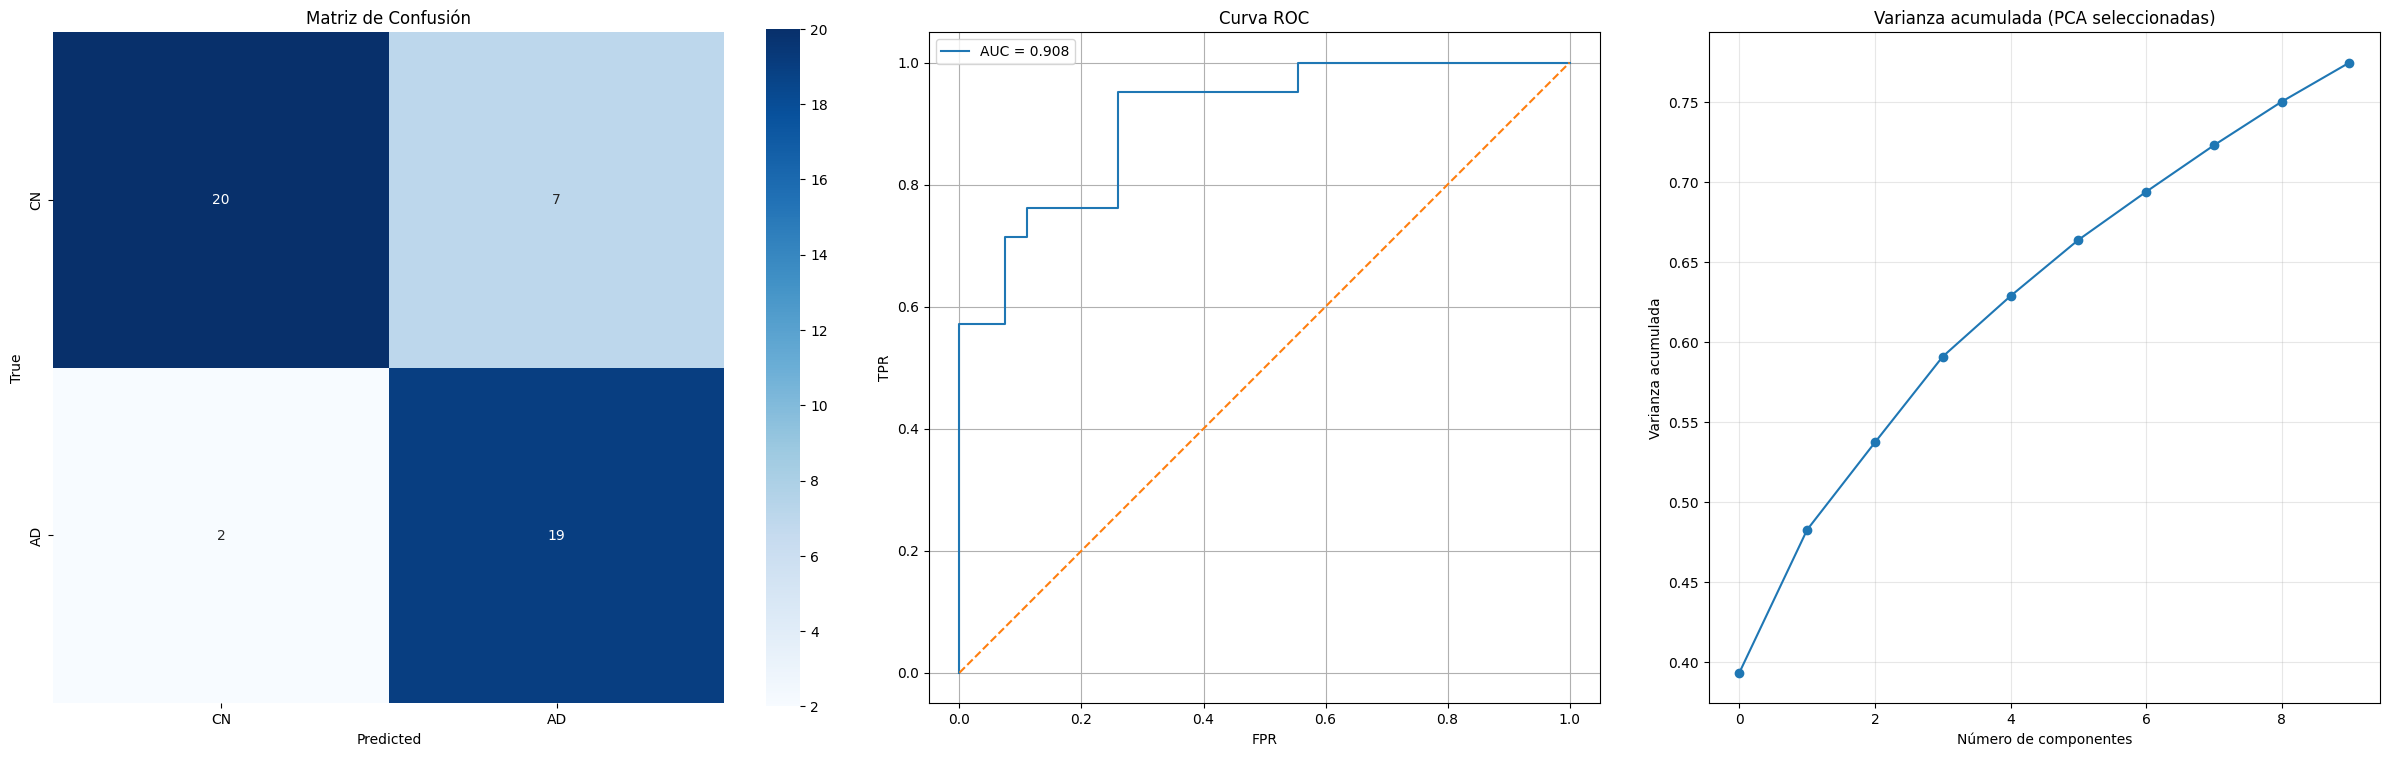


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,39.3250
1,PC2,8.9434
2,PC3,5.4632
3,PC4,5.3712
4,PC5,3.7868
5,PC6,3.5104
6,PC7,3.0120
7,PC8,2.9087
8,PC9,2.7293
9,PC10,2.4478


In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('logreg', LogisticRegression(max_iter=10000, class_weight='balanced',  random_state=34)) # Logistic Regression con balanceo de clases desiguales
])

param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'logreg__C': [0.01, 0.1, 1, 10],         # Regularización de la regresión logística
    'logreg__l1_ratio': [0],   
    'logreg__solver': ['saga']  # Solvers permitidos para la configuración
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# SVM

Fitting 5 folds for each of 1560 candidates, totalling 7800 fits
Mejores parámetros encontrados:
{'pca__n_components': 25, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.7907
1,F1-score (validación),0.8352
2,ROC-AUC (test),0.8907
3,ROC-AUC (validación),0.9189
4,Balanced Accuracy (test),0.8122
5,Balanced Accuracy (validación),0.8505
6,Precision (test),0.7727
7,Precision (validación),0.8487
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.8248


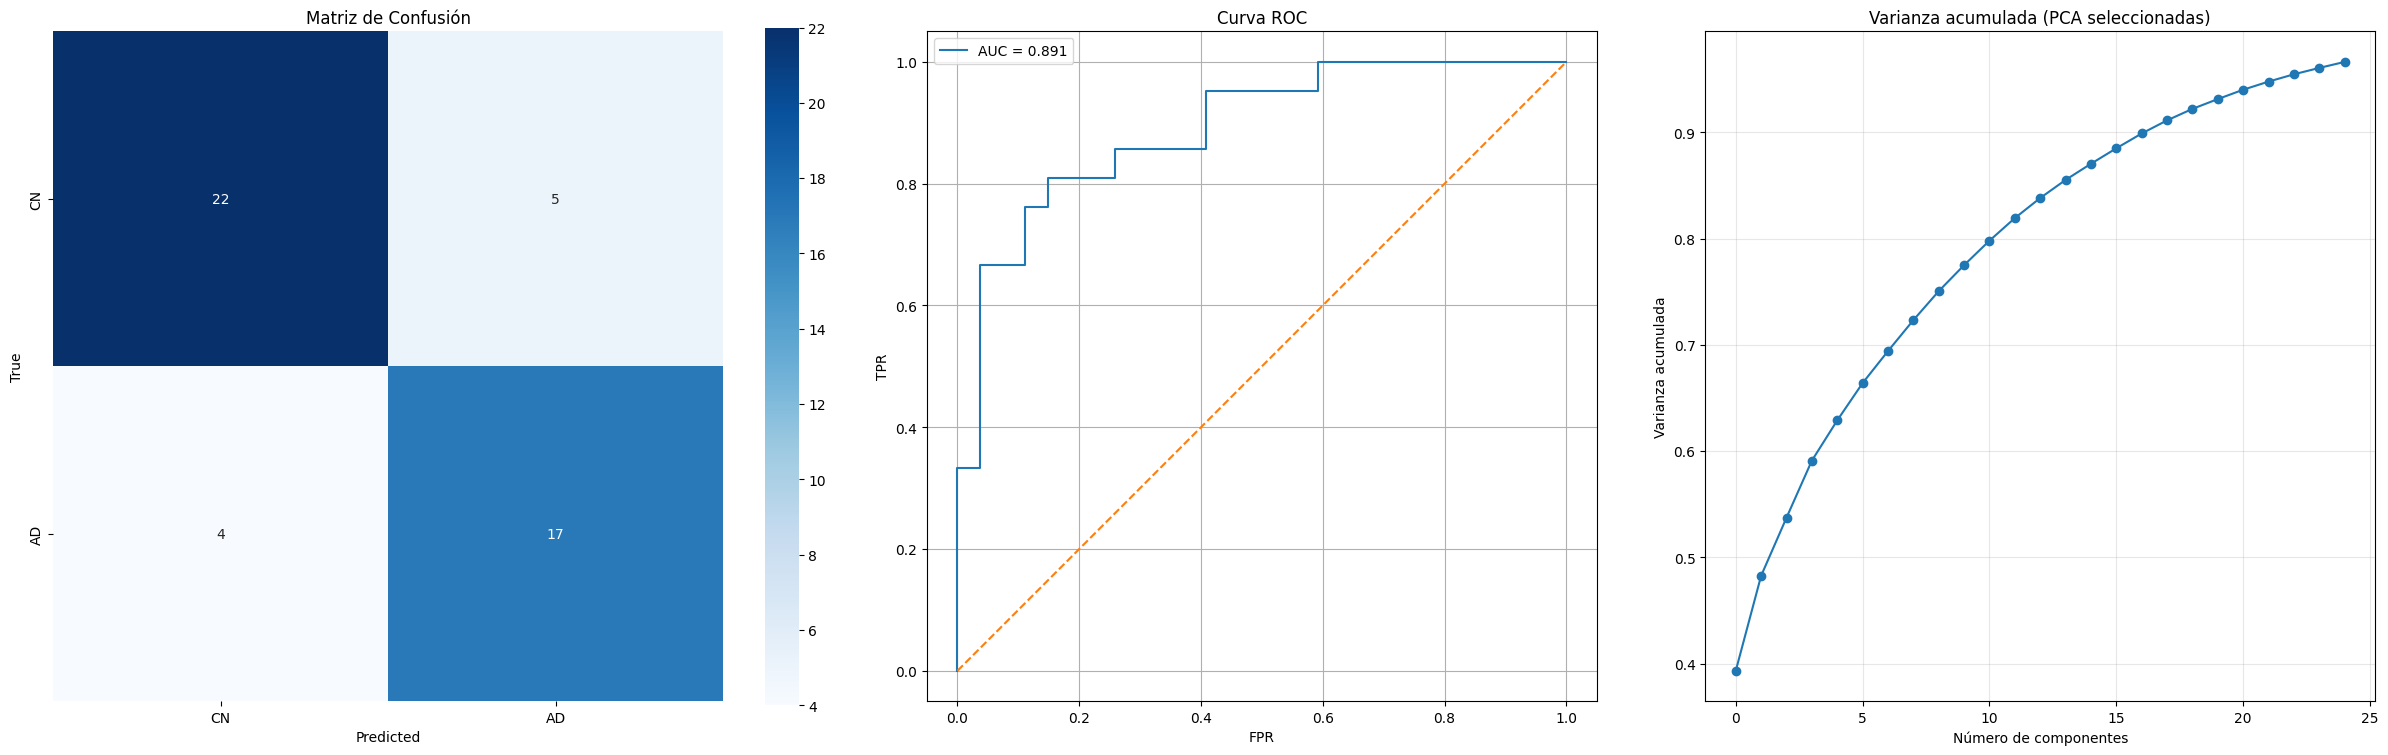


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,39.3250
1,PC2,8.9434
2,PC3,5.4632
3,PC4,5.3712
4,PC5,3.7868
5,PC6,3.5104
6,PC7,3.0120
7,PC8,2.9087
8,PC9,2.7293
9,PC10,2.4478


In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('svm', SVC(probability=True, class_weight='balanced', random_state=34)) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# Random Forest

Fitting 5 folds for each of 1404 candidates, totalling 7020 fits
Mejores parámetros encontrados:
{'pca__n_components': 4, 'rf__max_depth': 5, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.7727
1,F1-score (validación),0.8062
2,ROC-AUC (test),0.8395
3,ROC-AUC (validación),0.8788
4,Balanced Accuracy (test),0.7937
5,Balanced Accuracy (validación),0.8186
6,Precision (test),0.7391
7,Precision (validación),0.7862
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.8373


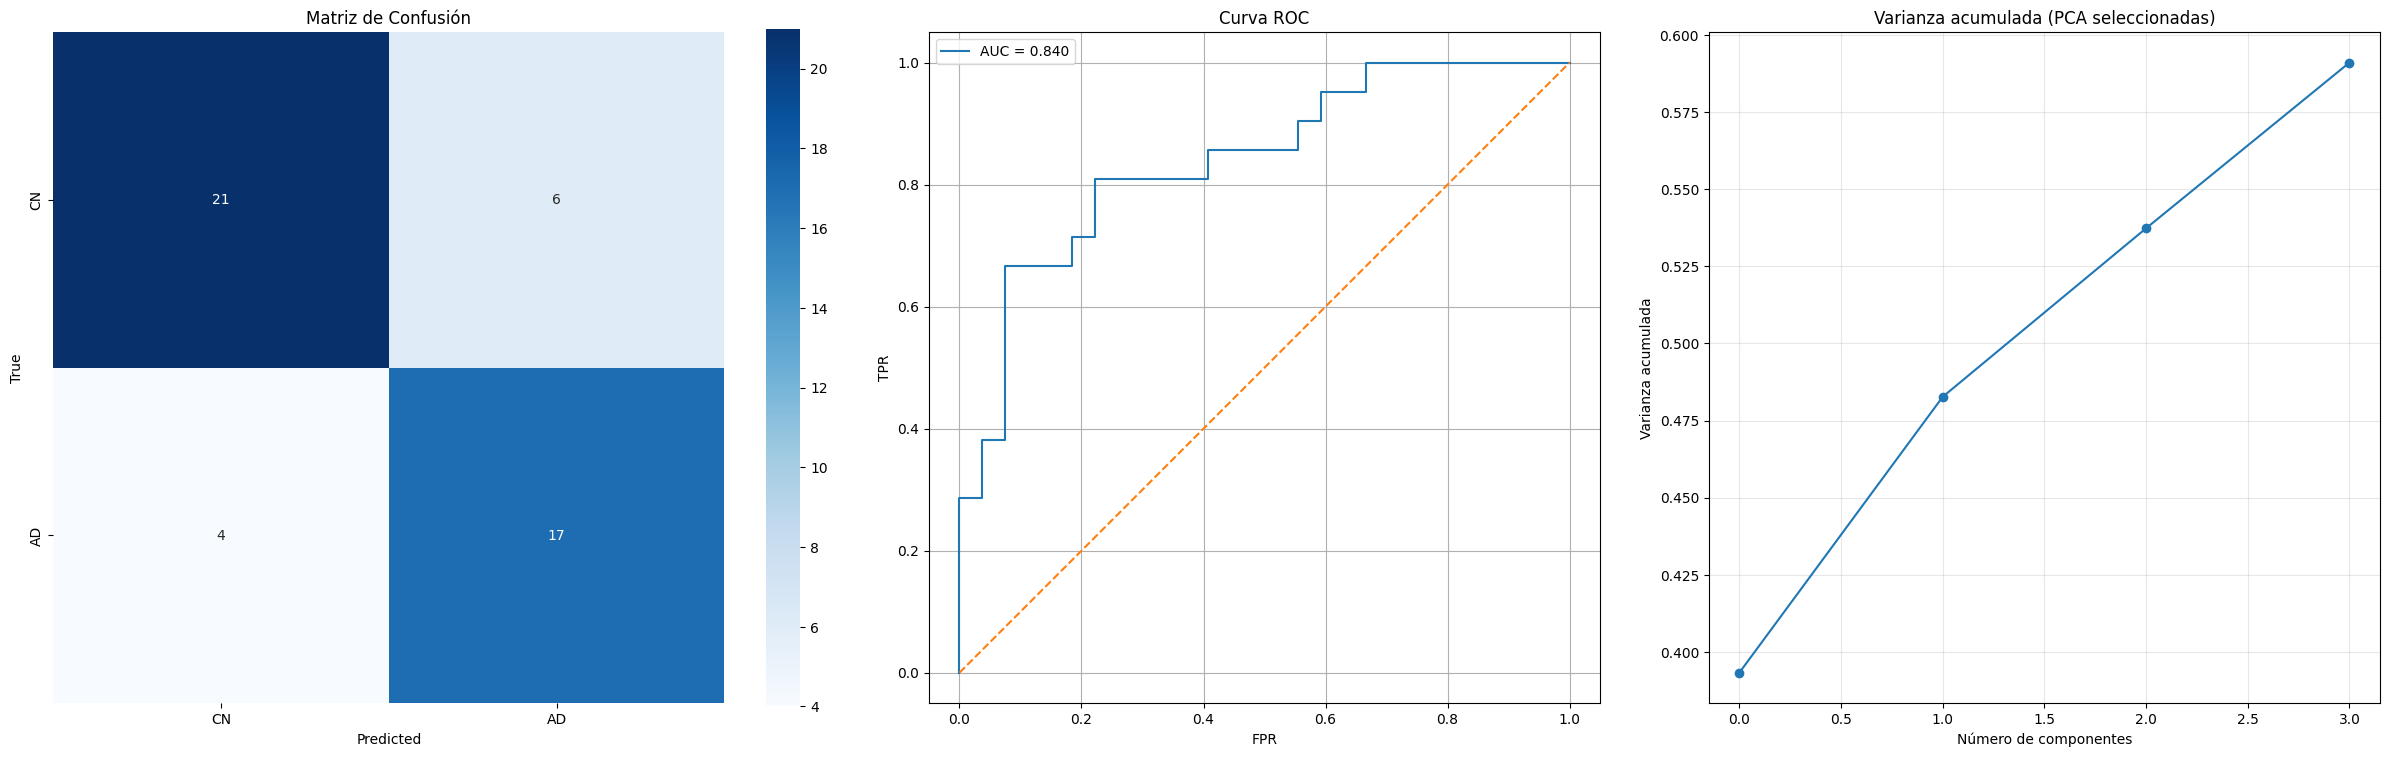


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,39.3250
1,PC2,8.9434
2,PC3,5.4632
3,PC4,5.3712
4,PC5,3.7868
5,PC6,3.5104
6,PC7,3.0120
7,PC8,2.9087
8,PC9,2.7293
9,PC10,2.4478


In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}


# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# volumnes_y_grosores_corticales

# ELASTIC NET

# LOGISTIC REGRESSION

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parámetros encontrados:
{'logreg__C': 1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 4}

===== RESUMEN DE MÉTRICAS =====


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,Value
0,F1-score (test),0.8636
1,F1-score (validación),0.8799
2,ROC-AUC (test),0.9453
3,ROC-AUC (validación),0.9322
4,Balanced Accuracy (test),0.8783
5,Balanced Accuracy (validación),0.8912
6,Precision (test),0.8261
7,Precision (validación),0.9186
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8490


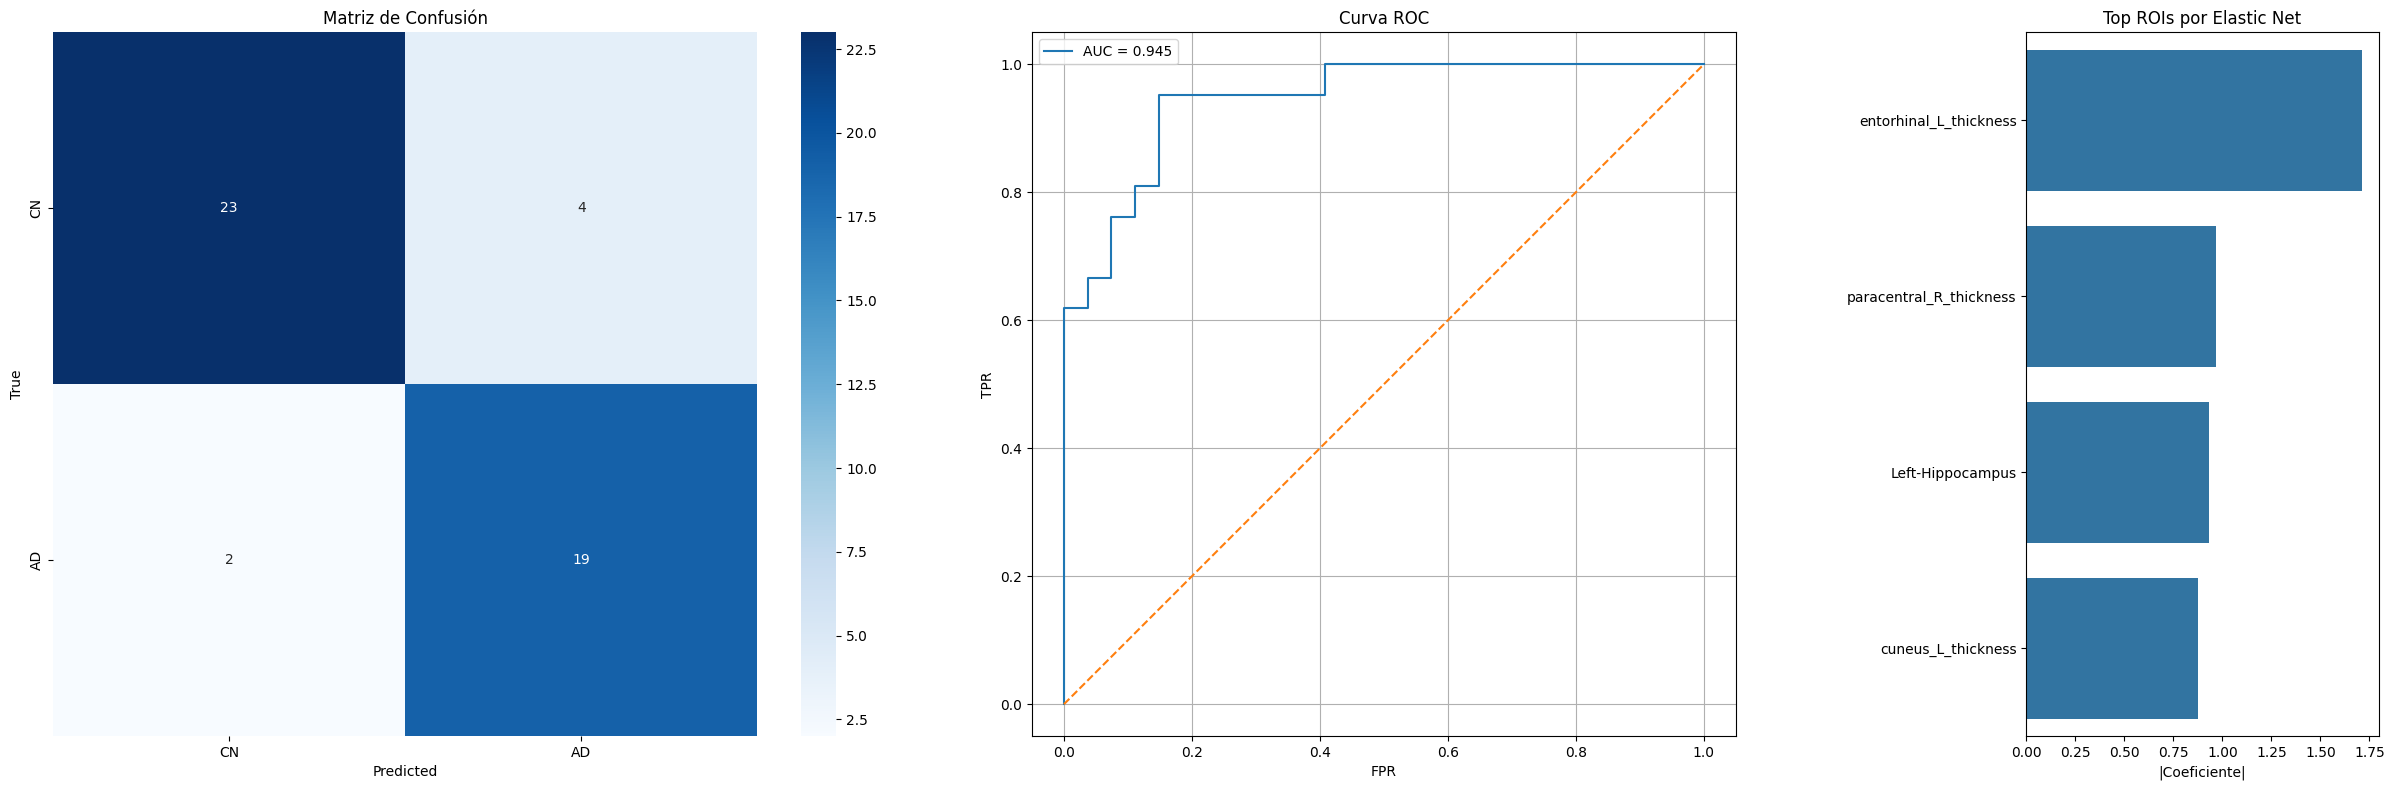


Las 4 ROIs seleccionadas son:
['Left-Hippocampus', 'cuneus_L_thickness', 'entorhinal_L_thickness', 'paracentral_R_thickness']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.7123
1,paracentral_R_thickness,-0.9677
2,Left-Hippocampus,-0.9338
3,cuneus_L_thickness,0.8747
4,Right-Hippocampus,-0.8032
5,3rd-Ventricle,0.7923
6,frontalpole_R_thickness,0.7474
7,lateralorbitofrontal_R_thickness,-0.7161
8,postcentral_L_thickness,0.6742
9,Brain-Stem,-0.6410


In [106]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Logistic Rgression final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('logreg', LogisticRegression(max_iter=10000, random_state=34, class_weight='balanced'))
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__l1_ratio': [0],
    'logreg__solver': ['saga']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 7, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.8889
1,F1-score (validación),0.8929
2,ROC-AUC (test),0.9577
3,ROC-AUC (validación),0.9388
4,Balanced Accuracy (test),0.9021
5,Balanced Accuracy (validación),0.9029
6,Precision (test),0.8333
7,Precision (validación),0.9207
8,Recall (Sensitivity) (test),0.9524
9,Recall (Sensitivity) (validación),0.8725


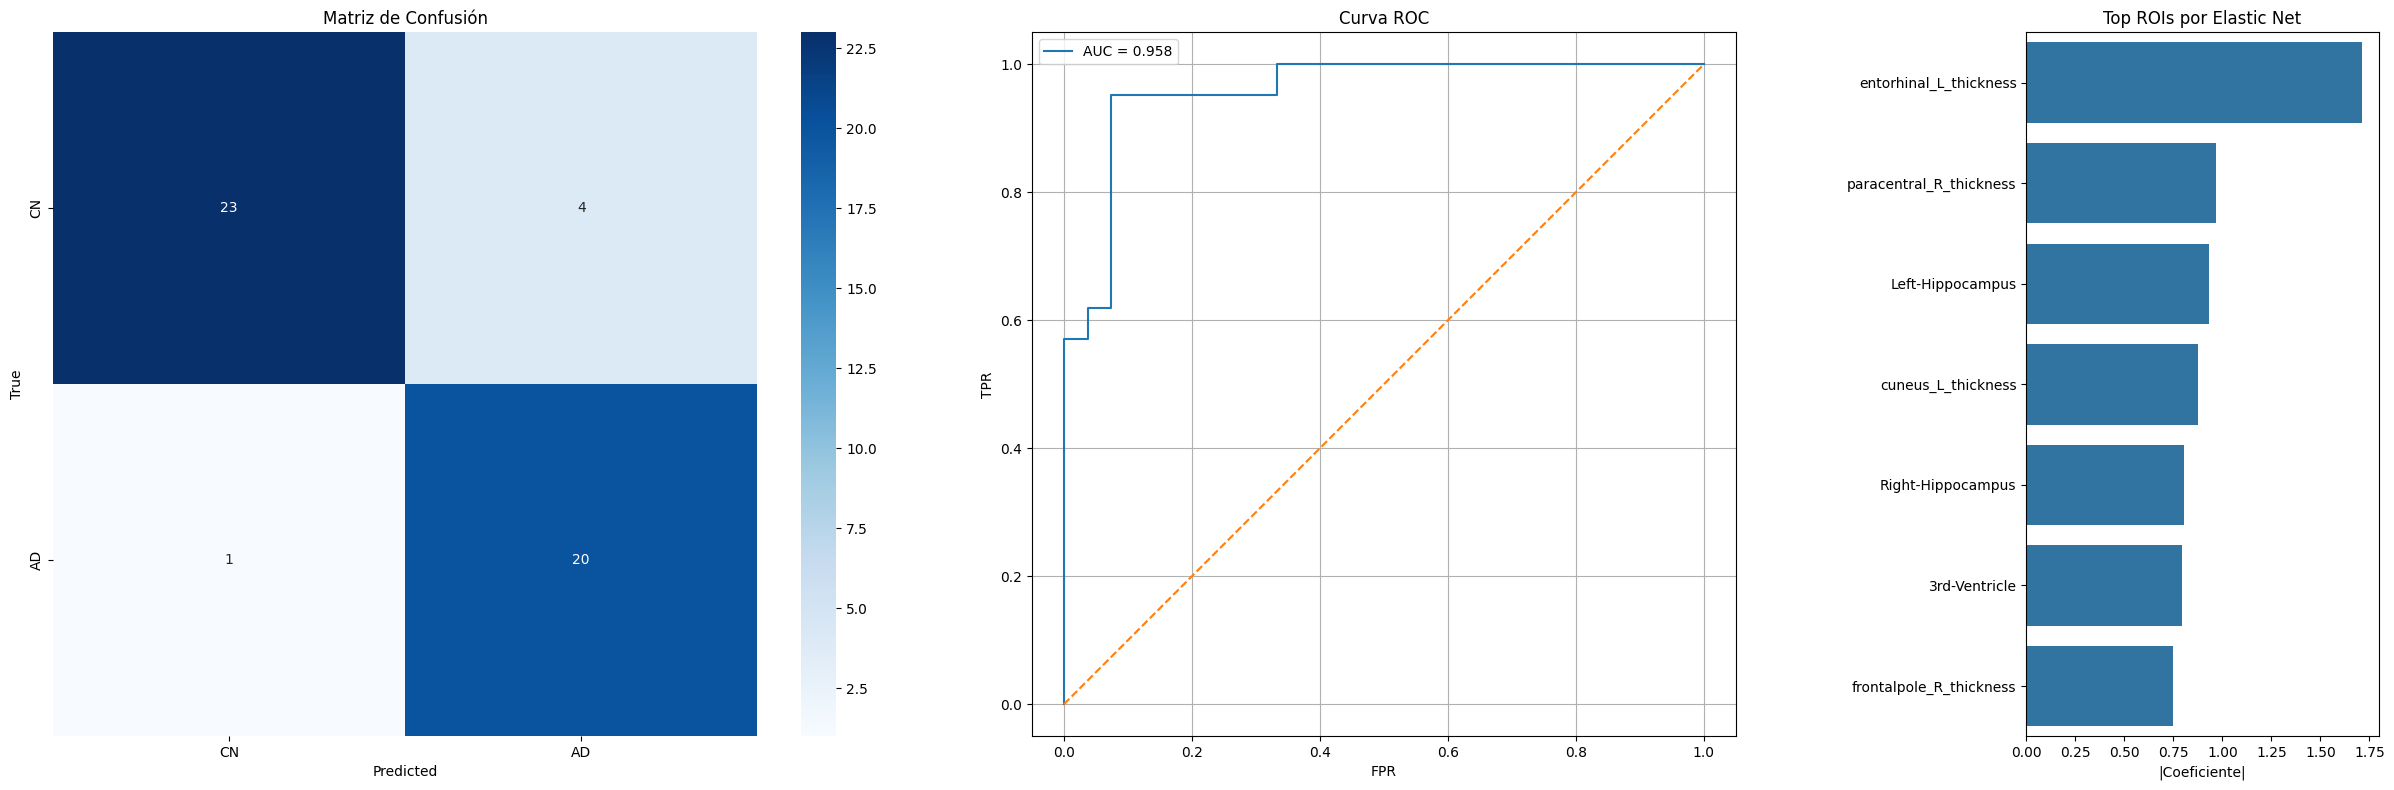


Las 7 ROIs seleccionadas son:
['3rd-Ventricle', 'Left-Hippocampus', 'Right-Hippocampus', 'cuneus_L_thickness', 'entorhinal_L_thickness', 'paracentral_R_thickness', 'frontalpole_R_thickness']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.7123
1,paracentral_R_thickness,-0.9677
2,Left-Hippocampus,-0.9338
3,cuneus_L_thickness,0.8747
4,Right-Hippocampus,-0.8032
5,3rd-Ventricle,0.7923
6,frontalpole_R_thickness,0.7474
7,lateralorbitofrontal_R_thickness,-0.7161
8,postcentral_L_thickness,0.6742
9,Brain-Stem,-0.6410


In [108]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight= 'balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> SVC final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('svm',  SVC(probability=True, random_state=34, class_weight= 'balanced')) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 100, 'selector__estimator__l1_ratio': 0.5, 'selector__max_features': 17}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9048
1,F1-score (validación),0.9044
2,ROC-AUC (test),0.9665
3,ROC-AUC (validación),0.9376
4,Balanced Accuracy (test),0.9153
5,Balanced Accuracy (validación),0.9136
6,Precision (test),0.9048
7,Precision (validación),0.9271
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8843


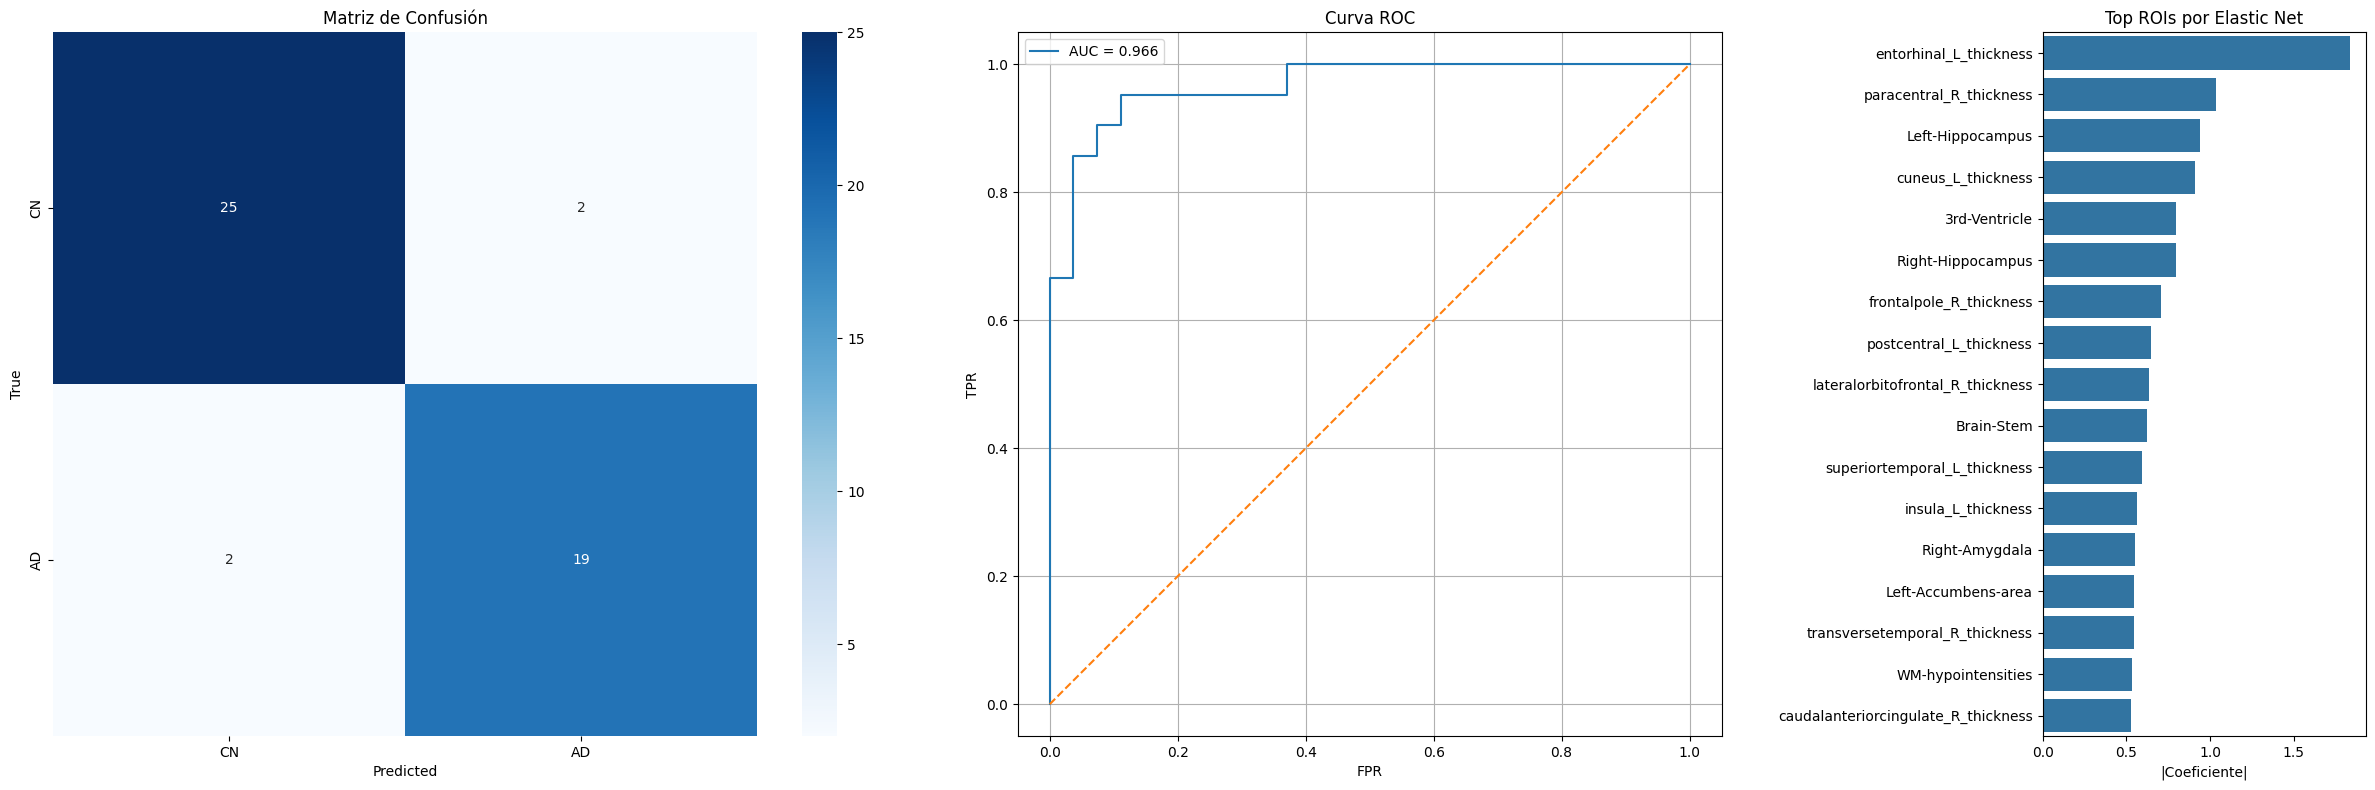


Las 17 ROIs seleccionadas son:
['3rd-Ventricle', 'Brain-Stem', 'Left-Hippocampus', 'Left-Accumbens-area', 'Right-Hippocampus', 'Right-Amygdala', 'WM-hypointensities', 'cuneus_L_thickness', 'entorhinal_L_thickness', 'postcentral_L_thickness', 'superiortemporal_L_thickness', 'insula_L_thickness', 'caudalanteriorcingulate_R_thickness', 'lateralorbitofrontal_R_thickness', 'paracentral_R_thickness', 'frontalpole_R_thickness', 'transversetemporal_R_thickness']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.8382
1,paracentral_R_thickness,-1.0362
2,Left-Hippocampus,-0.9383
3,cuneus_L_thickness,0.9093
4,3rd-Ventricle,0.7981
5,Right-Hippocampus,-0.7946
6,frontalpole_R_thickness,0.7076
7,postcentral_L_thickness,0.6457
8,lateralorbitofrontal_R_thickness,-0.6365
9,Brain-Stem,-0.6209


In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")


# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.45]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.05,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# RFE

# LOGISTIC REGRESSION

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores parámetros encontrados:
{'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 3}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.8889
1,F1-score (validación),0.8984
2,ROC-AUC (test),0.9436
3,ROC-AUC (validación),0.9365
4,Balanced Accuracy (test),0.9021
5,Balanced Accuracy (validación),0.9082
6,Precision (test),0.8333
7,Precision (validación),0.9190
8,Recall (Sensitivity) (test),0.9524
9,Recall (Sensitivity) (validación),0.8830


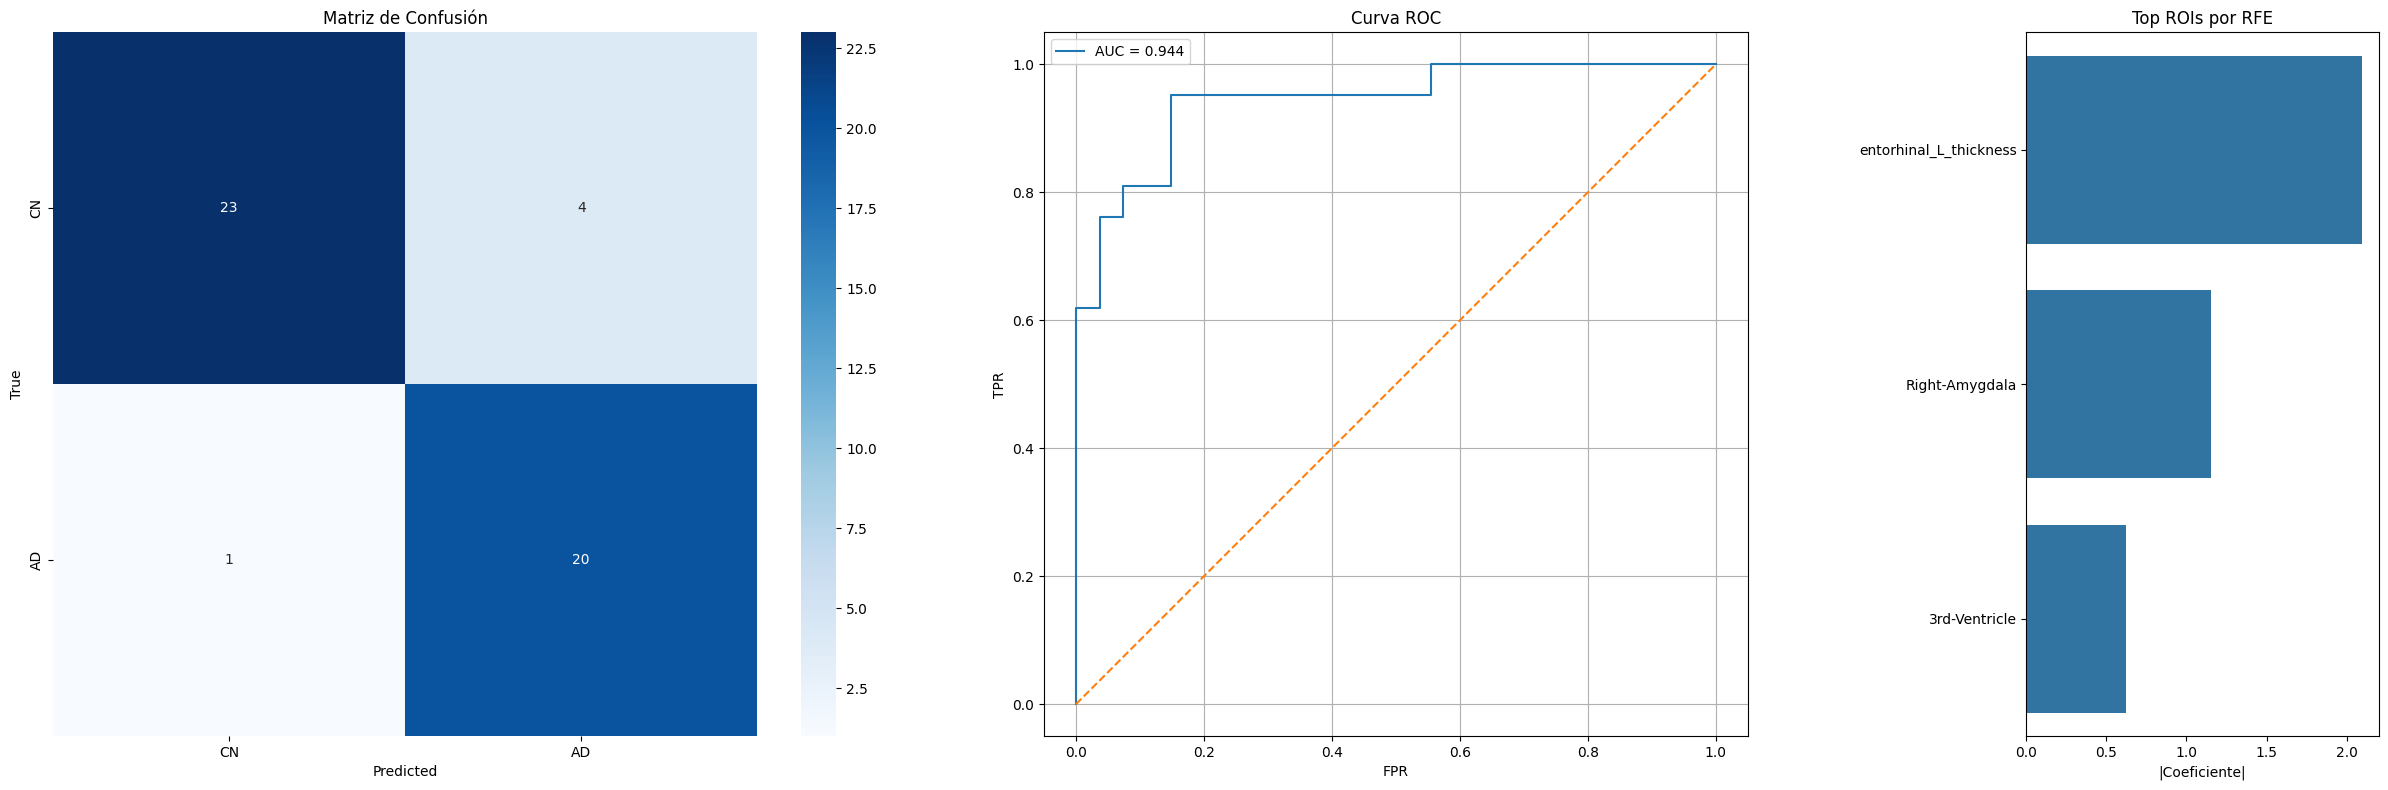


Las 3 ROIs seleccionadas por RFE son:
['3rd-Ventricle', 'Right-Amygdala', 'entorhinal_L_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.0960
1,Right-Amygdala,-1.1532
2,3rd-Ventricle,0.6228
3,Left-Cerebellum-White-Matter,0.0000
4,Left-Cerebellum-Cortex,0.0000
5,Left-Caudate,0.0000
6,Left-Thalamus,0.0000
7,Left-Putamen,0.0000
8,Left-Pallidum,0.0000
9,4th-Ventricle,0.0000


In [116]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística y balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('logreg', LogisticRegression(max_iter = 10000, random_state=34, class_weight='balanced'))  # Logistic Regression con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0],          # L2
        'logreg__C': [0.01,0.1,1,10]    # Regularización
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.035,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Mejores parámetros encontrados:
{'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 3, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.8636
1,F1-score (validación),0.8984
2,ROC-AUC (test),0.9444
3,ROC-AUC (validación),0.9359
4,Balanced Accuracy (test),0.8783
5,Balanced Accuracy (validación),0.9082
6,Precision (test),0.8261
7,Precision (validación),0.9190
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8830


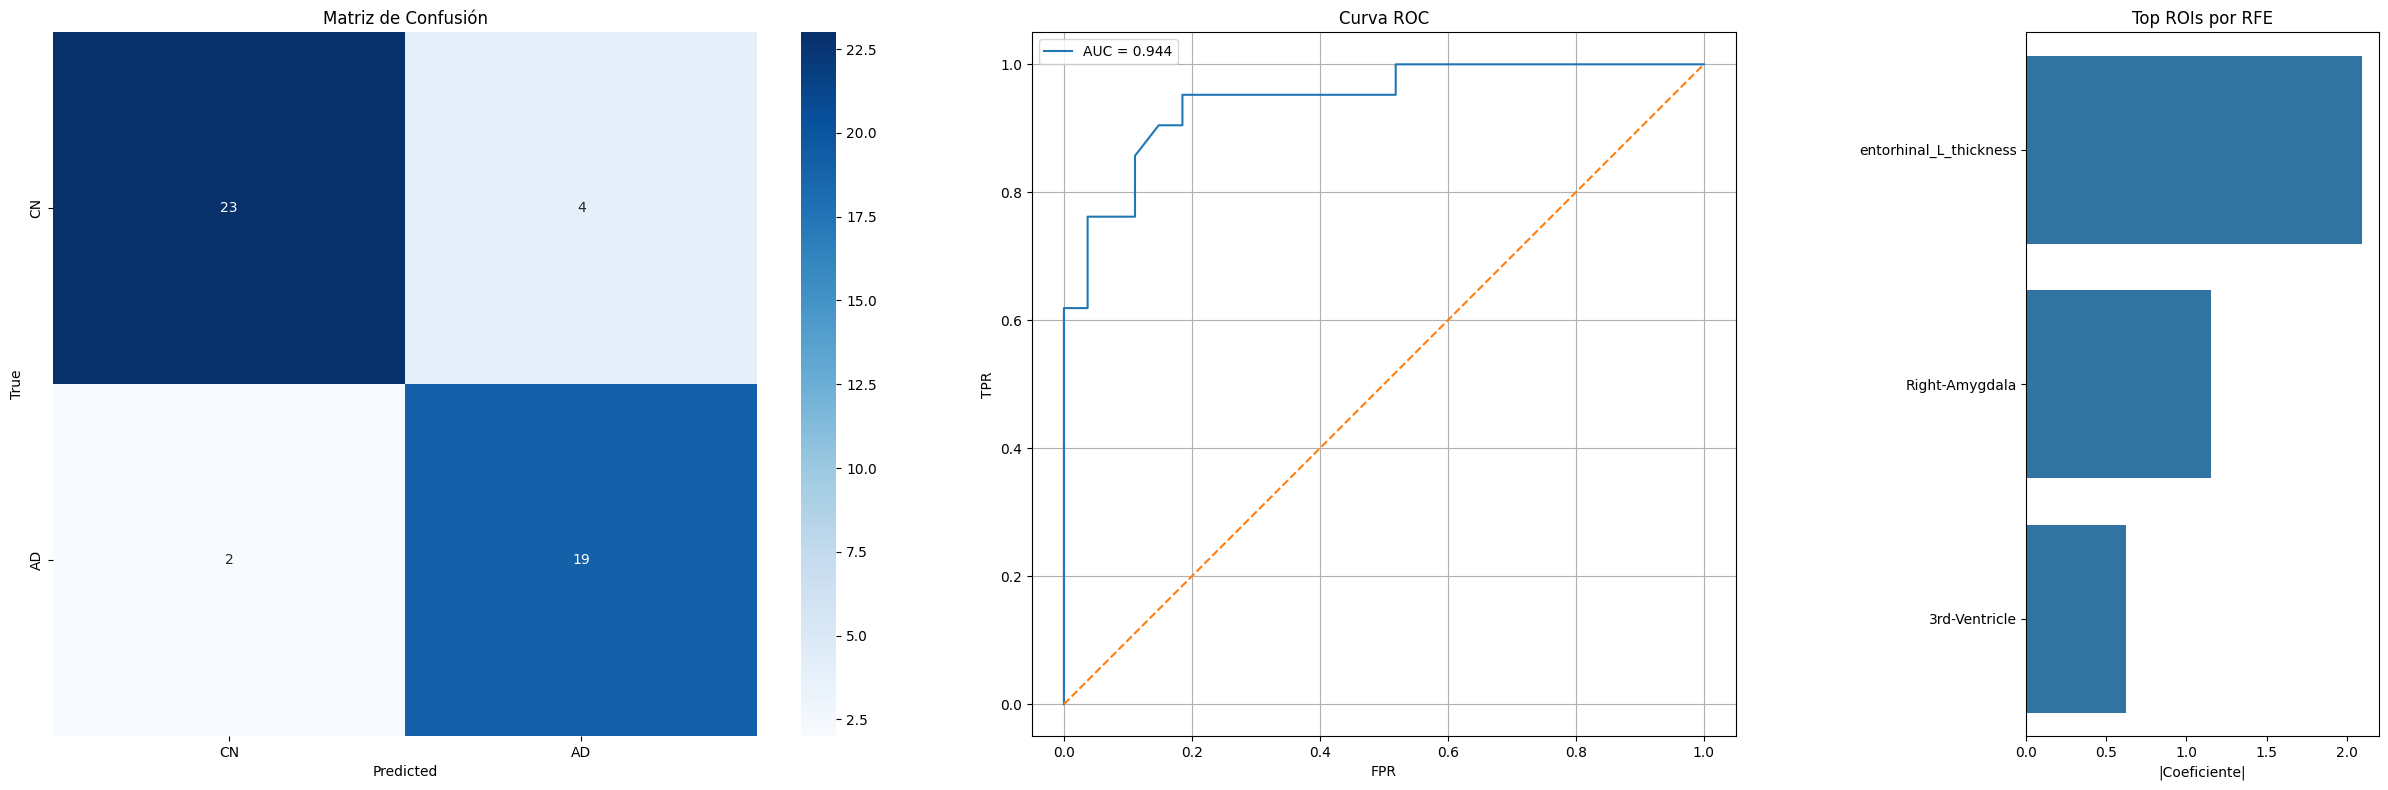


Las 3 ROIs seleccionadas por RFE son:
['3rd-Ventricle', 'Right-Amygdala', 'entorhinal_L_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.0960
1,Right-Amygdala,-1.1532
2,3rd-Ventricle,0.6228
3,Left-Cerebellum-White-Matter,0.0000
4,Left-Cerebellum-Cortex,0.0000
5,Left-Caudate,0.0000
6,Left-Thalamus,0.0000
7,Left-Putamen,0.0000
8,Left-Pallidum,0.0000
9,4th-Ventricle,0.0000


In [119]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('svm',SVC(probability=True, random_state=34, class_weight='balanced'))  # SVM con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + SVM
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'svm__C': [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svm__kernel': ['linear', 'rbf']
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Mejores parámetros encontrados:
{'rf__max_depth': 3, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 100, 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 5}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9048
1,F1-score (validación),0.9096
2,ROC-AUC (test),0.9647
3,ROC-AUC (validación),0.9262
4,Balanced Accuracy (test),0.9153
5,Balanced Accuracy (validación),0.9180
6,Precision (test),0.9048
7,Precision (validación),0.9422
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8837


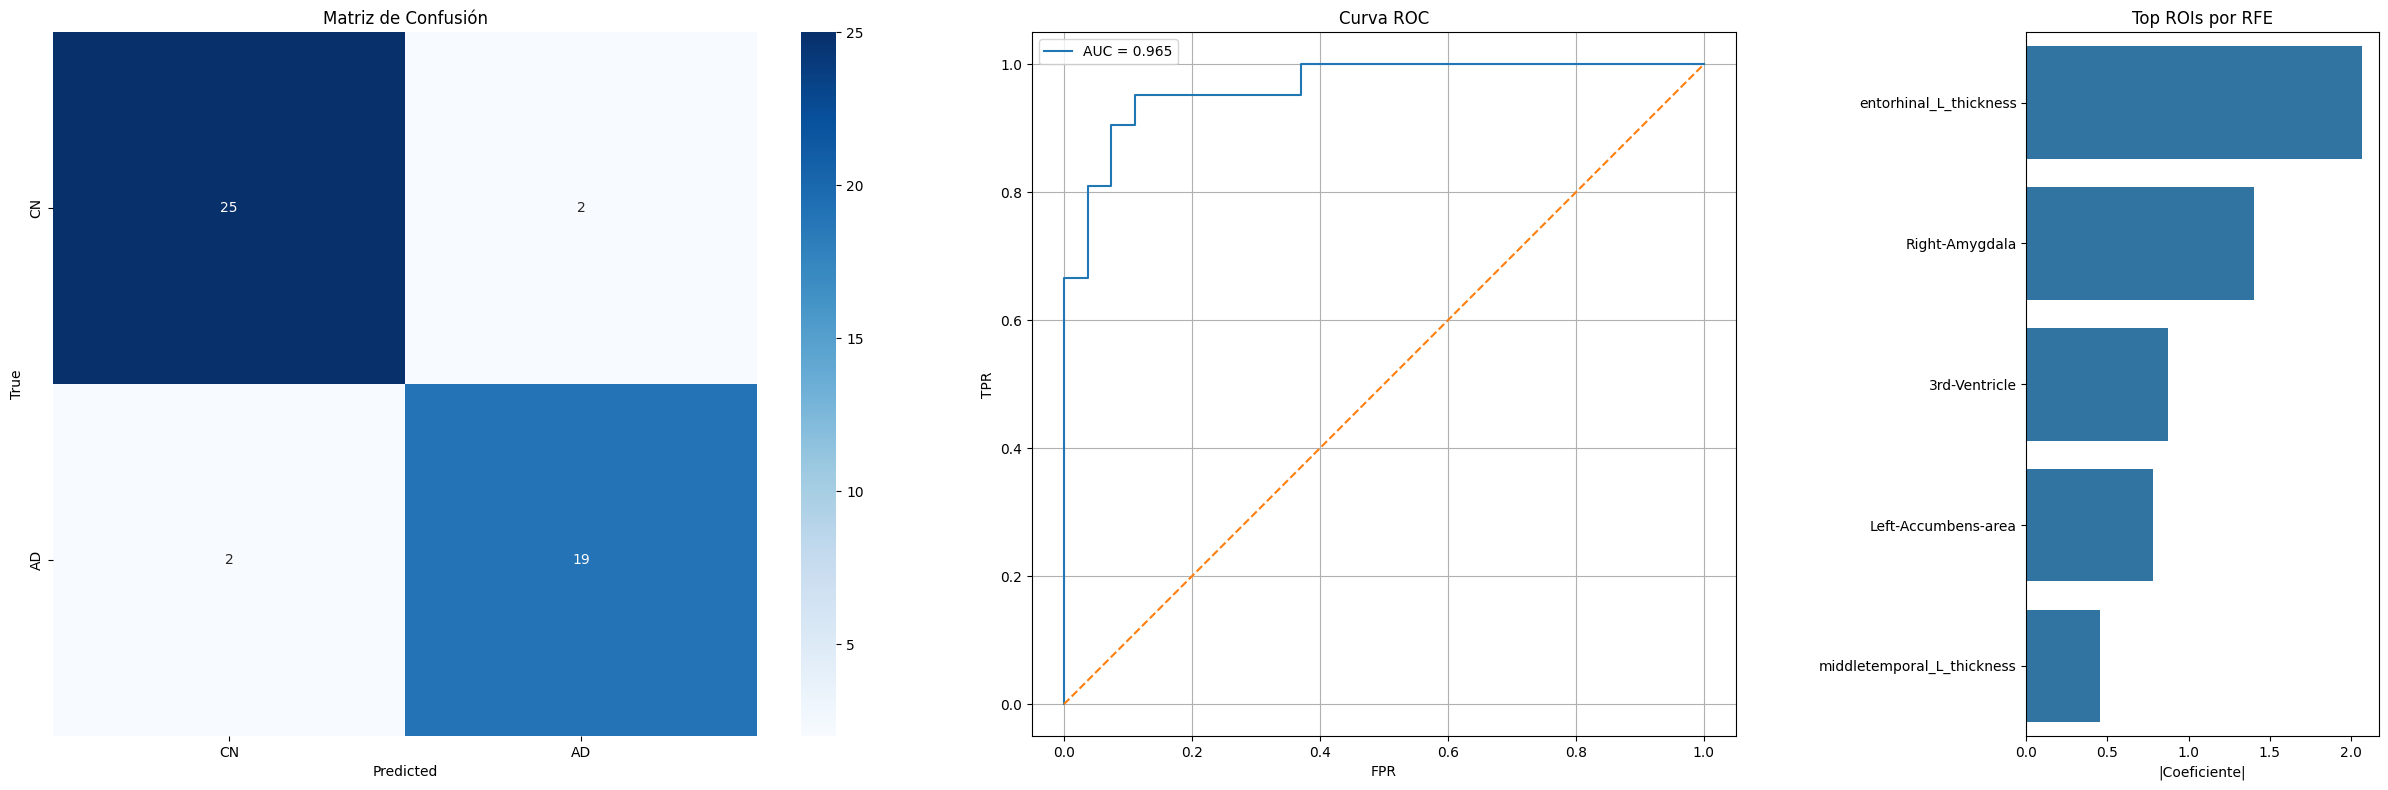


Las 5 ROIs seleccionadas por RFE son:
['3rd-Ventricle', 'Left-Accumbens-area', 'Right-Amygdala', 'entorhinal_L_thickness', 'middletemporal_L_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.0678
1,Right-Amygdala,-1.4028
2,3rd-Ventricle,0.8711
3,Left-Accumbens-area,0.7825
4,middletemporal_L_thickness,-0.4532
5,Left-Cerebellum-White-Matter,0.0000
6,Left-Cerebellum-Cortex,0.0000
7,Left-Putamen,0.0000
8,Left-Pallidum,0.0000
9,Left-Caudate,0.0000


In [121]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced'))  # Random Forest con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + Random Forest
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [2, 3, 5],
        'rf__min_samples_split': [5, 10],
        'rf__min_samples_leaf': [2, 4]
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# PCA

# LOGISTIC REGRESSION

Fitting 5 folds for each of 428 candidates, totalling 2140 fits
Mejores parámetros encontrados:
{'logreg__C': 0.01, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'pca__n_components': 18}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8837
1,F1-score (validación),0.8568
2,ROC-AUC (test),0.9312
3,ROC-AUC (validación),0.9193
4,Balanced Accuracy (test),0.8968
5,Balanced Accuracy (validación),0.8710
6,Precision (test),0.8636
7,Precision (validación),0.8832
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8373


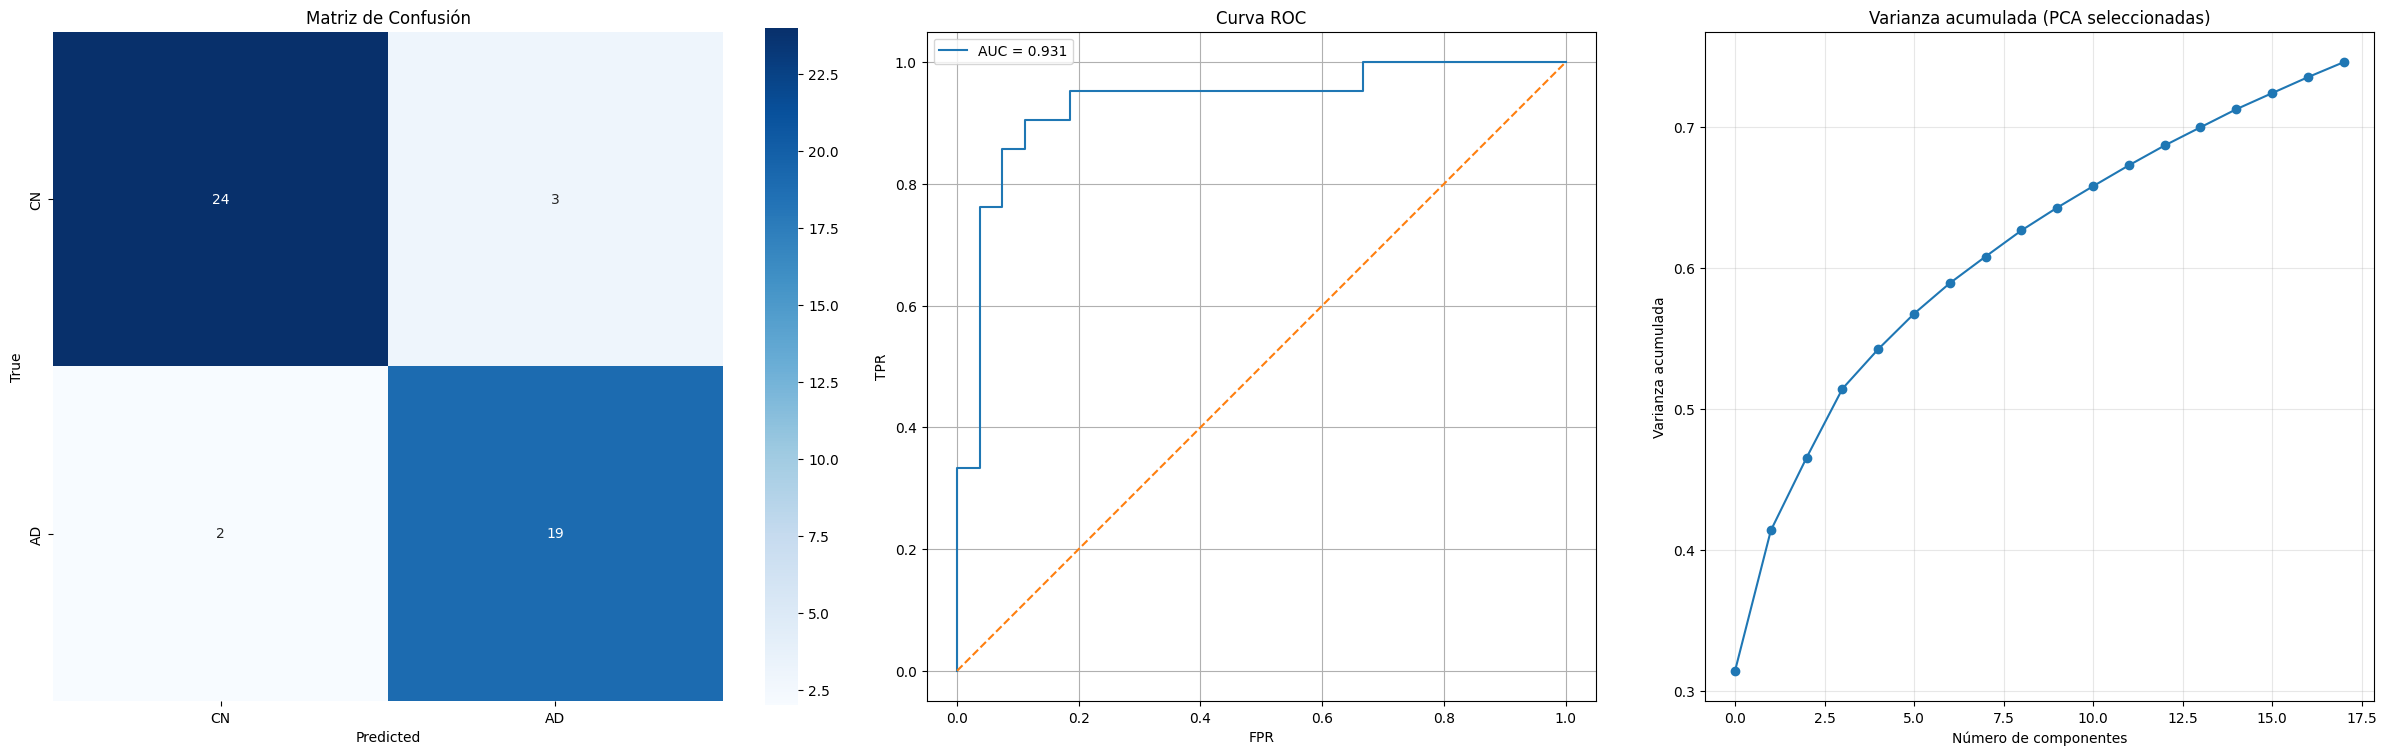


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,31.4359
1,PC2,9.9495
2,PC3,5.1699
3,PC4,4.8784
4,PC5,2.8060
5,PC6,2.5107
6,PC7,2.1681
7,PC8,1.8894
8,PC9,1.8479
9,PC10,1.6191


In [122]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('logreg', LogisticRegression(max_iter=10000, class_weight='balanced',  random_state=34)) # Logistic Regression con balanceo de clases desiguales
])

param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'logreg__C': [0.01, 0.1, 1, 10],         # Regularización de la regresión logística
    'logreg__l1_ratio': [0],   
    'logreg__solver': ['saga']  # Solvers permitidos para la configuración
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)


# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# SVM

Fitting 5 folds for each of 4280 candidates, totalling 21400 fits
Mejores parámetros encontrados:
{'pca__n_components': 92, 'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8182
1,F1-score (validación),0.8781
2,ROC-AUC (test),0.9453
3,ROC-AUC (validación),0.9305
4,Balanced Accuracy (test),0.8360
5,Balanced Accuracy (validación),0.8883
6,Precision (test),0.7826
7,Precision (validación),0.8853
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8719


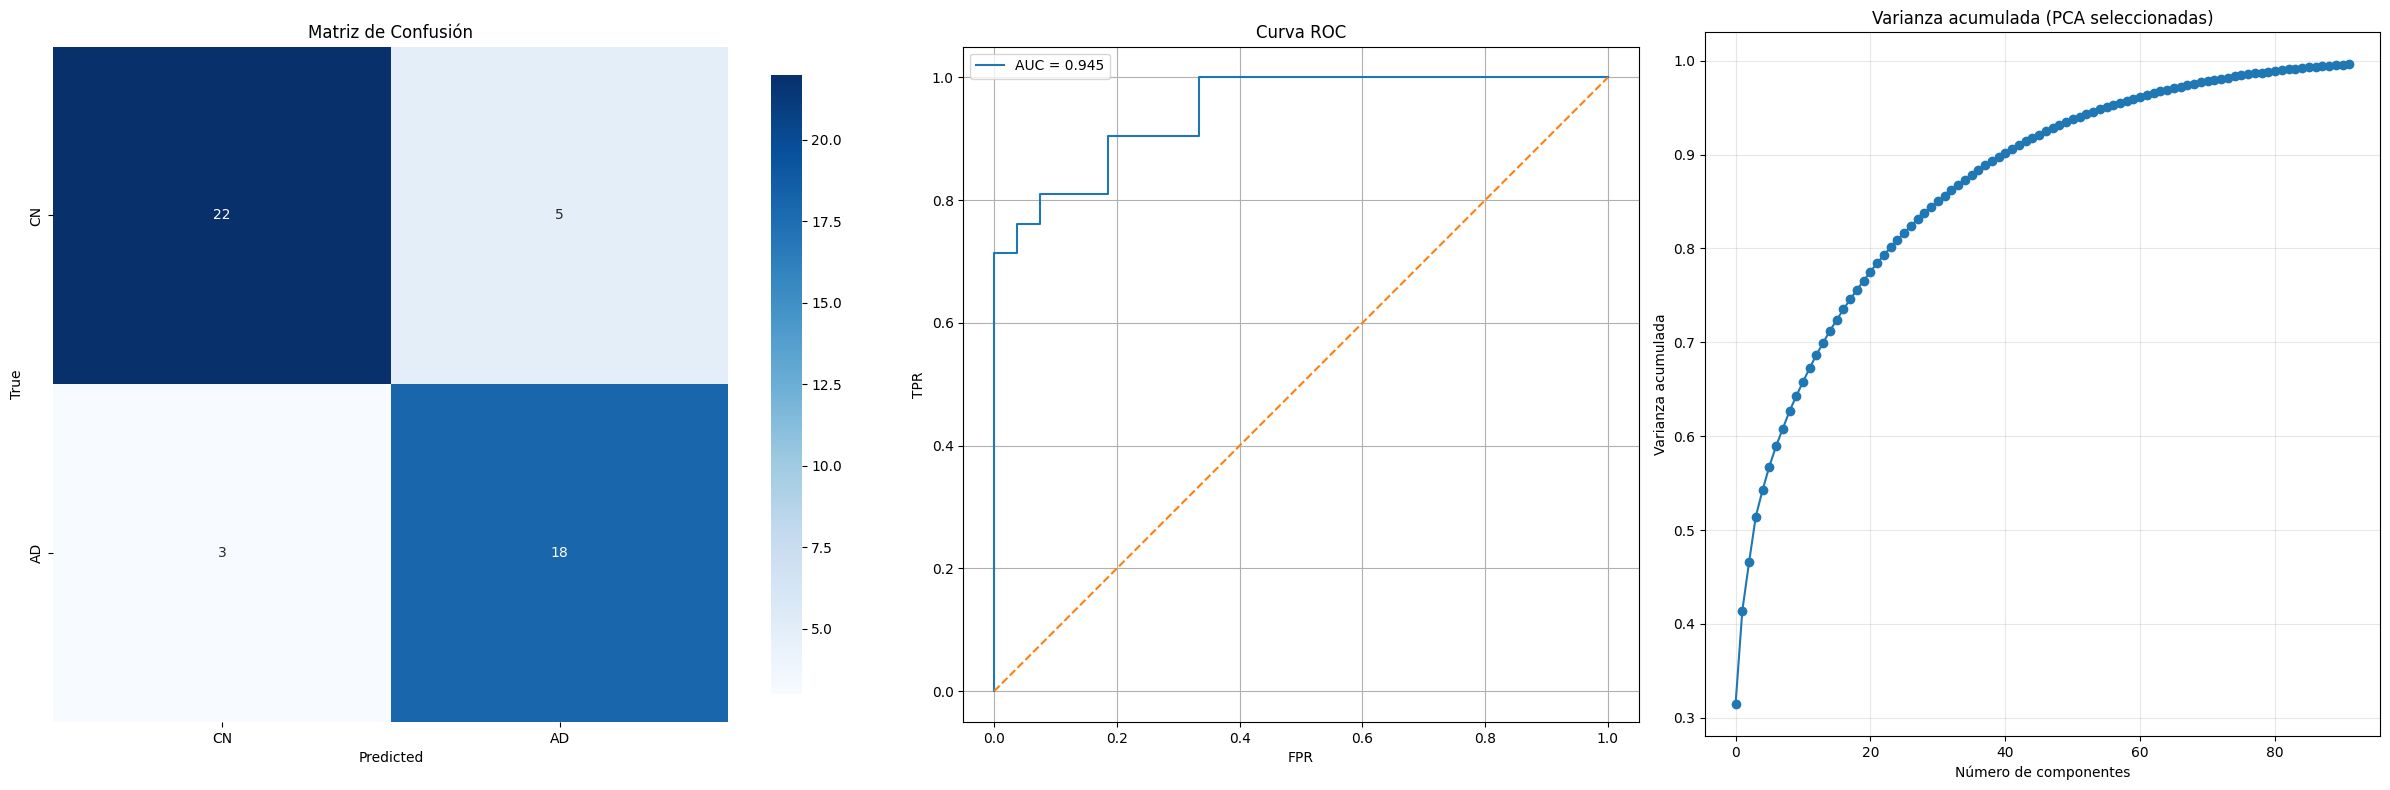


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,31.4359
1,PC2,9.9495
2,PC3,5.1699
3,PC4,4.8784
4,PC5,2.8060
5,PC6,2.5107
6,PC7,2.1681
7,PC8,1.8894
8,PC9,1.8479
9,PC10,1.6191


In [123]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('svm', SVC(probability=True, class_weight='balanced', random_state=34)) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# Random Forest

Fitting 5 folds for each of 3852 candidates, totalling 19260 fits
Mejores parámetros encontrados:
{'pca__n_components': 38, 'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8718
1,F1-score (validación),0.8145
2,ROC-AUC (test),0.9683
3,ROC-AUC (validación),0.8884
4,Balanced Accuracy (test),0.8862
5,Balanced Accuracy (validación),0.8394
6,Precision (test),0.9444
7,Precision (validación),0.8944
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.7549


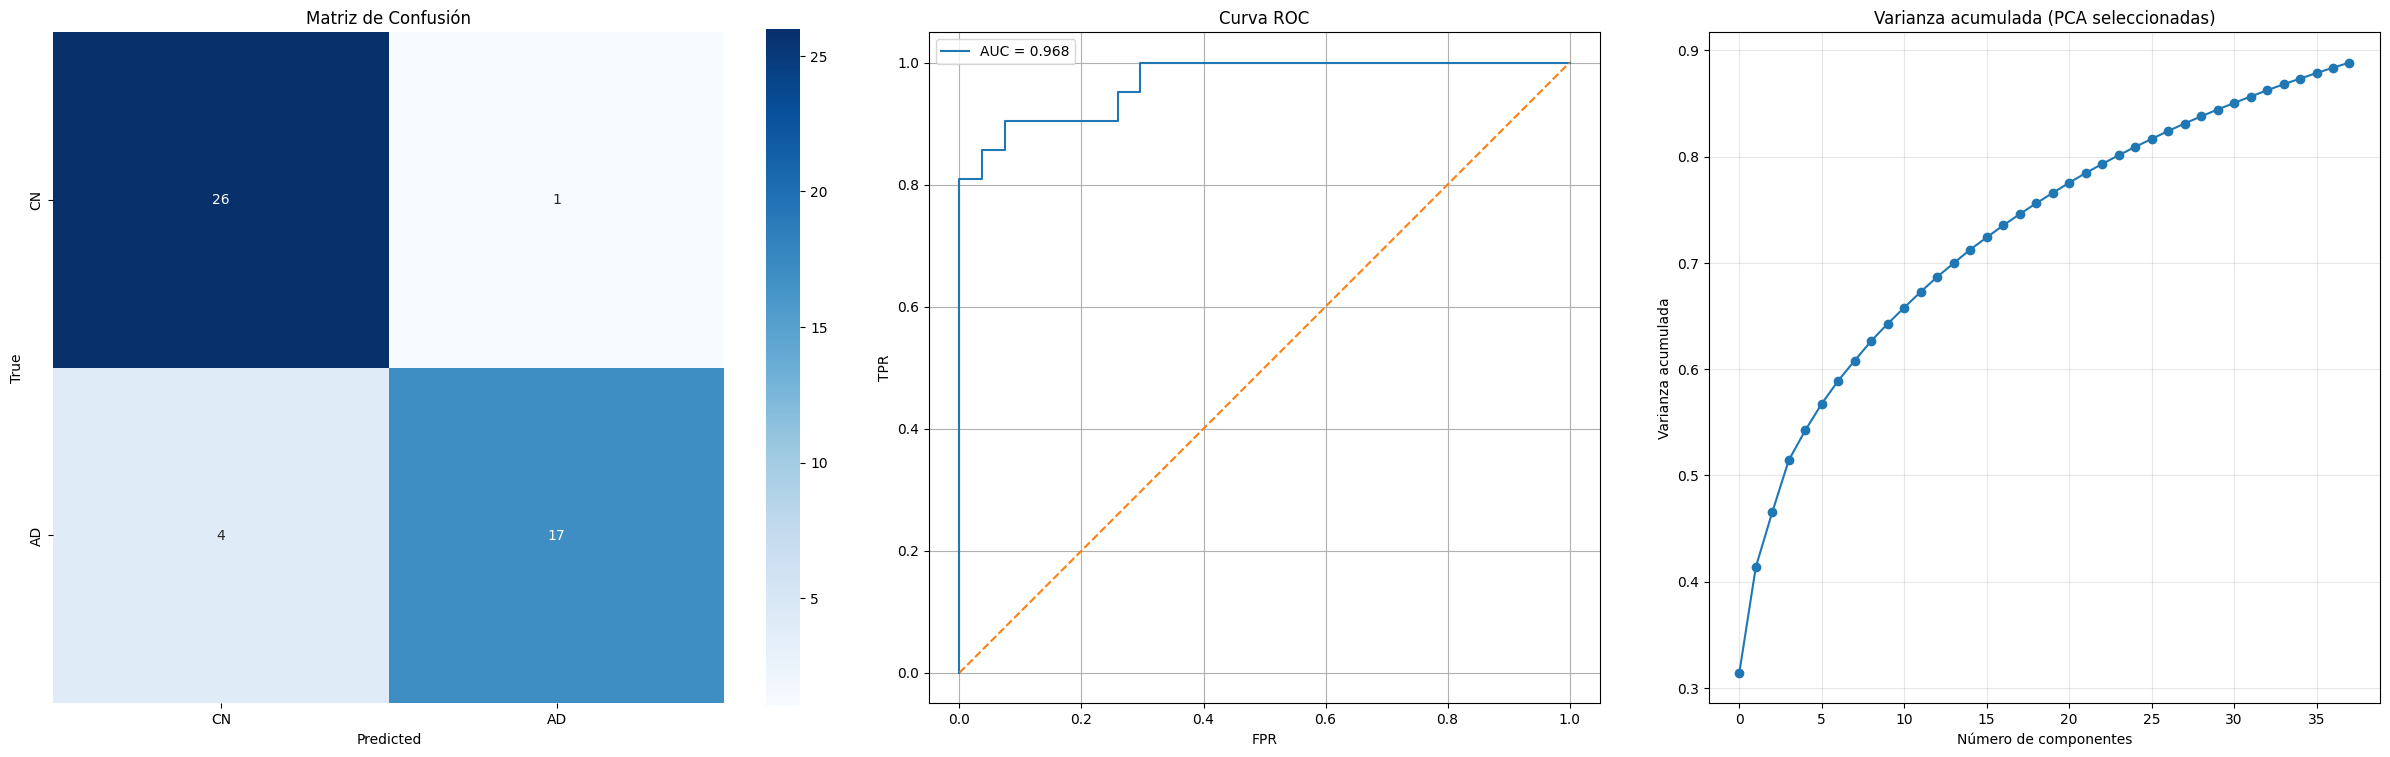


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,31.4359
1,PC2,9.9495
2,PC3,5.1699
3,PC4,4.8784
4,PC5,2.8060
5,PC6,2.5107
6,PC7,2.1681
7,PC8,1.8894
8,PC9,1.8479
9,PC10,1.6191


In [124]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_y_grosores_corticales_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_y_grosores_corticales_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_y_grosores_corticales_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_y_grosores_corticales_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}


# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_y_grosores_corticales', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# volúmenes_grosores_corticales_y_surfárea

# ELASTIC NET

# LOGISTIC REGRESSION

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Mejores parametros encontrados:
{'logreg__C': 0.1, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'selector__estimator__l1_ratio': 0.5, 'selector__max_features': 5}

===== RESUMEN DE MÉTRICAS =====


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Metric,Value
0,F1-score (test),0.8500
1,F1-score (validación),0.8795
2,ROC-AUC (test),0.9577
3,ROC-AUC (validación),0.9312
4,Balanced Accuracy (test),0.8677
5,Balanced Accuracy (validación),0.8906
6,Precision (test),0.8947
7,Precision (validación),0.8667
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.8954


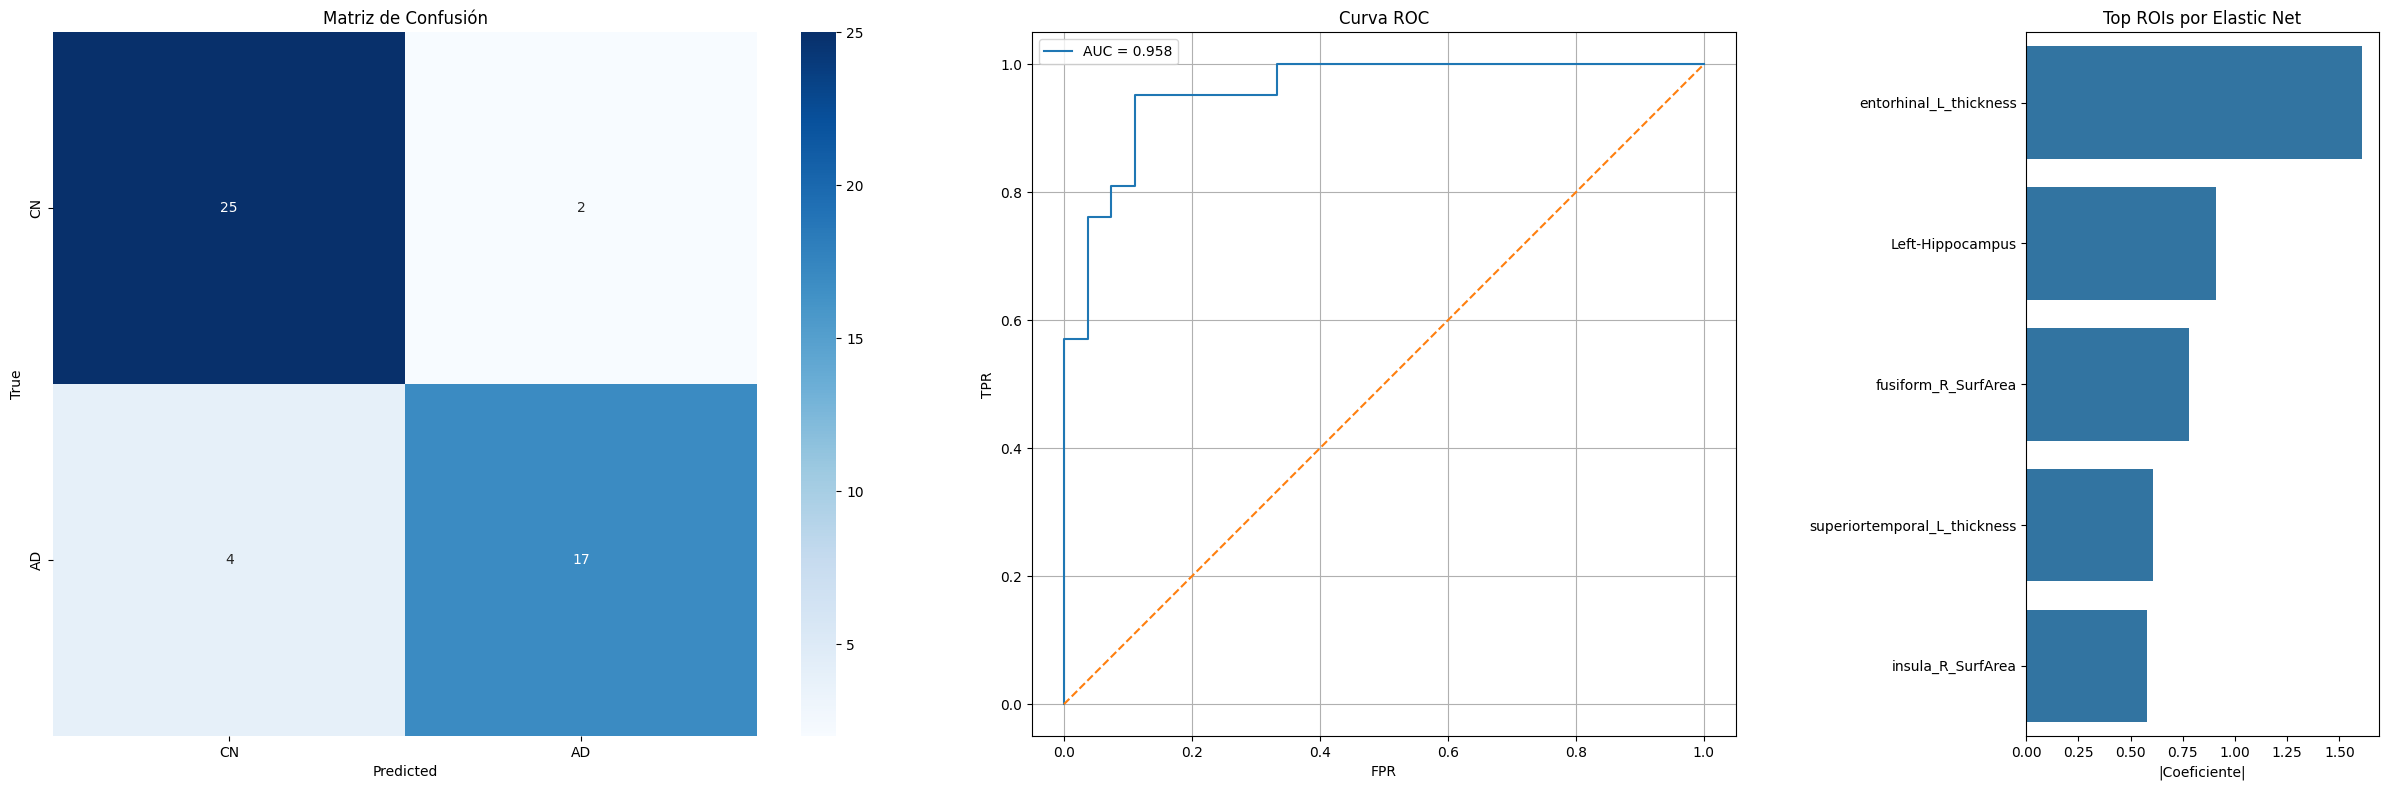


Las 5 ROIs seleccionadas son:
['Left-Hippocampus', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.6086
1,Left-Hippocampus,-0.9078
2,fusiform_R_SurfArea,-0.7785
3,superiortemporal_L_thickness,-0.6055
4,insula_R_SurfArea,0.5768
5,postcentral_R_SurfArea,0.5703
6,3rd-Ventricle,0.5545
7,Right-Amygdala,-0.5536
8,frontalpole_R_thickness,0.5423
9,cuneus_L_thickness,0.5126


In [126]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Logistic Rgression final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('logreg', LogisticRegression(max_iter=10000, random_state=34, class_weight='balanced'))
])

# Grid de hiperparametros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'logreg__C': [0.01, 0.1, 1, 10],
    'logreg__l1_ratio': [0],
    'logreg__solver': ['saga']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parametros encontrados
print("Mejores parametros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

# Calculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 2400 candidates, totalling 12000 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'selector__estimator__l1_ratio': 0.5, 'selector__max_features': 8, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9091
1,F1-score (validación),0.8832
2,ROC-AUC (test),0.9418
3,ROC-AUC (validación),0.9341
4,Balanced Accuracy (test),0.9206
5,Balanced Accuracy (validación),0.8942
6,Precision (test),0.8696
7,Precision (validación),0.8868
8,Recall (Sensitivity) (test),0.9524
9,Recall (Sensitivity) (validación),0.8837


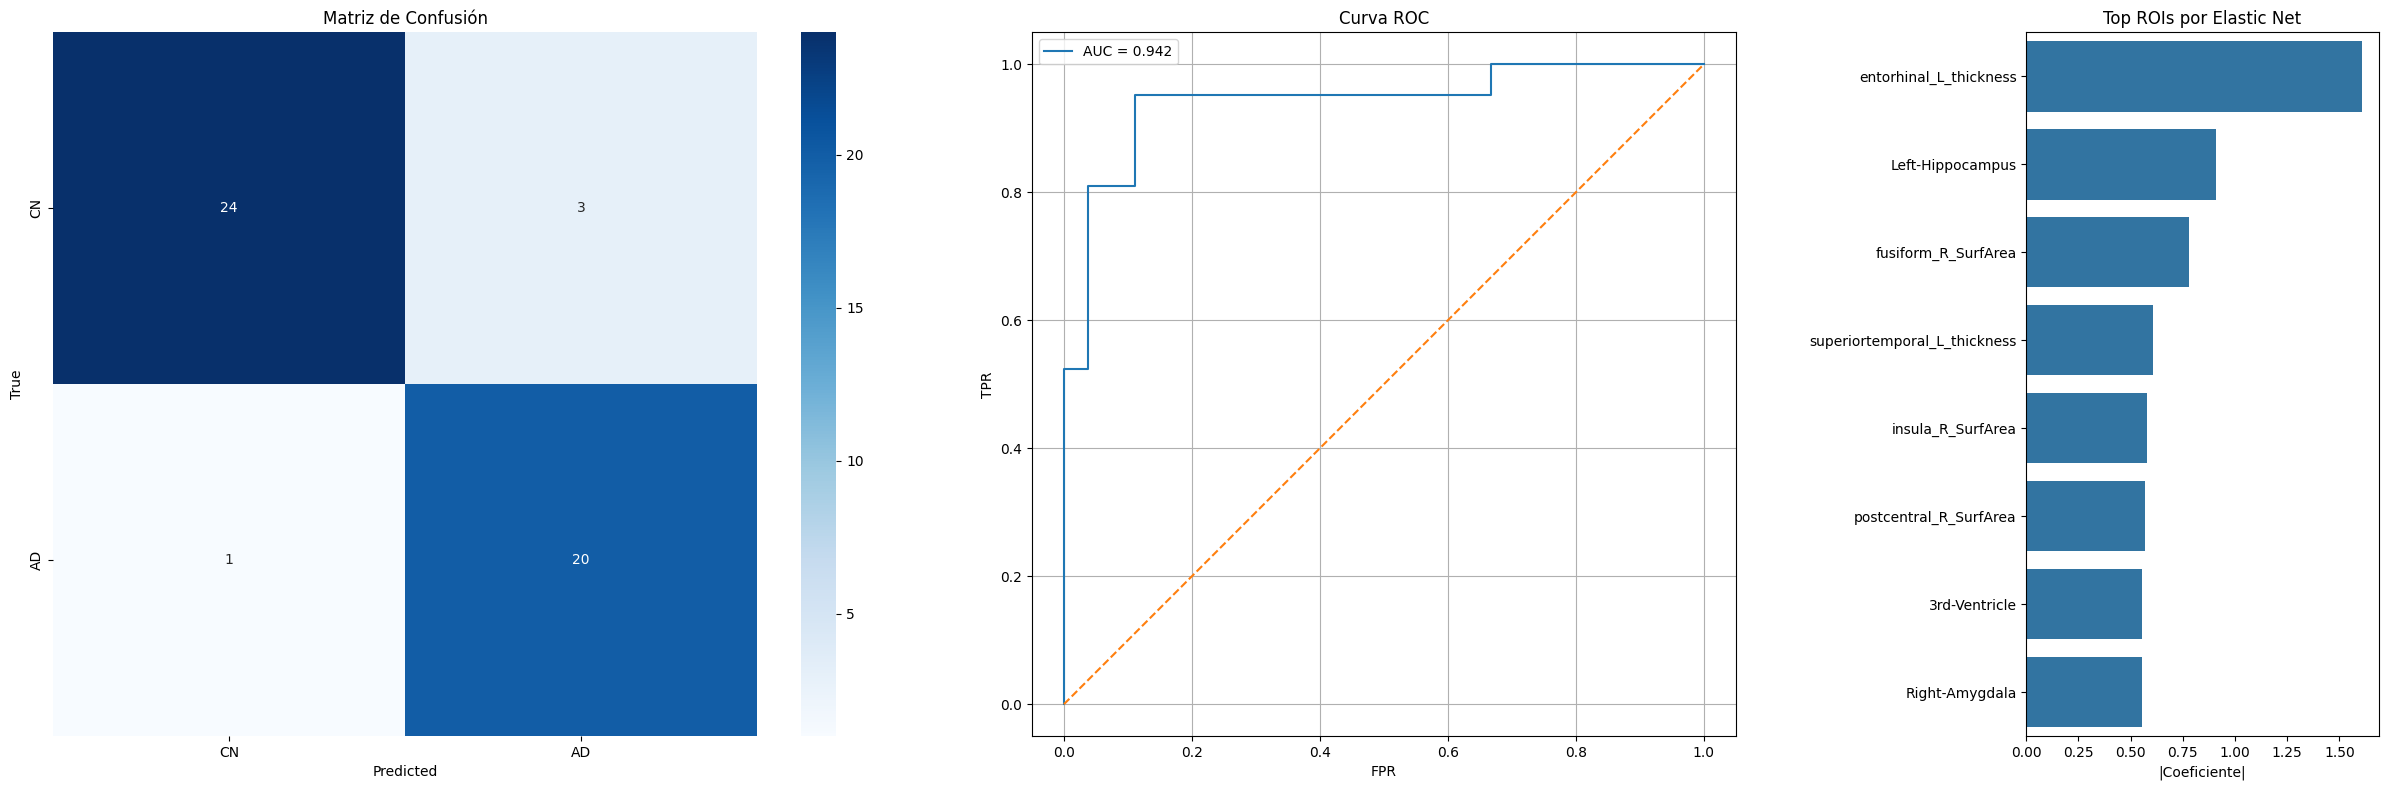


Las 8 ROIs seleccionadas son:
['3rd-Ventricle', 'Left-Hippocampus', 'Right-Amygdala', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.6086
1,Left-Hippocampus,-0.9078
2,fusiform_R_SurfArea,-0.7785
3,superiortemporal_L_thickness,-0.6055
4,insula_R_SurfArea,0.5768
5,postcentral_R_SurfArea,0.5703
6,3rd-Ventricle,0.5545
7,Right-Amygdala,-0.5536
8,frontalpole_R_thickness,0.5423
9,cuneus_L_thickness,0.5126


In [128]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight= 'balanced'
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> SVC final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('svm',  SVC(probability=True, random_state=34, class_weight= 'balanced')) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid,'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits


c:\Users\PcVip\miniconda3\envs\tf_gpu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 50, 'selector__estimator__l1_ratio': 0.3, 'selector__max_features': 8}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9048
1,F1-score (validación),0.9115
2,ROC-AUC (test),0.9841
3,ROC-AUC (validación),0.9378
4,Balanced Accuracy (test),0.9153
5,Balanced Accuracy (validación),0.9195
6,Precision (test),0.9048
7,Precision (validación),0.9317
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8961


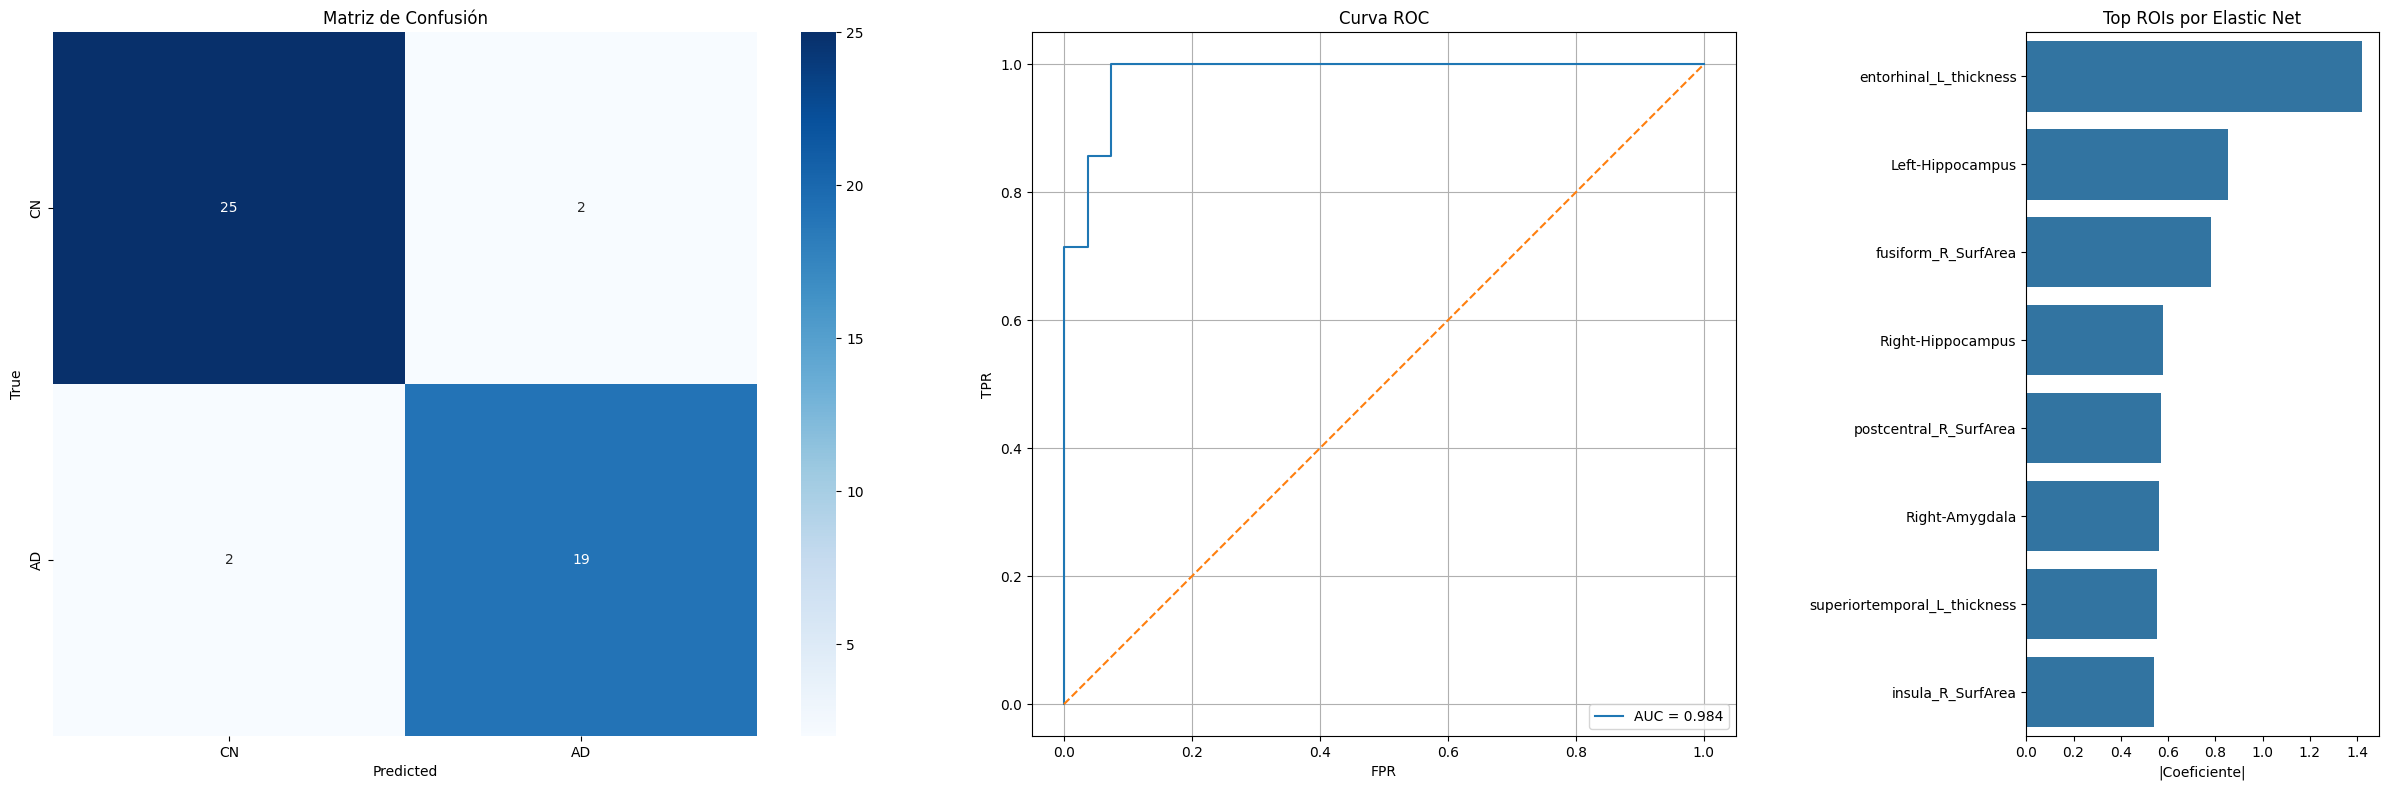


Las 8 ROIs seleccionadas son:
['Left-Hippocampus', 'Right-Hippocampus', 'Right-Amygdala', 'entorhinal_L_thickness', 'superiortemporal_L_thickness', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (Elastic Net) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.4206
1,Left-Hippocampus,-0.8552
2,fusiform_R_SurfArea,-0.7814
3,Right-Hippocampus,-0.5781
4,postcentral_R_SurfArea,0.5700
5,Right-Amygdala,-0.5603
6,superiortemporal_L_thickness,-0.5542
7,insula_R_SurfArea,0.5398
8,frontalpole_R_thickness,0.5296
9,supramarginal_L_SurfArea,-0.5256


In [129]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")


# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Regresión logística con penalización Elastic Net
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=21,
    class_weight='balanced' 
)

# Selector de features basado en el modelo Elastic Net con balanceo de clases
selector = SelectFromModel(elastic, threshold=-np.inf)

# Pipeline completo: escalado -> selección de features -> Random Forest final
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', selector),
    ('rf',  RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'selector__estimator__l1_ratio': [0.3, 0.5, 0.7],
    'selector__max_features': list(range(1, 21)),
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Coeficientes del selector
coef_selector = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Índices y nombres de features seleccionadas
selected_idx = grid.best_estimator_.named_steps['selector'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid,'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot coeficientes ---
coef_df = pd.DataFrame({
    "feature": X.columns[selected_idx],
    "coef": coef_selector[selected_idx]
})

coef_df["abs_coef"] = np.abs(coef_df["coef"])
coef_df = coef_df.sort_values("abs_coef", ascending=False)

sns.barplot(data=coef_df, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por Elastic Net')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas son:")
print(feature_names.tolist())

# Extraer los coeficientes del modelo Elastic Net usado en el selector
coef_arr = grid.best_estimator_.named_steps['selector'].estimator_.coef_.ravel()

# Construir DataFrame con todas las features
ranking_df = pd.DataFrame({
    'Feature': X.columns,        # Nombre de cada ROI
    'Coefficient': coef_arr,     # Coeficiente asignado por Elastic Net
})

# Ordenar por importancia global (de mayor a menor |coef|)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (Elastic Net) =====")
display(ranking_df)

# RFE

# LOGISTIC REGRESSION

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores parámetros encontrados:
{'logreg__C': 0.01, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 2}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9302
1,F1-score (validación),0.8914
2,ROC-AUC (test),0.9735
3,ROC-AUC (validación),0.9361
4,Balanced Accuracy (test),0.9392
5,Balanced Accuracy (validación),0.9018
6,Precision (test),0.9091
7,Precision (validación),0.9281
8,Recall (Sensitivity) (test),0.9524
9,Recall (Sensitivity) (validación),0.8608


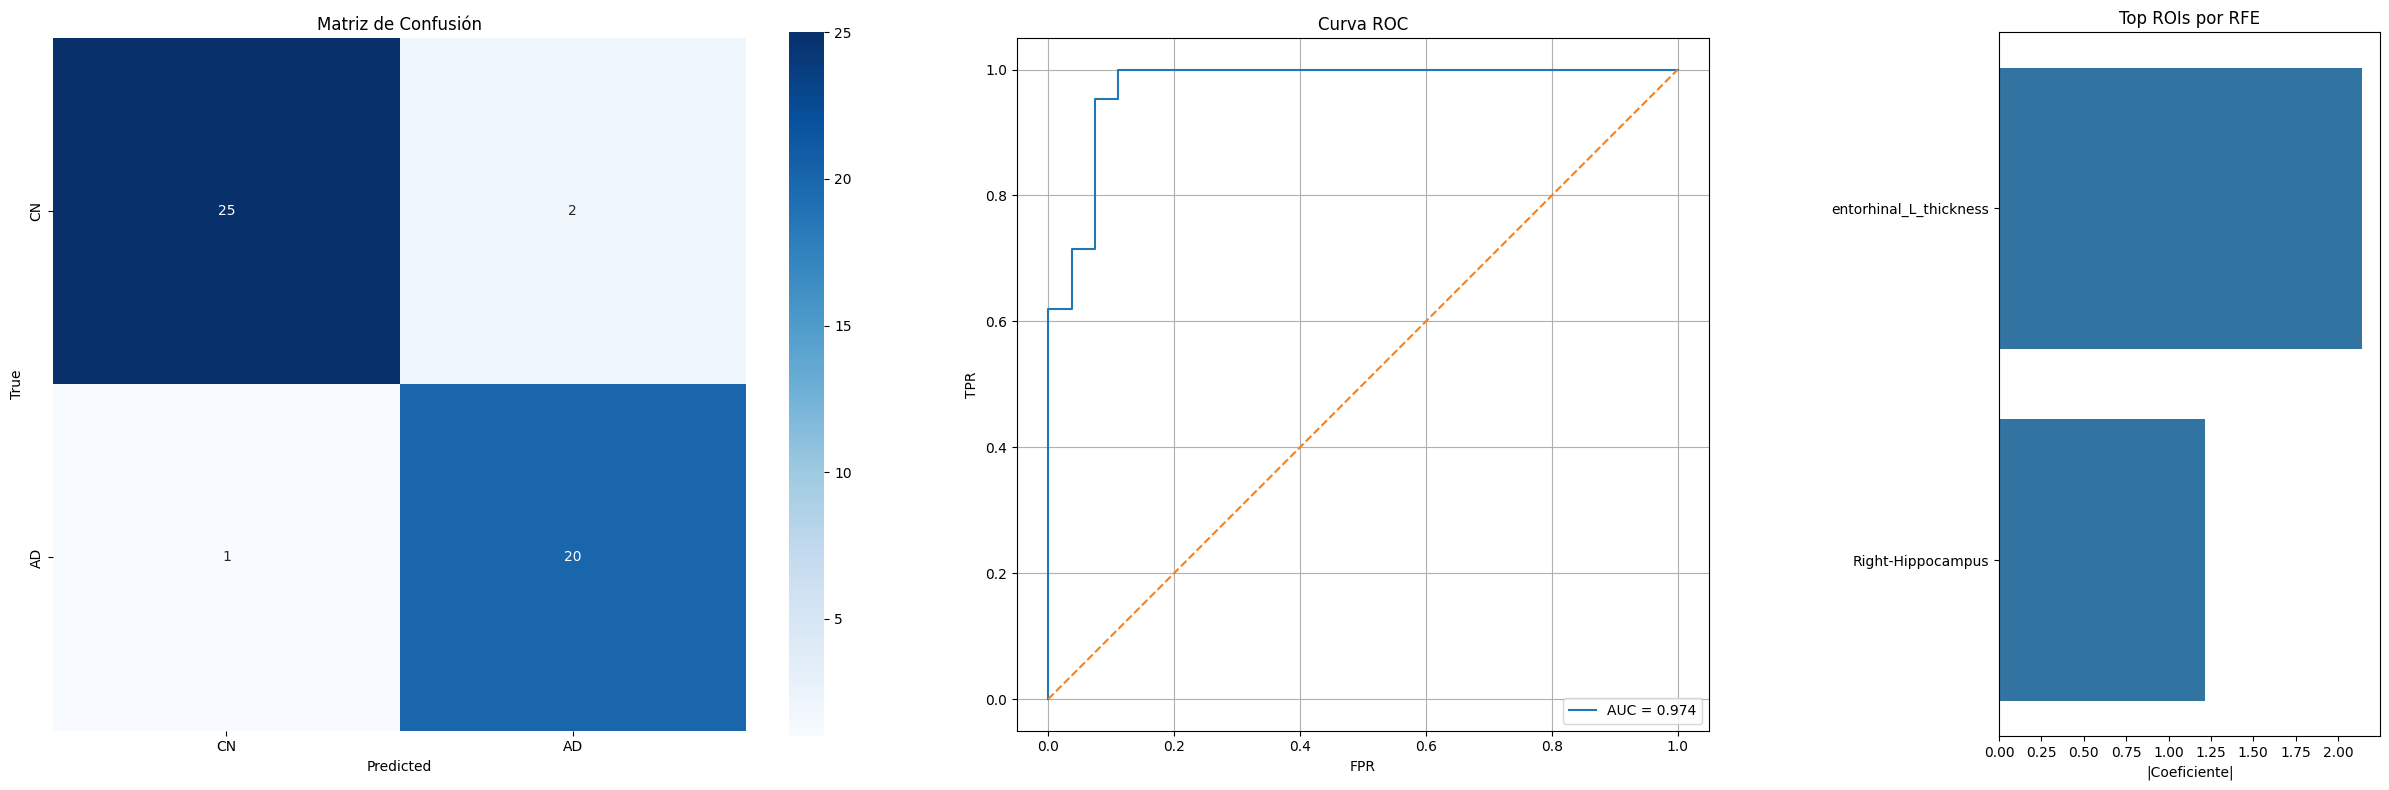


Las 2 ROIs seleccionadas por RFE son:
['Right-Hippocampus', 'entorhinal_L_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.1412
1,Right-Hippocampus,-1.2147
2,Left-Inf-Lat-Vent,0.0000
3,Left-Cerebellum-Cortex,0.0000
4,Left-Thalamus,0.0000
5,Left-Caudate,0.0000
6,Left-Lateral-Ventricle,0.0000
7,Left-Pallidum,0.0000
8,3rd-Ventricle,0.0000
9,4th-Ventricle,0.0000


In [134]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística y balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('logreg', LogisticRegression(max_iter = 10000, random_state=34, class_weight='balanced'))  # Logistic Regression con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0],          # L2
        'logreg__C': [0.01,0.1,1,10]    # Regularización
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid,'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1., 0.55]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# SVM

Fitting 5 folds for each of 800 candidates, totalling 4000 fits
Mejores parámetros encontrados:
{'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 2, 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9048
1,F1-score (validación),0.8914
2,ROC-AUC (test),0.9735
3,ROC-AUC (validación),0.9417
4,Balanced Accuracy (test),0.9153
5,Balanced Accuracy (validación),0.9018
6,Precision (test),0.9048
7,Precision (validación),0.9281
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8608


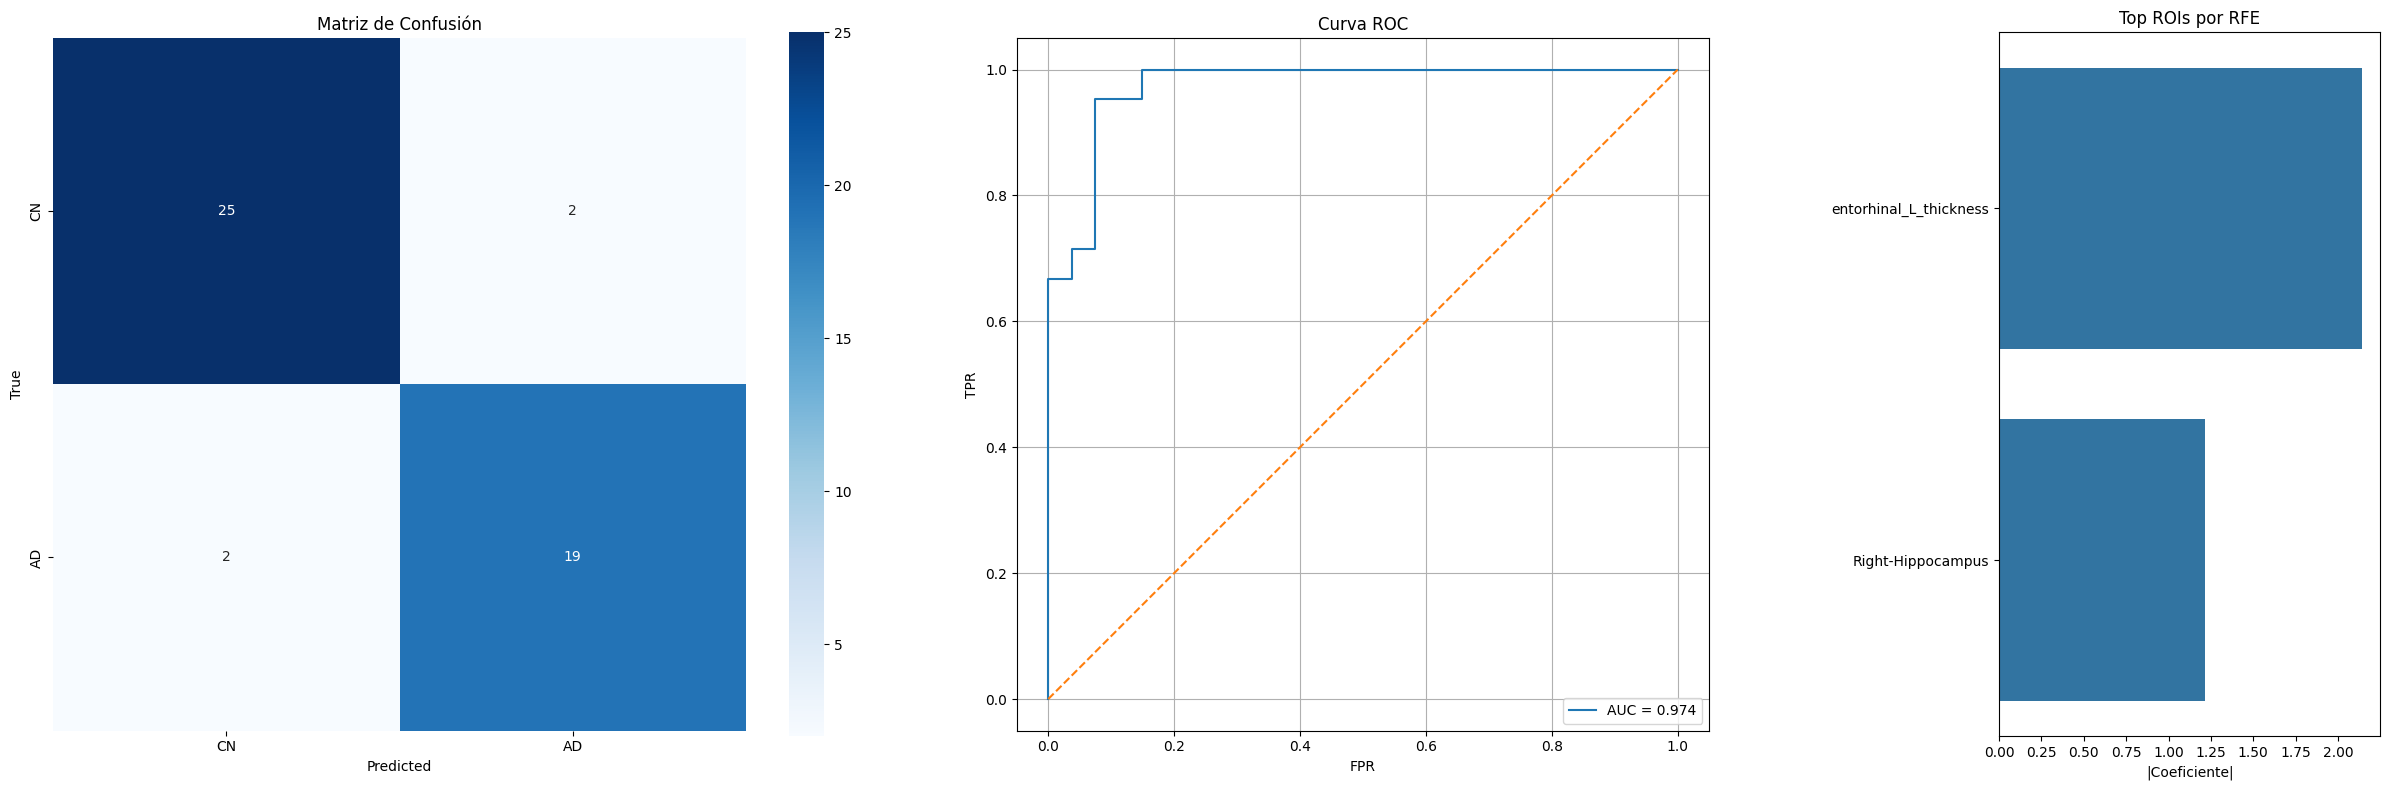


Las 2 ROIs seleccionadas por RFE son:
['Right-Hippocampus', 'entorhinal_L_thickness']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-2.1412
1,Right-Hippocampus,-1.2147
2,Left-Inf-Lat-Vent,0.0000
3,Left-Cerebellum-Cortex,0.0000
4,Left-Thalamus,0.0000
5,Left-Caudate,0.0000
6,Left-Lateral-Ventricle,0.0000
7,Left-Pallidum,0.0000
8,3rd-Ventricle,0.0000
9,4th-Ventricle,0.0000


In [136]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('svm',SVC(probability=True, random_state=34, class_weight='balanced'))  # SVM con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + SVM
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'svm__C': [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svm__kernel': ['linear', 'rbf']
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1., 0.55]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.04,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# Random Forest

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100, 'rfe__estimator__l1_ratio': 0, 'rfe__estimator__solver': 'saga', 'rfe__n_features_to_select': 19}

===== RESUMEN DE MÉTRICAS =====


,Metric,Value
0,F1-score (test),0.9048
1,F1-score (validación),0.9155
2,ROC-AUC (test),0.9824
3,ROC-AUC (validación),0.9365
4,Balanced Accuracy (test),0.9153
5,Balanced Accuracy (validación),0.9228
6,Precision (test),0.9048
7,Precision (validación),0.9506
8,Recall (Sensitivity) (test),0.9048
9,Recall (Sensitivity) (validación),0.8837


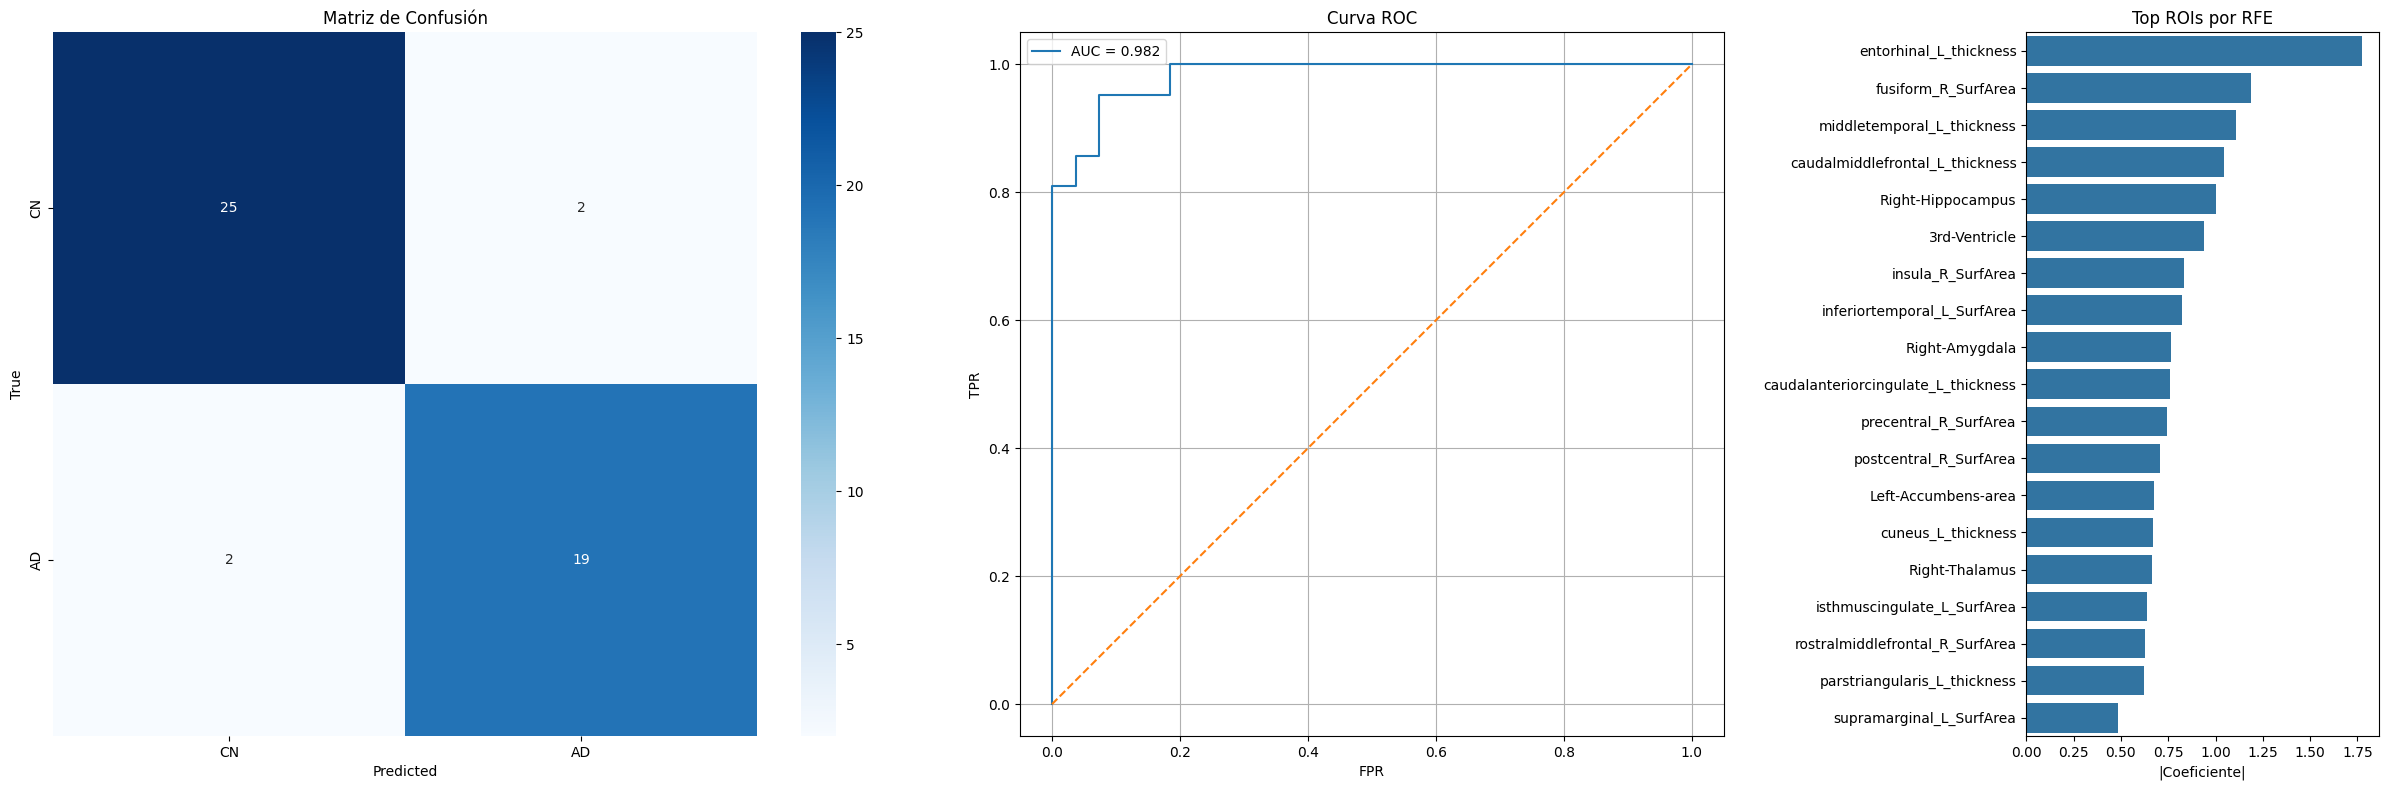


Las 19 ROIs seleccionadas por RFE son:
['3rd-Ventricle', 'Left-Accumbens-area', 'Right-Thalamus', 'Right-Hippocampus', 'Right-Amygdala', 'caudalanteriorcingulate_L_thickness', 'caudalmiddlefrontal_L_thickness', 'cuneus_L_thickness', 'entorhinal_L_thickness', 'inferiortemporal_L_SurfArea', 'isthmuscingulate_L_SurfArea', 'middletemporal_L_thickness', 'parstriangularis_L_thickness', 'supramarginal_L_SurfArea', 'fusiform_R_SurfArea', 'postcentral_R_SurfArea', 'precentral_R_SurfArea', 'rostralmiddlefrontal_R_SurfArea', 'insula_R_SurfArea']

===== RANKING COMPLETO DE FEATURES (RFE) =====


,Feature,Coefficient
0,entorhinal_L_thickness,-1.7744
1,fusiform_R_SurfArea,-1.1871
2,middletemporal_L_thickness,-1.1086
3,caudalmiddlefrontal_L_thickness,-1.0457
4,Right-Hippocampus,-1.0051
5,3rd-Ventricle,0.9380
6,insula_R_SurfArea,0.8333
7,inferiortemporal_L_SurfArea,-0.8224
8,Right-Amygdala,-0.7636
9,caudalanteriorcingulate_L_thickness,0.7571


In [138]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

# Pipeline de preprocesamiento + selección de features + clasificación
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de features
    ('rfe', RFE(
        estimator=LogisticRegression(max_iter = 10000, random_state=21, class_weight='balanced'),  # RFE con regresión logística con balanceo de clases
        step=1  # Eliminación de 1 feature por iteración
    )),
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced'))  # Random Forest con balanceo de clases desiguales
])


# Grid de hiperparámetros para GridSearchCV
param_grid = [
    {
        # RFE con regresión logística L2 + Random Forest
        'rfe__estimator__solver': ['saga'],
        'rfe__estimator__l1_ratio': [0],  # L2
        'rfe__n_features_to_select': list(range(1, 21)),  # Número de features seleccionadas
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [2, 3, 5],
        'rf__min_samples_split': [5, 10],
        'rf__min_samples_leaf': [2, 4]
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre el set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas de rendimiento
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Features seleccionadas por RFE
selected_idx = grid.best_estimator_.named_steps['rfe'].get_support(indices=True)
feature_names = X.columns[selected_idx]

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num Selected ROIs"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS =====")
display(results_df)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 0.5]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Barplot de RFE ---
ranking = grid.best_estimator_.named_steps['rfe'].ranking_  # Ranking de features
ranking_df = pd.DataFrame({'feature': X.columns, 'ranking': ranking})
coef_rfe = np.abs(grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel())

top_features = ranking_df[ranking_df['ranking'] == 1].copy()
top_features['abs_coef'] = coef_rfe
top_features = top_features.sort_values('abs_coef', ascending=False).head(20)

sns.barplot(data=top_features, x='abs_coef', y='feature', ax=axes[2])
axes[2].set_title('Top ROIs por RFE')
axes[2].set_xlabel('|Coeficiente|')
axes[2].set(ylabel=None)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.045,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Lista de ROIs seleccionadas
print(f"\nLas {len(feature_names)} ROIs seleccionadas por RFE son:")
print(feature_names.tolist())

# Obtener el ranking asignado por RFE a cada feature
ranking_arr = grid.best_estimator_.named_steps['rfe'].ranking_

# Crear máscara booleana de features seleccionadas
mask = ranking_arr == 1

# Extraer coeficientes del modelo entrenado dentro de RFE
coef_selected = grid.best_estimator_.named_steps['rfe'].estimator_.coef_.ravel()

# Crear un array completo de coeficientes alineado con todas las features
coef_full_aligned = np.zeros(len(X.columns))
coef_full_aligned[mask] = coef_selected

# Construir DataFrame final
ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef_full_aligned
})

# Ordenar por importancia (valor absoluto del coeficiente)
ranking_df = ranking_df.reindex(
    ranking_df['Coefficient'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

# Mostrar todas las filas sin truncamiento
pd.set_option('display.max_rows', None)

# Visualización final del ranking completo
print("\n===== RANKING COMPLETO DE FEATURES (RFE) =====")
display(ranking_df)

# PCA

# LOGISTIC REGRESSION

Fitting 5 folds for each of 608 candidates, totalling 3040 fits
Mejores parámetros encontrados:
{'logreg__C': 0.01, 'logreg__l1_ratio': 0, 'logreg__solver': 'saga', 'pca__n_components': 86}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8500
1,F1-score (validación),0.8941
2,ROC-AUC (test),0.9559
3,ROC-AUC (validación),0.9312
4,Balanced Accuracy (test),0.8677
5,Balanced Accuracy (validación),0.9037
6,Precision (test),0.8947
7,Precision (validación),0.9065
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.8837


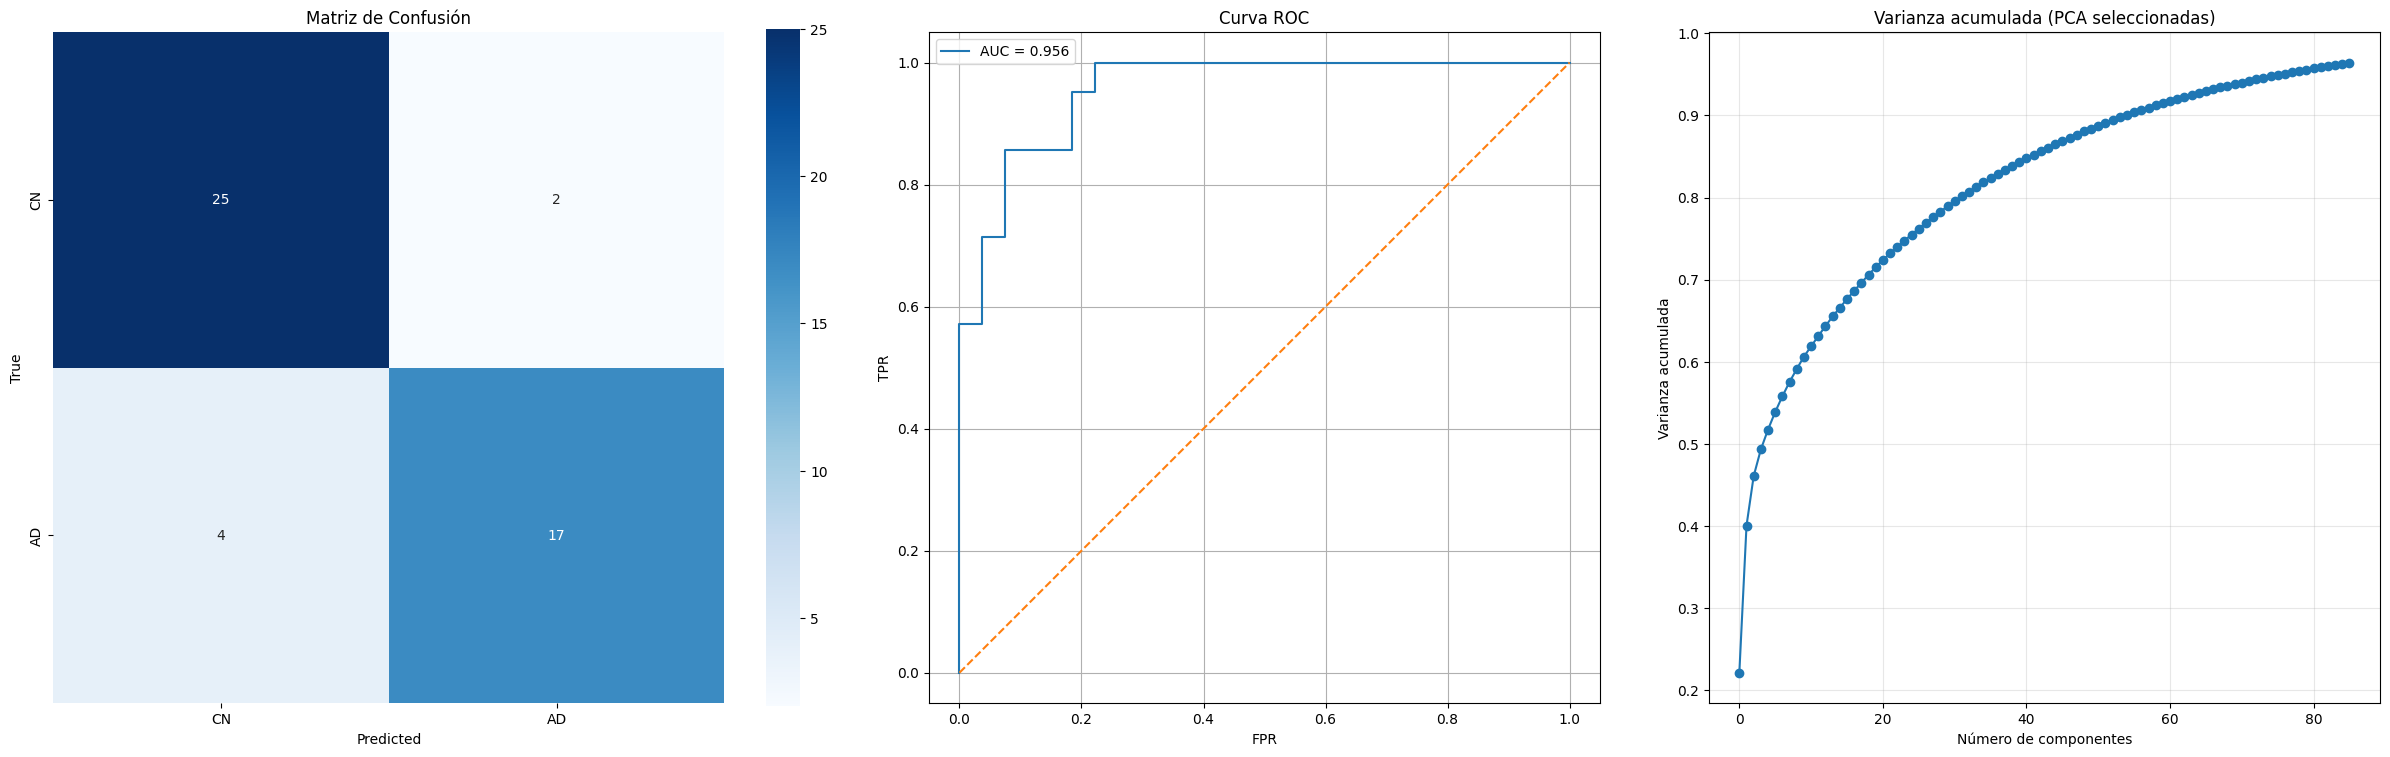


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,22.1233
1,PC2,17.9222
2,PC3,6.0335
3,PC4,3.2443
4,PC5,2.4215
5,PC6,2.1413
6,PC7,1.9061
7,PC8,1.7541
8,PC9,1.5694
9,PC10,1.5054


In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> AD, 1 -> CN
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('logreg', LogisticRegression(max_iter=10000, class_weight='balanced',  random_state=34)) # Logistic Regression con balanceo de clases desiguales
])

param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'logreg__C': [0.01, 0.1, 1, 10],         # Regularización de la regresión logística
    'logreg__l1_ratio': [0],   
    'logreg__solver': ['saga']  # Solvers permitidos para la configuración
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)


# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# SVM

Fitting 5 folds for each of 6080 candidates, totalling 30400 fits
Mejores parámetros encontrados:
{'pca__n_components': 139, 'svm__C': 0.01, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8571
1,F1-score (validación),0.8991
2,ROC-AUC (test),0.9524
3,ROC-AUC (validación),0.9404
4,Balanced Accuracy (test),0.8730
5,Balanced Accuracy (validación),0.9085
6,Precision (test),0.8571
7,Precision (validación),0.9154
8,Recall (Sensitivity) (test),0.8571
9,Recall (Sensitivity) (validación),0.8837


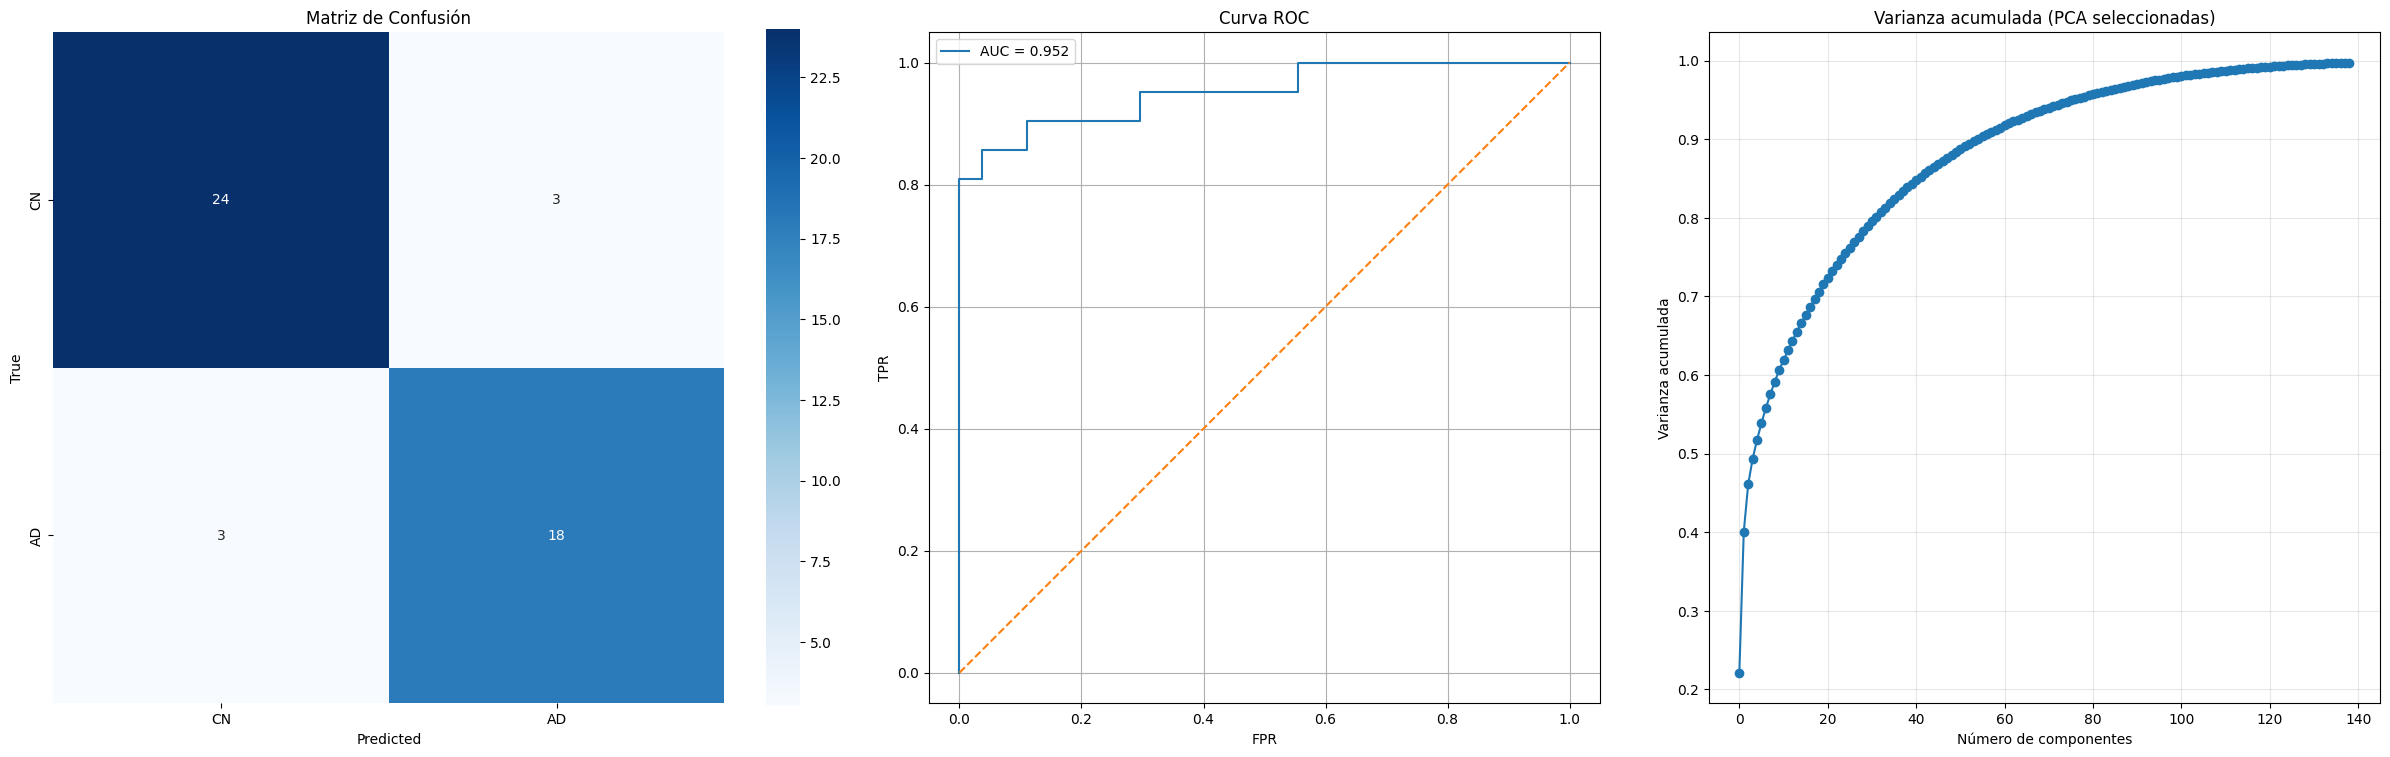


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,22.1233
1,PC2,17.9222
2,PC3,6.0335
3,PC4,3.2443
4,PC5,2.4215
5,PC6,2.1413
6,PC7,1.9061
7,PC8,1.7541
8,PC9,1.5694
9,PC10,1.5054


In [140]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('svm', SVC(probability=True, class_weight='balanced', random_state=34)) # SVM con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['linear', 'rbf']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)

# Random Forest

Fitting 5 folds for each of 5472 candidates, totalling 27360 fits
Mejores parámetros encontrados:
{'pca__n_components': 70, 'rf__max_depth': 3, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}

===== RESUMEN DE MÉTRICAS PCA =====


,Metric,Value
0,F1-score (test),0.8293
1,F1-score (validación),0.8351
2,ROC-AUC (test),0.9383
3,ROC-AUC (validación),0.8997
4,Balanced Accuracy (test),0.8492
5,Balanced Accuracy (validación),0.8584
6,Precision (test),0.8500
7,Precision (validación),0.9431
8,Recall (Sensitivity) (test),0.8095
9,Recall (Sensitivity) (validación),0.7549


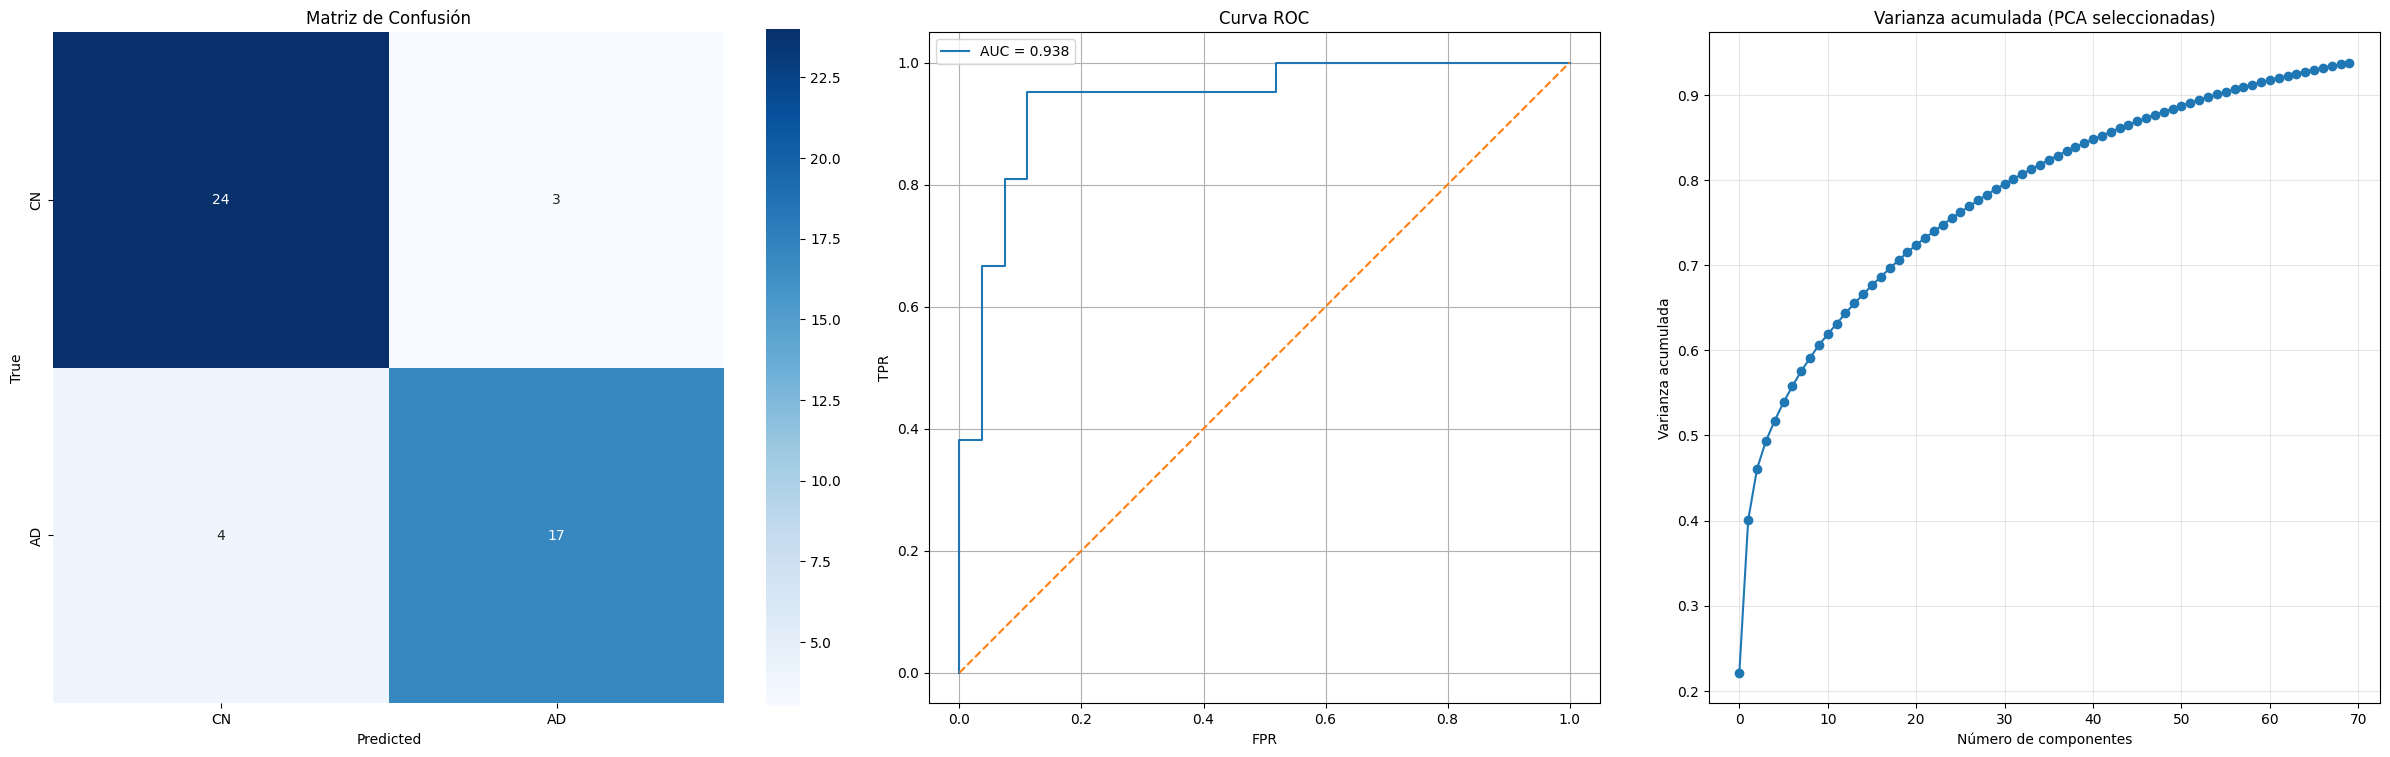


===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====


,PC,Varianza Explicada (%)
0,PC1,22.1233
1,PC2,17.9222
2,PC3,6.0335
3,PC4,3.2443
4,PC5,2.4215
5,PC6,2.1413
6,PC7,1.9061
7,PC8,1.7541
8,PC9,1.5694
9,PC10,1.5054


In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    make_scorer, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,  balanced_accuracy_score,
    precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import auc

# Lectura de CSVs por grupo y sexo
df_ad_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_m.csv")
df_ad_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_ad_f.csv")
df_cn_m = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_m.csv")
df_cn_f = pd.read_csv("volumenes_grosores_corticales_y_surfarea_cn_f.csv")

# Crear etiquetas (label) por grupo
# 0 -> CN, 1 -> AD
df_ad_m["label"] = 1
df_ad_f["label"] = 1
df_cn_m["label"] = 0
df_cn_f["label"] = 0

# Concatenar todos los dataframes en uno solo
df = pd.concat([df_ad_m, df_cn_m, df_ad_f, df_cn_f], ignore_index=True)

# Separar features (X) y etiquetas (y)
X = df.drop(columns=["label", "subject", "ICV", "5th-Ventricle", "Left-WM-hypointensities", "Right-WM-hypointensities", "non-WM-hypointensities", "Left-non-WM-hypointensities", "Right-non-WM-hypointensities"])
y = df["label"]

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=13
)

#Calcular máximo de componentes para CV
n_samples_train = X_train.shape[0]
n_features = X_train.shape[1]
n_splits = 5
train_size_per_fold = int(n_samples_train * (n_splits - 1) / n_splits)
max_components_cv = min(train_size_per_fold, n_features)

# Pipeline PCA + Logistic Regression
pipe = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de features
    ('pca', PCA(random_state=21)), # PCA para reducción de dimensionalidad
    ('rf', RandomForestClassifier(random_state=34, class_weight='balanced')) # Random Forest con balanceo de clases desiguales
])

# Grid de hiperparámetros para GridSearchCV
param_grid = {
    'pca__n_components': list(range(1, max_components_cv + 1)),  # Número de componentes PCA
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [2, 3, 5],
    'rf__min_samples_split': [5, 10],
    'rf__min_samples_leaf': [2, 4]
}


# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

# Métrica personalizada para especificidad (recall de la clase negativa)
specificity_scorer = make_scorer(recall_score, pos_label=0)

# Diccionario de métricas para GridsearchCV
scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Configuración de GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring=scoring,  # Métrica de optimización
    refit='balanced_accuracy',
    n_jobs=-1,           # Uso de todos los cores
    verbose=2,
)

# Entrenamiento
grid.fit(X_train, y_train)

# Mejor combinación de parámetros encontrada
print("Mejores parámetros encontrados:")
print(grid.best_params_)

# Métricas de validación cruzada para el mejor modelo
best_idx = grid.best_index_
f1_cv           = grid.cv_results_['mean_test_f1'][best_idx]
roc_auc_cv      = grid.cv_results_['mean_test_roc_auc'][best_idx]
balanced_acc_cv = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
precision_cv    = grid.cv_results_['mean_test_precision'][best_idx]
recall_cv       = grid.cv_results_['mean_test_recall'][best_idx]
specificity_cv  = grid.cv_results_['mean_test_specificity'][best_idx]

# Predicción sobre set de test
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

# Cálculo de métricas
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Especificidad
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# Información del PCA del modelo final
pca_model   = grid.best_estimator_.named_steps['pca']
n_selected  = pca_model.n_components_
feature_names = [f'PC{i+1}' for i in range(n_selected)]

# Varianza acumulada del PCA del modelo
explained_selected = pca_model.explained_variance_ratio_
cumulative_selected = np.cumsum(explained_selected)
varianza_acumulada = cumulative_selected[-1] * 100

# DataFrame resumen de métricas
results_df = pd.DataFrame({
    "Metric": [
        "F1-score (test)",
        "F1-score (validación)",
        "ROC-AUC (test)",
        "ROC-AUC (validación)",
        "Balanced Accuracy (test)",
        "Balanced Accuracy (validación)",
        "Precision (test)",
        "Precision (validación)",
        "Recall (Sensitivity) (test)",
        "Recall (Sensitivity) (validación)",
        "Specificity (test)",
        "Specificity (validación)",
        "Num PCA Components"
    ],
    "Value": [
        f1,
        f1_cv,
        roc_auc,
        roc_auc_cv,
        balanced_acc,
        balanced_acc_cv,
        precision,
        precision_cv,
        recall,
        recall_cv,
        specificity,
        specificity_cv,
        len(feature_names)
    ]
})

registrar_modelo(grid, 'volúmenes_grosores_corticales_y_surfárea', y_test, y_pred, y_prob, feature_names)

print("\n===== RESUMEN DE MÉTRICAS PCA =====")
display(results_df)

# Escalado de X_train con el scaler entrenado
scaler = grid.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# PCA completo sobre el conjunto escalado con límite de CV
pca_full = PCA(n_components=max_components_cv)  # Usar el mismo límite que en CV
pca_full.fit(X_train_scaled)

explained_variance_ratio_full = pca_full.explained_variance_ratio_
n_pcs_full = len(explained_variance_ratio_full)

# Ranking de todas las componentes por varianza explicada
pc_ranking_df_full = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs_full)],
    'Varianza Explicada (%)': explained_variance_ratio_full * 100
}).sort_values('Varianza Explicada (%)', ascending=False).reset_index(drop=True)

# -------- FIGURAS (1x3) --------
fig, axes = plt.subplots(
    1, 3,
    figsize=(24, 8),
    gridspec_kw={'width_ratios': [1.25, 1, 1]}  # <-- más espacio a los dos primeros
)

# --- Matriz de confusión ---
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    square=True,
    xticklabels=['CN', 'AD'],
    yticklabels=['CN', 'AD'],
    ax=axes[0],
    cbar=True, cbar_kws={'shrink': 0.88}
)
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_box_aspect(1)

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True)
axes[1].set_box_aspect(1)

# --- Varianza acumulada (solo PCs seleccionadas) ---
axes[2].plot(cumulative_selected, marker='o')
axes[2].set_title('Varianza acumulada (PCA seleccionadas)')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Varianza acumulada')
axes[2].grid(True, alpha=0.3)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
pos = axes[1].get_position()
axes[1].set_position([
    pos.x0 - 0.015,
    pos.y0,
    pos.width,
    pos.height
])
plt.show()

# Mostrar todas las filas del ranking
pd.set_option('display.max_rows', None)
print("\n===== RANKING COMPLETO DE TODAS LAS COMPONENTES PRINCIPALES (PCA) =====")
pd.options.display.float_format = '{:.4f}'.format
display(pc_ranking_df_full)